# Notebook 06 -- Visualizations for the TFG Report

**TFG:** Electricity Consumption Anomaly Detection and FDI Attack Mitigation in Edge Computing

---

This notebook produces the **final figures** for the report:

1. **Timeline plots** showing the train/val/test boundaries together with each model's predictions
2. **Episode grid** organized by attack type (7 types x best model)
3. **Consolidated comparison table** of the 4 models

### Prerequisites

NB03, NB03b, NB04 and NB05 must be run first so that the following files are available:

| Notebook | Predictions file | Metrics file |
|---|---|---|
| NB03 | `predictions_isolation_forest.csv` | `metrics_isolation_forest.json` |
| NB03b | `predictions_kmeans_if.csv` | `metrics_kmeans_if.json` |
| NB04 | `predictions_dense_autoencoder.csv` | `metrics_dense_autoencoder.json` |
| NB05 | `predictions_lstm_autoencoder.csv` | `metrics_lstm_autoencoder.json` |

## 0. Setup

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.dates as mdates

import matplotlib.patches as mpatches

from matplotlib.colors import ListedColormap

import seaborn as sns

import json, os, warnings


warnings.filterwarnings('ignore')

np.random.seed(42)


# Consistent style for the whole report

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams.update({

    'figure.figsize': (16, 5),

    'font.size': 11,

    'axes.titlesize': 13,

    'axes.labelsize': 11,

    'xtick.labelsize': 9,

    'ytick.labelsize': 9,

    'legend.fontsize': 9,

    'figure.dpi': 150,

    'savefig.dpi': 300,

    'savefig.bbox': 'tight',

})


# Color palette for the report

COLORS = {

    'train': '#3B82F6',    # blue

    'val':   '#F59E0B',    # yellow

    'test':  '#10B981',    # green

    'tp':    '#10B981',    # green (correct)

    'tn':    '#10B981',    # green (correct)

    'fp':    '#F97316',    # orange (false positive)

    'fn':    '#EF4444',    # red (false negative)

    'attack':'#EF4444',    # red (FDI episode)

    'score': '#6366F1',    # indigo (scores)

    'thr':   '#111827',    # black (threshold)

}


# Colors per model (for comparisons)

MODEL_COLORS = {

    'IF':          '#F97316',  # orange

    'K-Means+IF':  '#06B6D4',  # cyan

    'Dense AE':    '#8B5CF6',  # violet

    'LSTM AE':     '#EC4899',  # pink

}


FIGURES_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)

print('OK')

OK


## 1. Data Loading

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

DATA_DIR = os.path.join(BASE_DIR, 'data')


with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:

    config = json.load(f)


FEATURE_COLS = config['feature_cols']

ATTACK_TYPES = config['attack_types']


# -- Base data (train / val / test) --

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),

                        index_col='datetime', parse_dates=True)

df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),

                        index_col='datetime', parse_dates=True)

df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),

                        index_col='datetime', parse_dates=True)


print('Temporal splits:')

for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:

    print(f'  {nm:6s} {len(d):>10,} rows  {d.index.min().date()} -> {d.index.max().date()}')


# -- Predictions from each model --

MODELS = {}


model_files = {

    'IF': {

        'preds': 'predictions_isolation_forest.csv',

        'metrics': 'metrics_isolation_forest.json',

        'score_col': 'if_score',

        'raw_col': 'if_pred_raw',

        'smooth_col': 'if_pred_smooth',

    },

    'K-Means+IF': {

        'preds': 'predictions_kmeans_if.csv',

        'metrics': 'metrics_kmeans_if.json',

        'score_col': 'kmif_score',

        'raw_col': 'kmif_pred_raw',

        'smooth_col': 'kmif_pred_smooth',

    },

    'Dense AE': {

        'preds': 'predictions_dense_autoencoder.csv',

        'metrics': 'metrics_dense_autoencoder.json',

        'score_col': 'dae_score',

        'raw_col': 'dae_pred_raw',

        'smooth_col': 'dae_pred_smooth',

    },

    'LSTM AE': {

        'preds': 'predictions_lstm_autoencoder.csv',

        'metrics': 'metrics_lstm_autoencoder.json',

        'score_col': 'lstm_score',

        'raw_col': 'lstm_pred_raw',

        'smooth_col': 'lstm_pred_smooth',

    },

}


print('\nLoaded models:')

for name, info in model_files.items():

    preds_path = os.path.join(DATA_DIR, info['preds'])

    metrics_path = os.path.join(DATA_DIR, info['metrics'])

    

    if not os.path.exists(preds_path):

        print(f'  {name:12s}  MISSING {info["preds"]}')

        continue

    

    df_p = pd.read_csv(preds_path, index_col='datetime', parse_dates=True)

    

    with open(metrics_path) as f:

        m = json.load(f)

    

    MODELS[name] = {

        'preds': df_p,

        'metrics': m,

        'score_col': info['score_col'],

        'raw_col': info['raw_col'],

        'smooth_col': info['smooth_col'],

        'threshold': m['threshold'],

    }

    

    print(f'  {name:12s}  F1={m["f1"]:.4f}  P={m["precision"]:.4f}  '

          f'R={m["recall"]:.4f}  AUC-ROC={m["auc_roc"]:.4f}')


print(f'\nTotal models: {len(MODELS)}/4')

Temporal splits:
  Train   1,300,061 rows  2006-12-16 -> 2009-06-09
  Val       144,452 rows  2009-06-09 -> 2009-09-20
  Test      604,999 rows  2009-09-20 -> 2010-11-26

Loaded models:
  IF            F1=0.7544  P=0.7621  R=0.7469  AUC-ROC=0.9266
  K-Means+IF    F1=0.7895  P=0.8337  R=0.7497  AUC-ROC=0.9270
  Dense AE      F1=0.8083  P=0.8099  R=0.8067  AUC-ROC=0.9304
  LSTM AE       F1=0.7306  P=0.6457  R=0.8411  AUC-ROC=0.9429

Total models: 4/4


## 2. Timeline Plot with Train/Val/Test Boundaries

A reusable function that builds three stacked panels:

1. **Global_active_power** with colored bands: blue = train, yellow = val, green = test
2. **Anomaly score** on the test split, with the threshold drawn in
3. **Binary hit ribbon**: green = TP/TN (correct), red = FN (miss), orange = FP (false alarm)

In [3]:
def plot_timeline(model_name, df_train, df_val, df_test, df_preds,
                  score_col, smooth_col, threshold, metrics,
                  save_path=None, figsize=(18, 10)):
    '''
    Full timeline plot with three stacked panels.

    Panel 1: Global_active_power across the whole dataset, with train/val/test bands
    Panel 2: anomaly score on the test split, with the calibrated threshold
    Panel 3: binary ribbon of TP/TN/FP/FN outcomes

    Args:
        model_name:  model name (used in the title)
        df_train:    train DataFrame (index=datetime, col=Global_active_power)
        df_val:      val DataFrame (same schema)
        df_test:     test DataFrame (with label, attack_type, etc.)
        df_preds:    predictions DataFrame (index=datetime, cols=score, pred)
        score_col:   name of the score column
        smooth_col:  name of the smoothed-prediction column
        threshold:   calibrated threshold
        metrics:     dict of metrics (used in the subtitle)
        save_path:   if provided, the figure is saved there
    '''
    fig, axes = plt.subplots(3, 1, figsize=figsize,
                              gridspec_kw={'height_ratios': [2, 1.5, 0.5]},
                              sharex=False)

    # ===================================================
    # PANEL 1: Global_active_power with temporal bands
    # ===================================================
    ax = axes[0]

    # Subsample for performance (1 in every 60 -> roughly one point per hour)
    step = max(1, len(df_train) // 5000)

    ax.plot(df_train.index[::step], df_train['Global_active_power'].values[::step],
            color=COLORS['train'], lw=0.3, alpha=0.7, rasterized=True)
    ax.plot(df_val.index[::step], df_val['Global_active_power'].values[::step],
            color=COLORS['val'], lw=0.3, alpha=0.7, rasterized=True)
    ax.plot(df_test.index[::step], df_test['Global_active_power'].values[::step],
            color=COLORS['test'], lw=0.3, alpha=0.7, rasterized=True)

    # Vertical split boundaries
    val_start = df_val.index[0]
    test_start = df_test.index[0]
    for boundary, label in [(val_start, 'Val start'), (test_start, 'Test start')]:
        ax.axvline(boundary, color='black', linestyle='--', lw=1.5, alpha=0.8)

    # Legend built from color patches
    patches = [
        mpatches.Patch(color=COLORS['train'], alpha=0.7, label=f'Train ({len(df_train):,})'),
        mpatches.Patch(color=COLORS['val'],   alpha=0.7, label=f'Val ({len(df_val):,})'),
        mpatches.Patch(color=COLORS['test'],  alpha=0.7, label=f'Test ({len(df_test):,})'),
    ]
    ax.legend(handles=patches, loc='upper right', fontsize=9, ncol=3)
    ax.set_ylabel('Global Active Power (kW)')
    ax.set_title(f'{model_name} -- Full dataset view',
                 fontweight='bold', fontsize=13)
    ax.set_xlim(df_train.index[0], df_test.index[-1])

    # ===================================================
    # PANEL 2: anomaly score on TEST, with threshold
    # ===================================================
    ax = axes[1]

    scores = df_preds[score_col].values
    test_idx = df_preds.index
    y_true = df_preds['label'].values.astype(int)

    # Subsample the scores
    step_t = max(1, len(scores) // 8000)

    ax.plot(test_idx[::step_t], scores[::step_t],
            color=COLORS['score'], lw=0.4, alpha=0.8, rasterized=True)
    ax.axhline(threshold, color=COLORS['thr'], linestyle='--', lw=1.5,
               label=f'Threshold = {threshold:.4f}')

    # Shade the attack episodes
    episodes = df_preds[df_preds['episode_id'] >= 0]
    if len(episodes) > 0:
        for ep_id in episodes['episode_id'].unique():
            ep_mask = df_preds['episode_id'] == ep_id
            ep_data = df_preds[ep_mask]
            ax.axvspan(ep_data.index[0], ep_data.index[-1],
                       alpha=0.15, color=COLORS['attack'], zorder=0)

    ax.set_ylabel('Anomaly Score')
    ax.set_title(f'Scores on Test (FDI episodes shaded in red)',
                 fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(test_idx[0], test_idx[-1])

    # ===================================================
    # PANEL 3: binary ribbon of TP/TN/FP/FN
    # ===================================================
    ax = axes[2]

    y_pred = df_preds[smooth_col].values.astype(int)

    # Encode each point: 0=TN(green), 1=TP(green), 2=FP(orange), 3=FN(red)
    ribbon = np.zeros(len(y_true), dtype=int)
    ribbon[(y_true == 0) & (y_pred == 0)] = 0  # TN
    ribbon[(y_true == 1) & (y_pred == 1)] = 0  # TP (both green = correct)
    ribbon[(y_true == 0) & (y_pred == 1)] = 1  # FP
    ribbon[(y_true == 1) & (y_pred == 0)] = 2  # FN

    cmap = ListedColormap([COLORS['tp'], COLORS['fp'], COLORS['fn']])

    # Render the ribbon as a 1-row image
    ribbon_2d = ribbon.reshape(1, -1)
    extent = [mdates.date2num(test_idx[0]), mdates.date2num(test_idx[-1]), 0, 1]
    ax.imshow(ribbon_2d, aspect='auto', cmap=cmap, vmin=0, vmax=2,
              extent=extent, interpolation='nearest')
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.set_yticks([])

    # Legend
    ribbon_patches = [
        mpatches.Patch(color=COLORS['tp'], label='Correct (TP+TN)'),
        mpatches.Patch(color=COLORS['fp'], label='False Positive (FP)'),
        mpatches.Patch(color=COLORS['fn'], label='False Negative (FN)'),
    ]
    ax.legend(handles=ribbon_patches, loc='upper right', fontsize=8, ncol=3)
    ax.set_title(f'Hits/Errors (smoothed, W={metrics.get("temporal_W","?")}, '
                 f'K={metrics.get("temporal_K","?")})', fontsize=11)
    ax.set_xlim(mdates.date2num(test_idx[0]), mdates.date2num(test_idx[-1]))

    # -- Overall title with the headline metrics --
    fig.suptitle(
        f'{model_name}   |   '
        f'F1={metrics["f1"]:.4f}   P={metrics["precision"]:.4f}   '
        f'R={metrics["recall"]:.4f}   AUC-ROC={metrics["auc_roc"]:.4f}',
        fontsize=14, fontweight='bold', y=1.01
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'  Saved: {save_path}')

    plt.show()
    return fig


print('plot_timeline() defined')

plot_timeline() defined


## 3. Timeline Plots -- The 4 Models


  IF
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/timeline_if.png


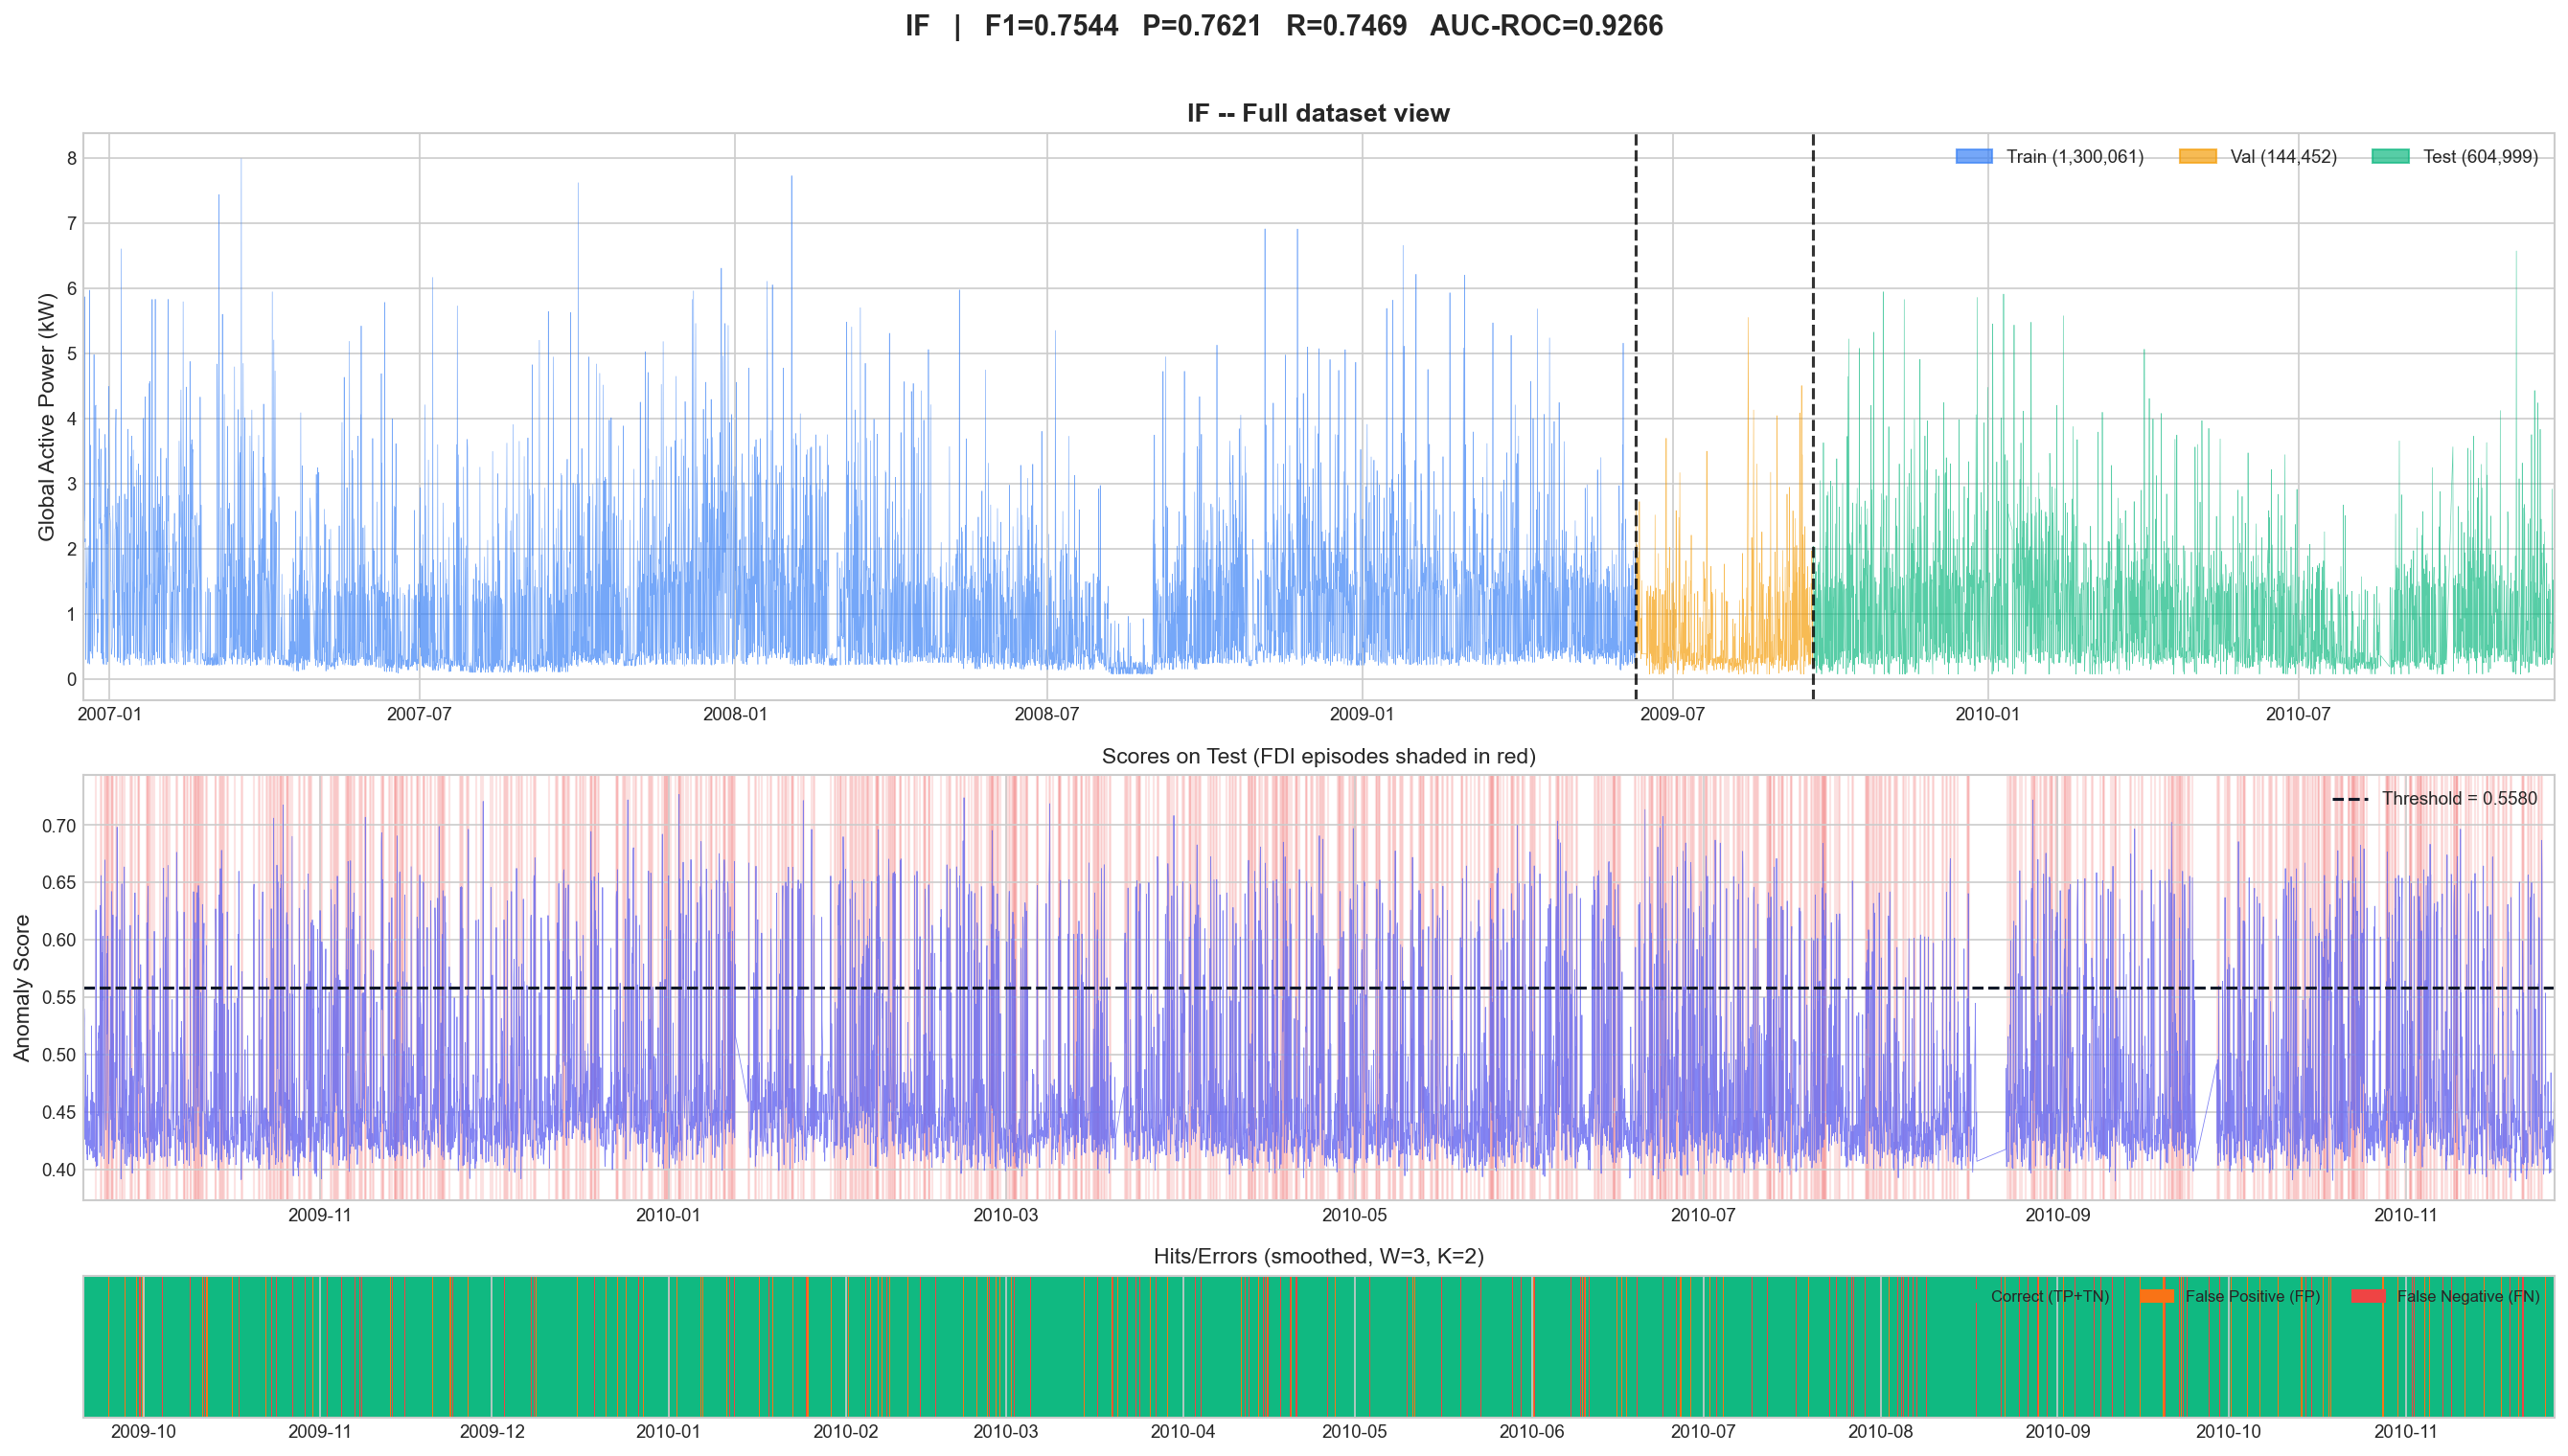


  K-Means+IF
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/timeline_k-means_if.png


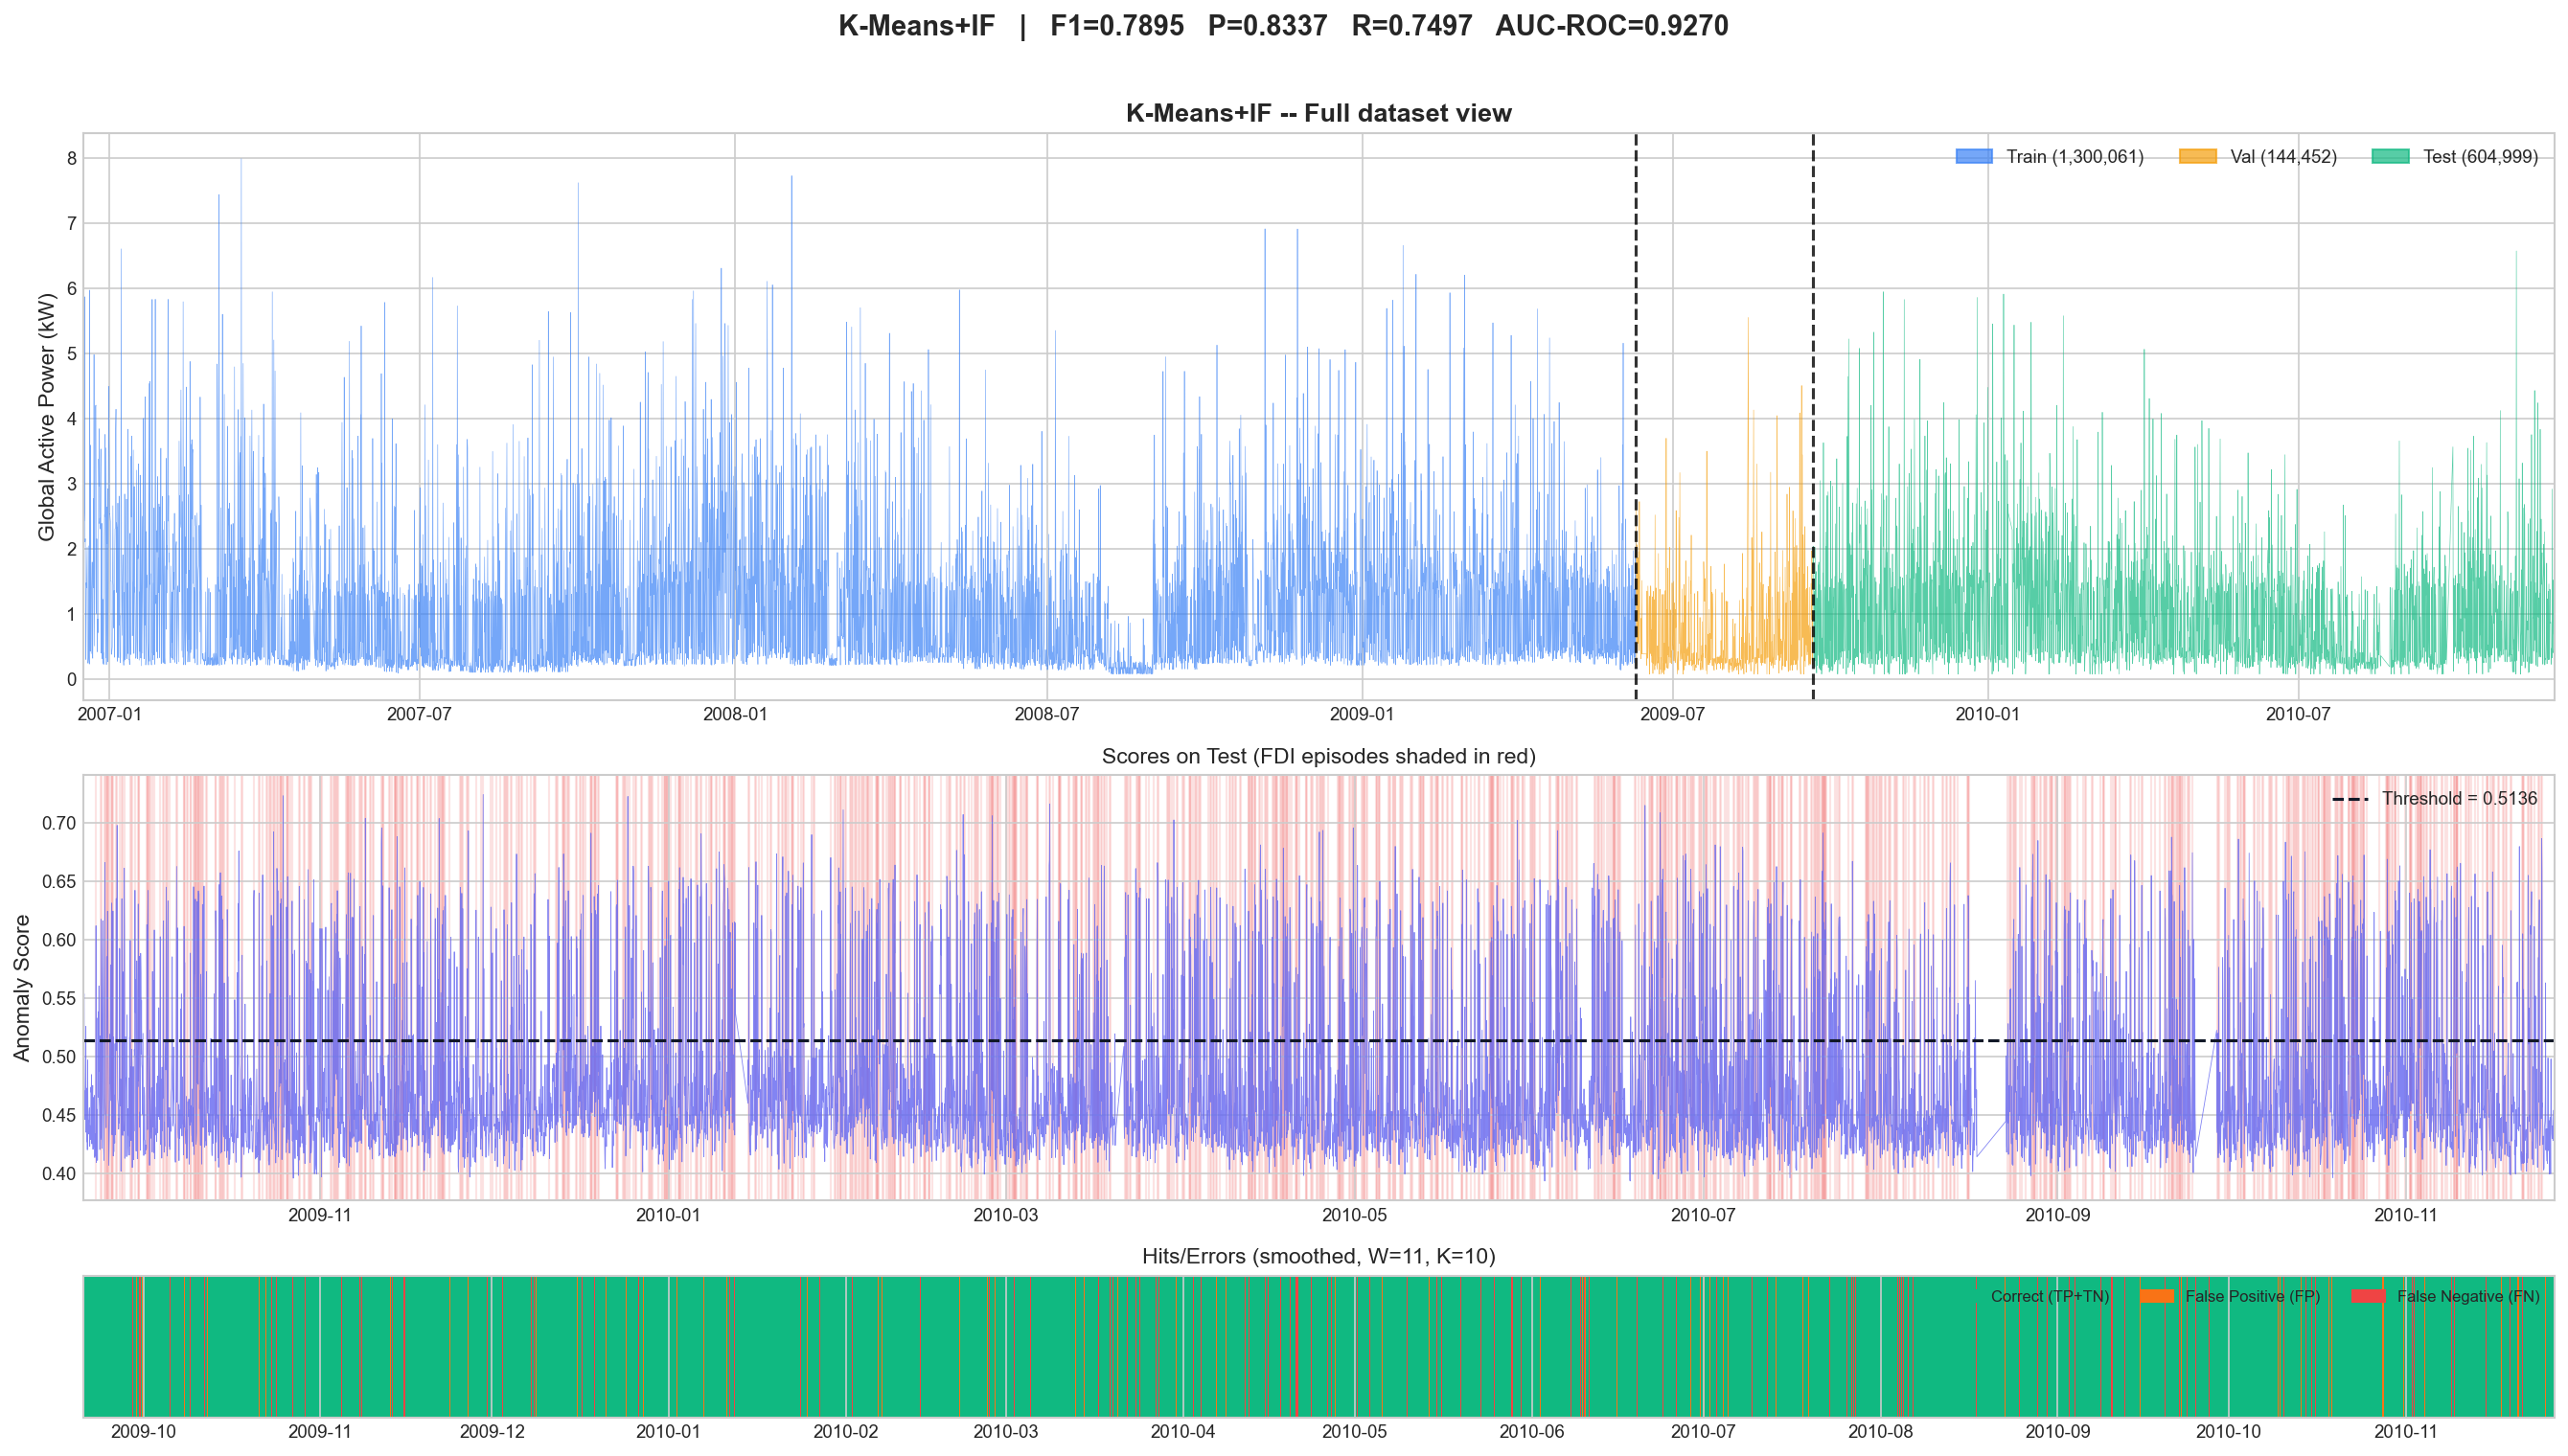


  Dense AE
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/timeline_dense_ae.png


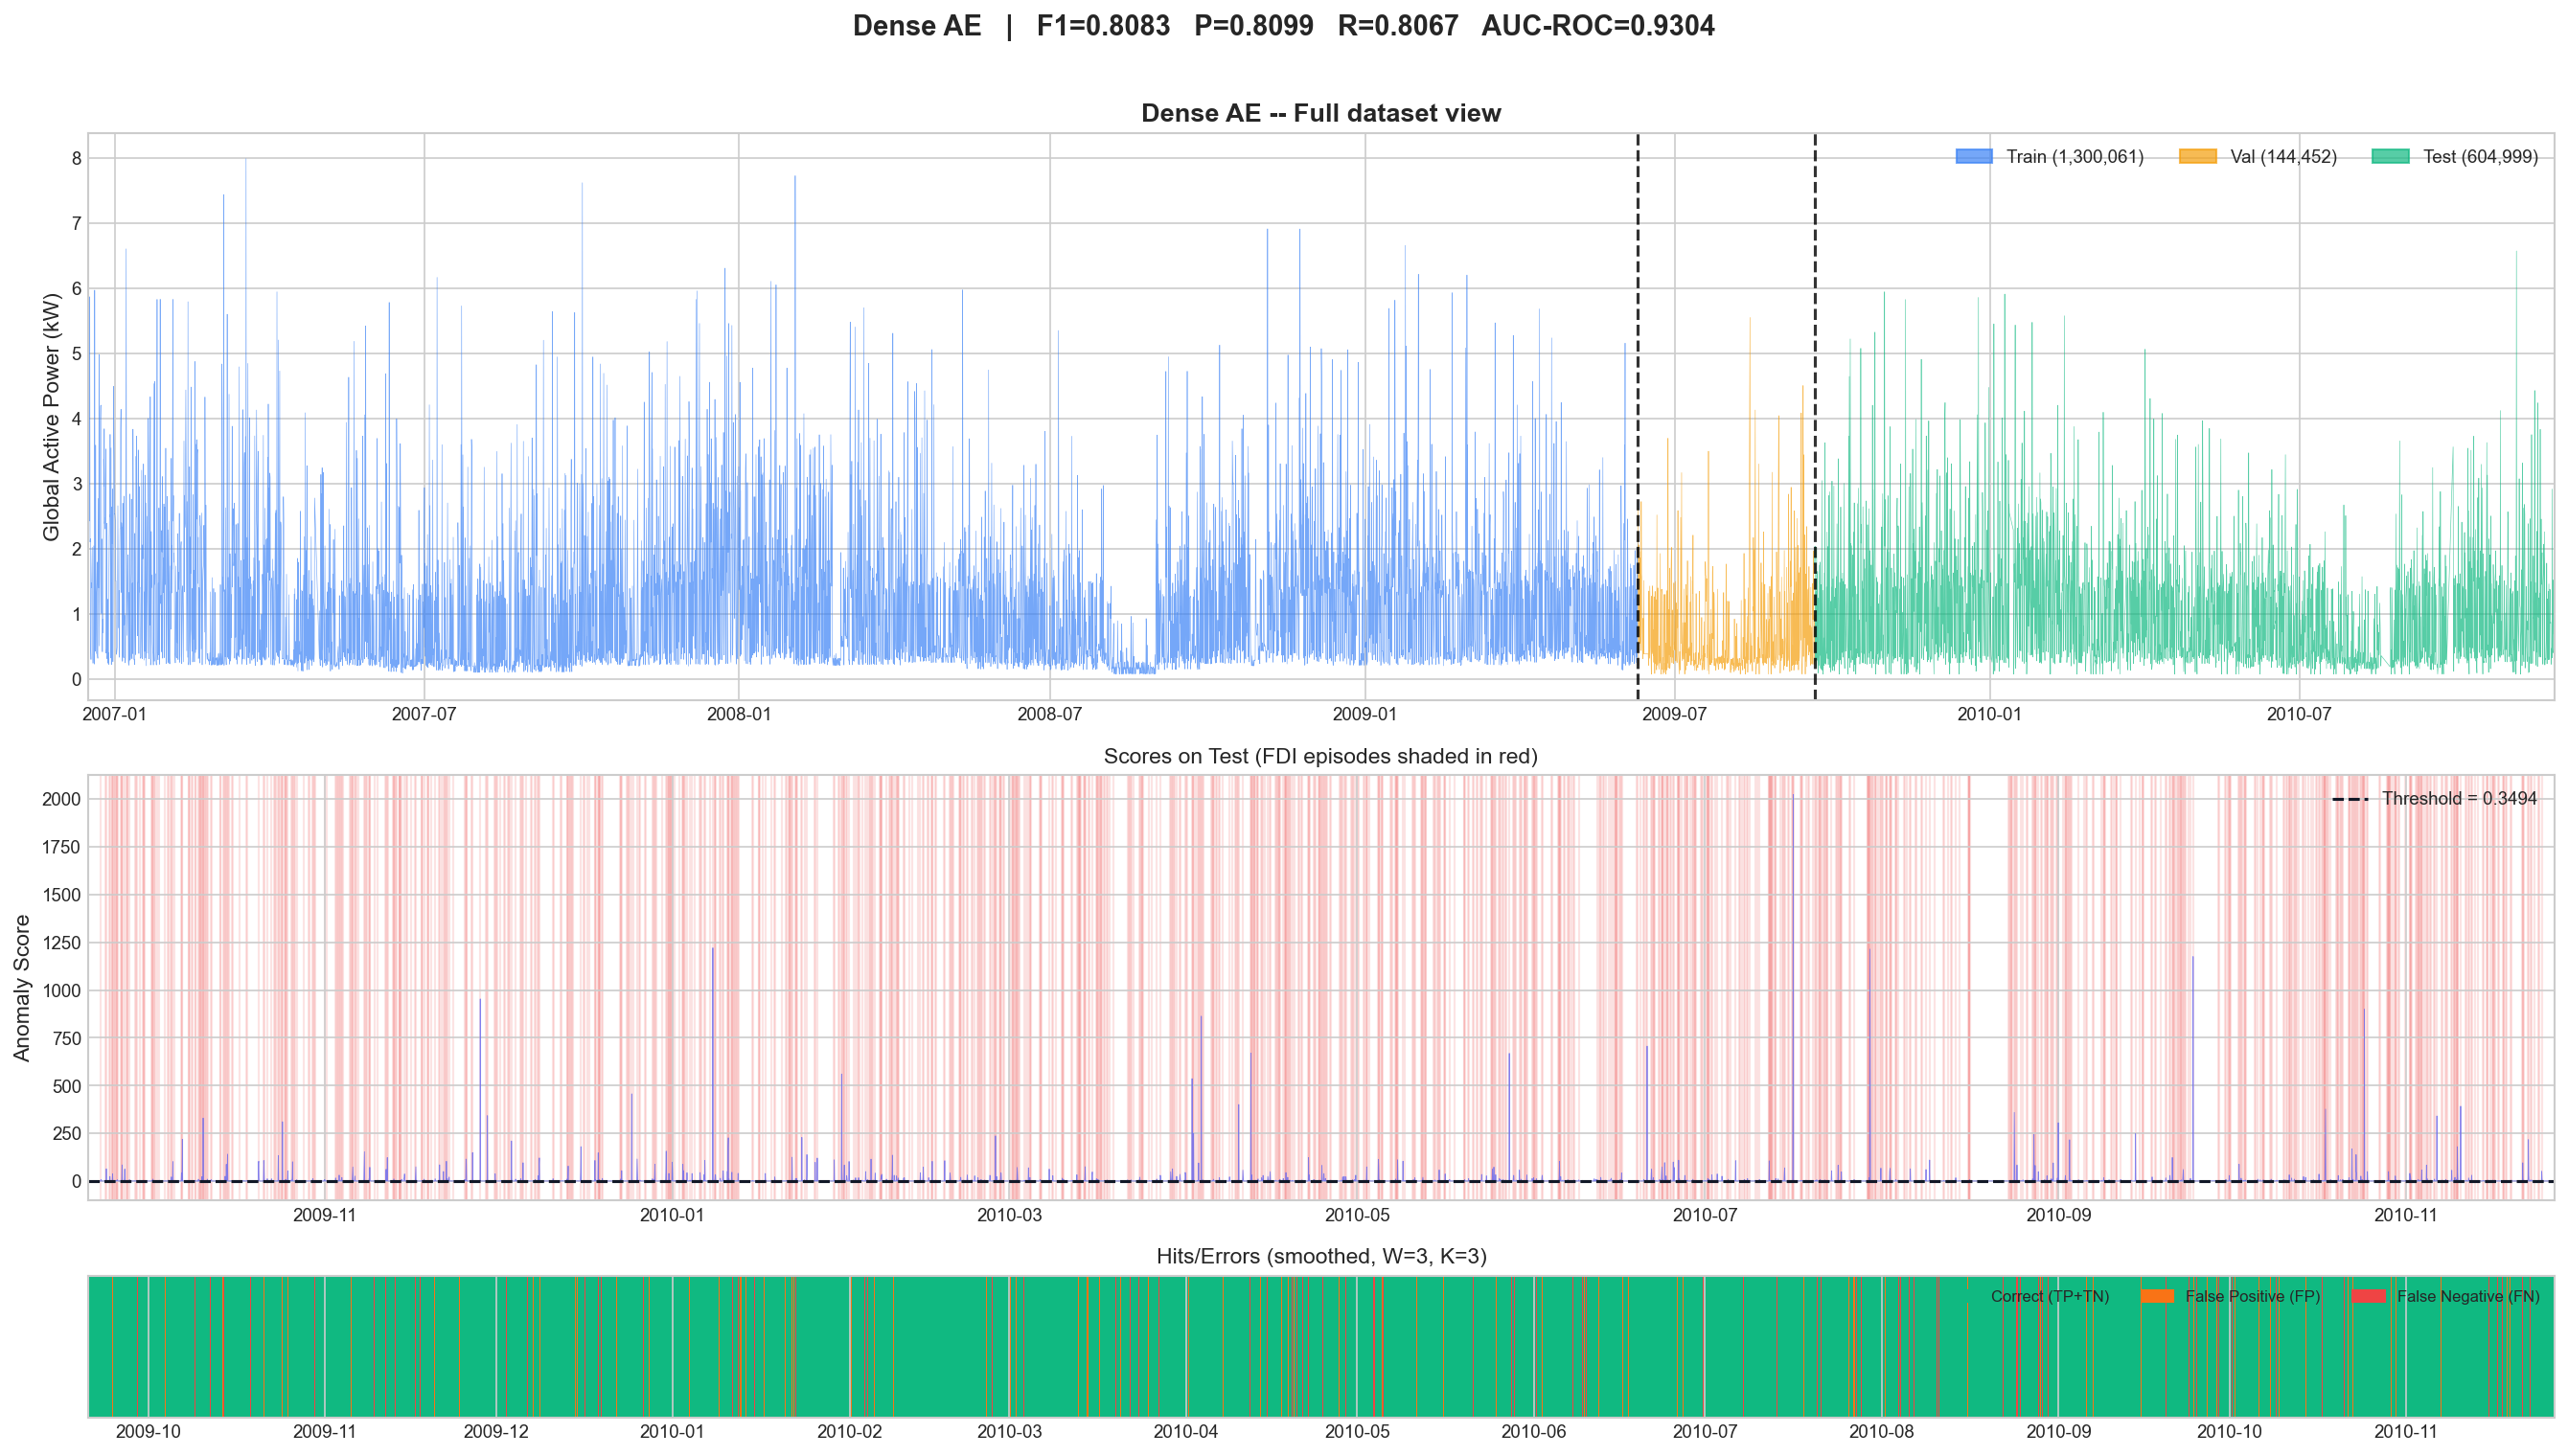


  LSTM AE
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/timeline_lstm_ae.png


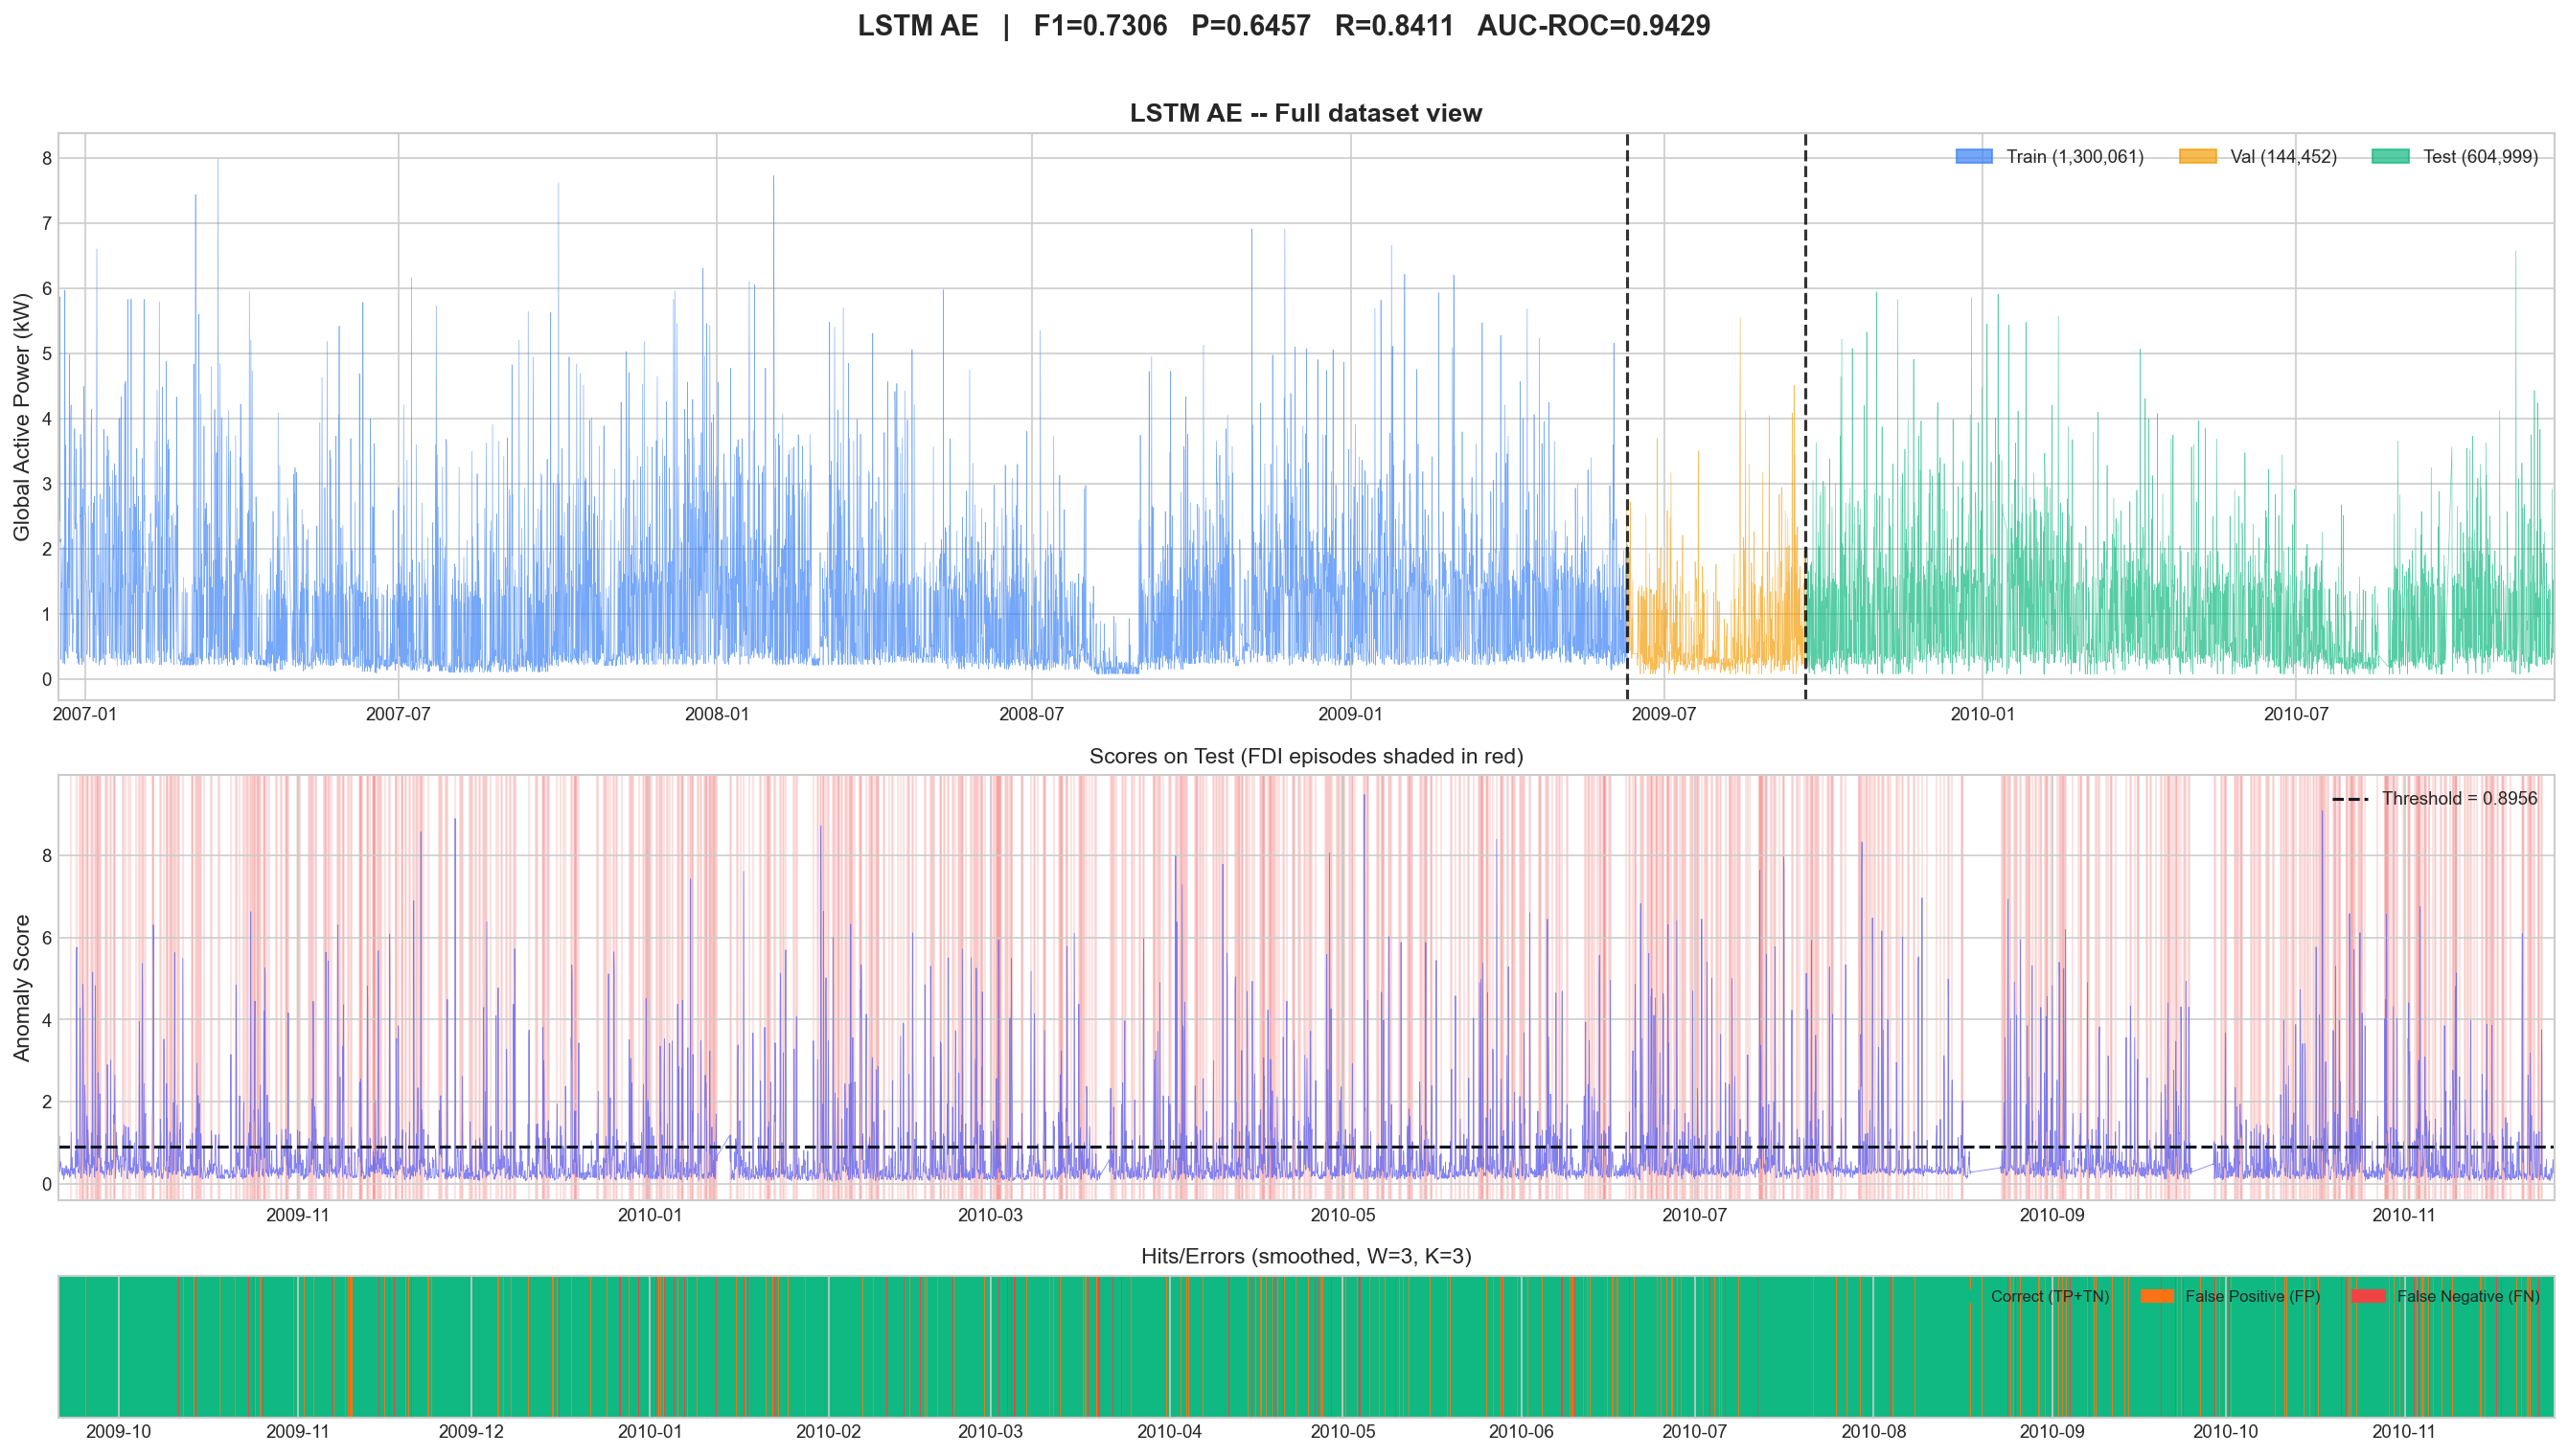

In [4]:
for name, info in MODELS.items():

    print(f'\n{"="*70}')

    print(f'  {name}')

    print(f'{"="*70}')

    

    safe_name = name.lower().replace(' ', '_').replace('+', '_')

    save_path = os.path.join(FIGURES_DIR, f'timeline_{safe_name}.png')

    

    plot_timeline(

        model_name=name,

        df_train=df_train,

        df_val=df_val,

        df_test=df_test,

        df_preds=info['preds'],

        score_col=info['score_col'],

        smooth_col=info['smooth_col'],

        threshold=info['threshold'],

        metrics=info['metrics'],

        save_path=save_path,

    )

## 4. Timeline Zoom -- A Representative Week

A zoomed-in view of a single week containing visible episodes, so that the
detection process can be examined in detail.

Selected week: 2009-09-20 (13 episodes)

  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/timeline_zoom_if.png


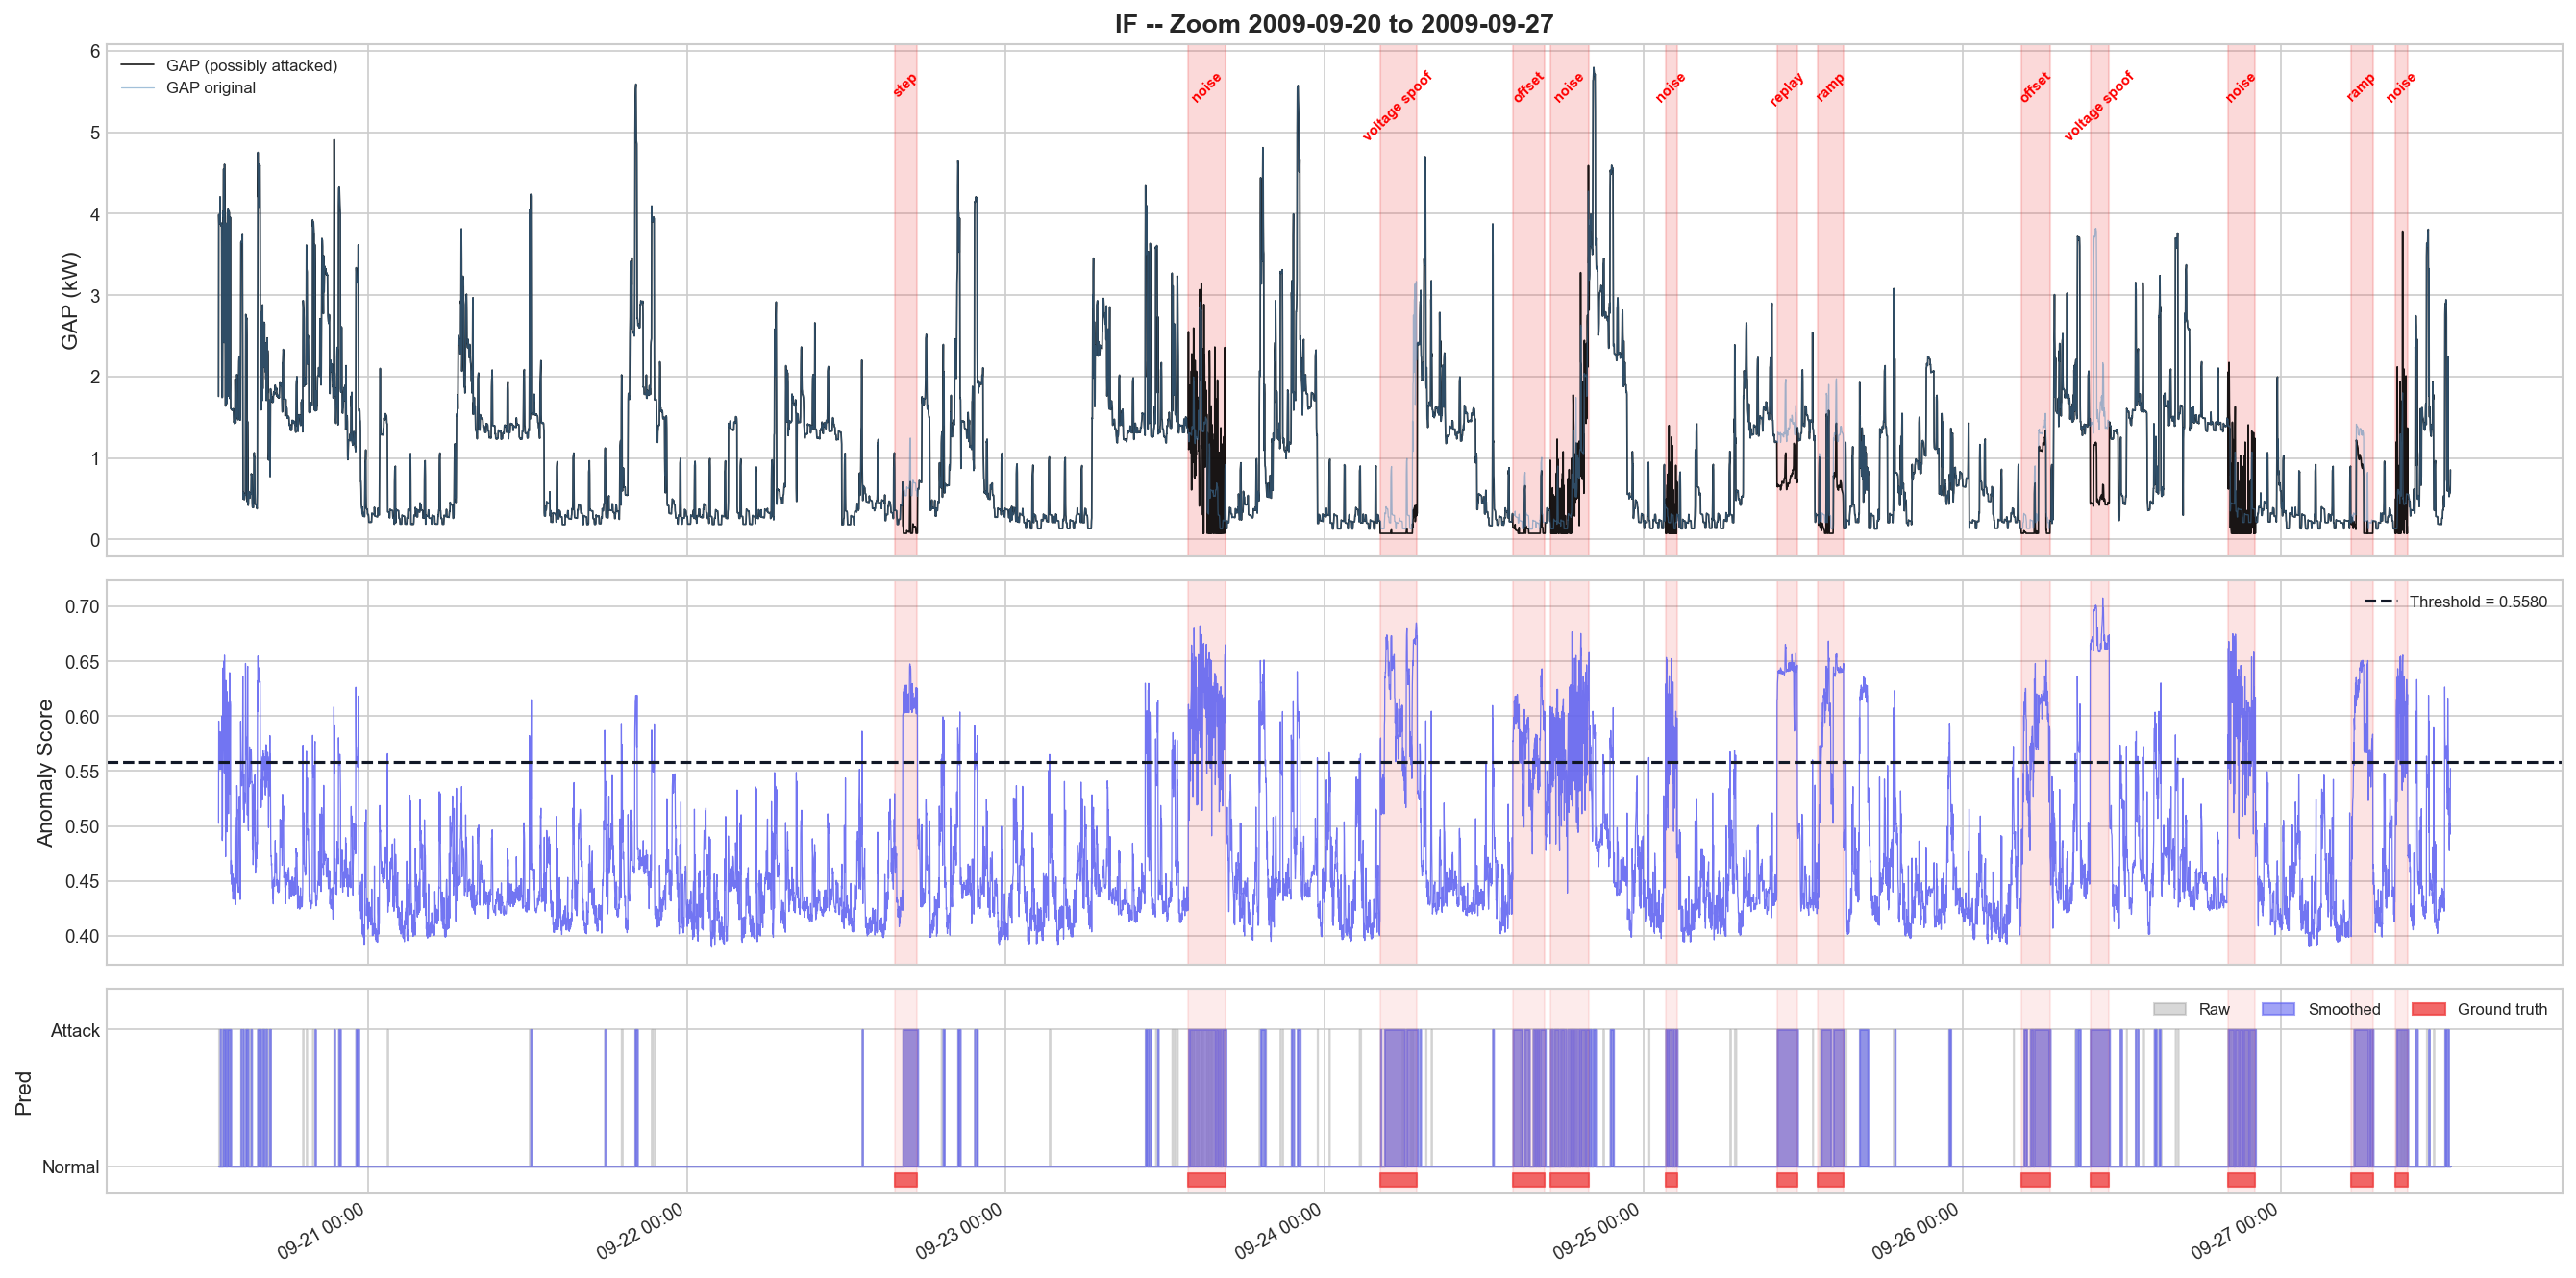

  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/timeline_zoom_k-means_if.png


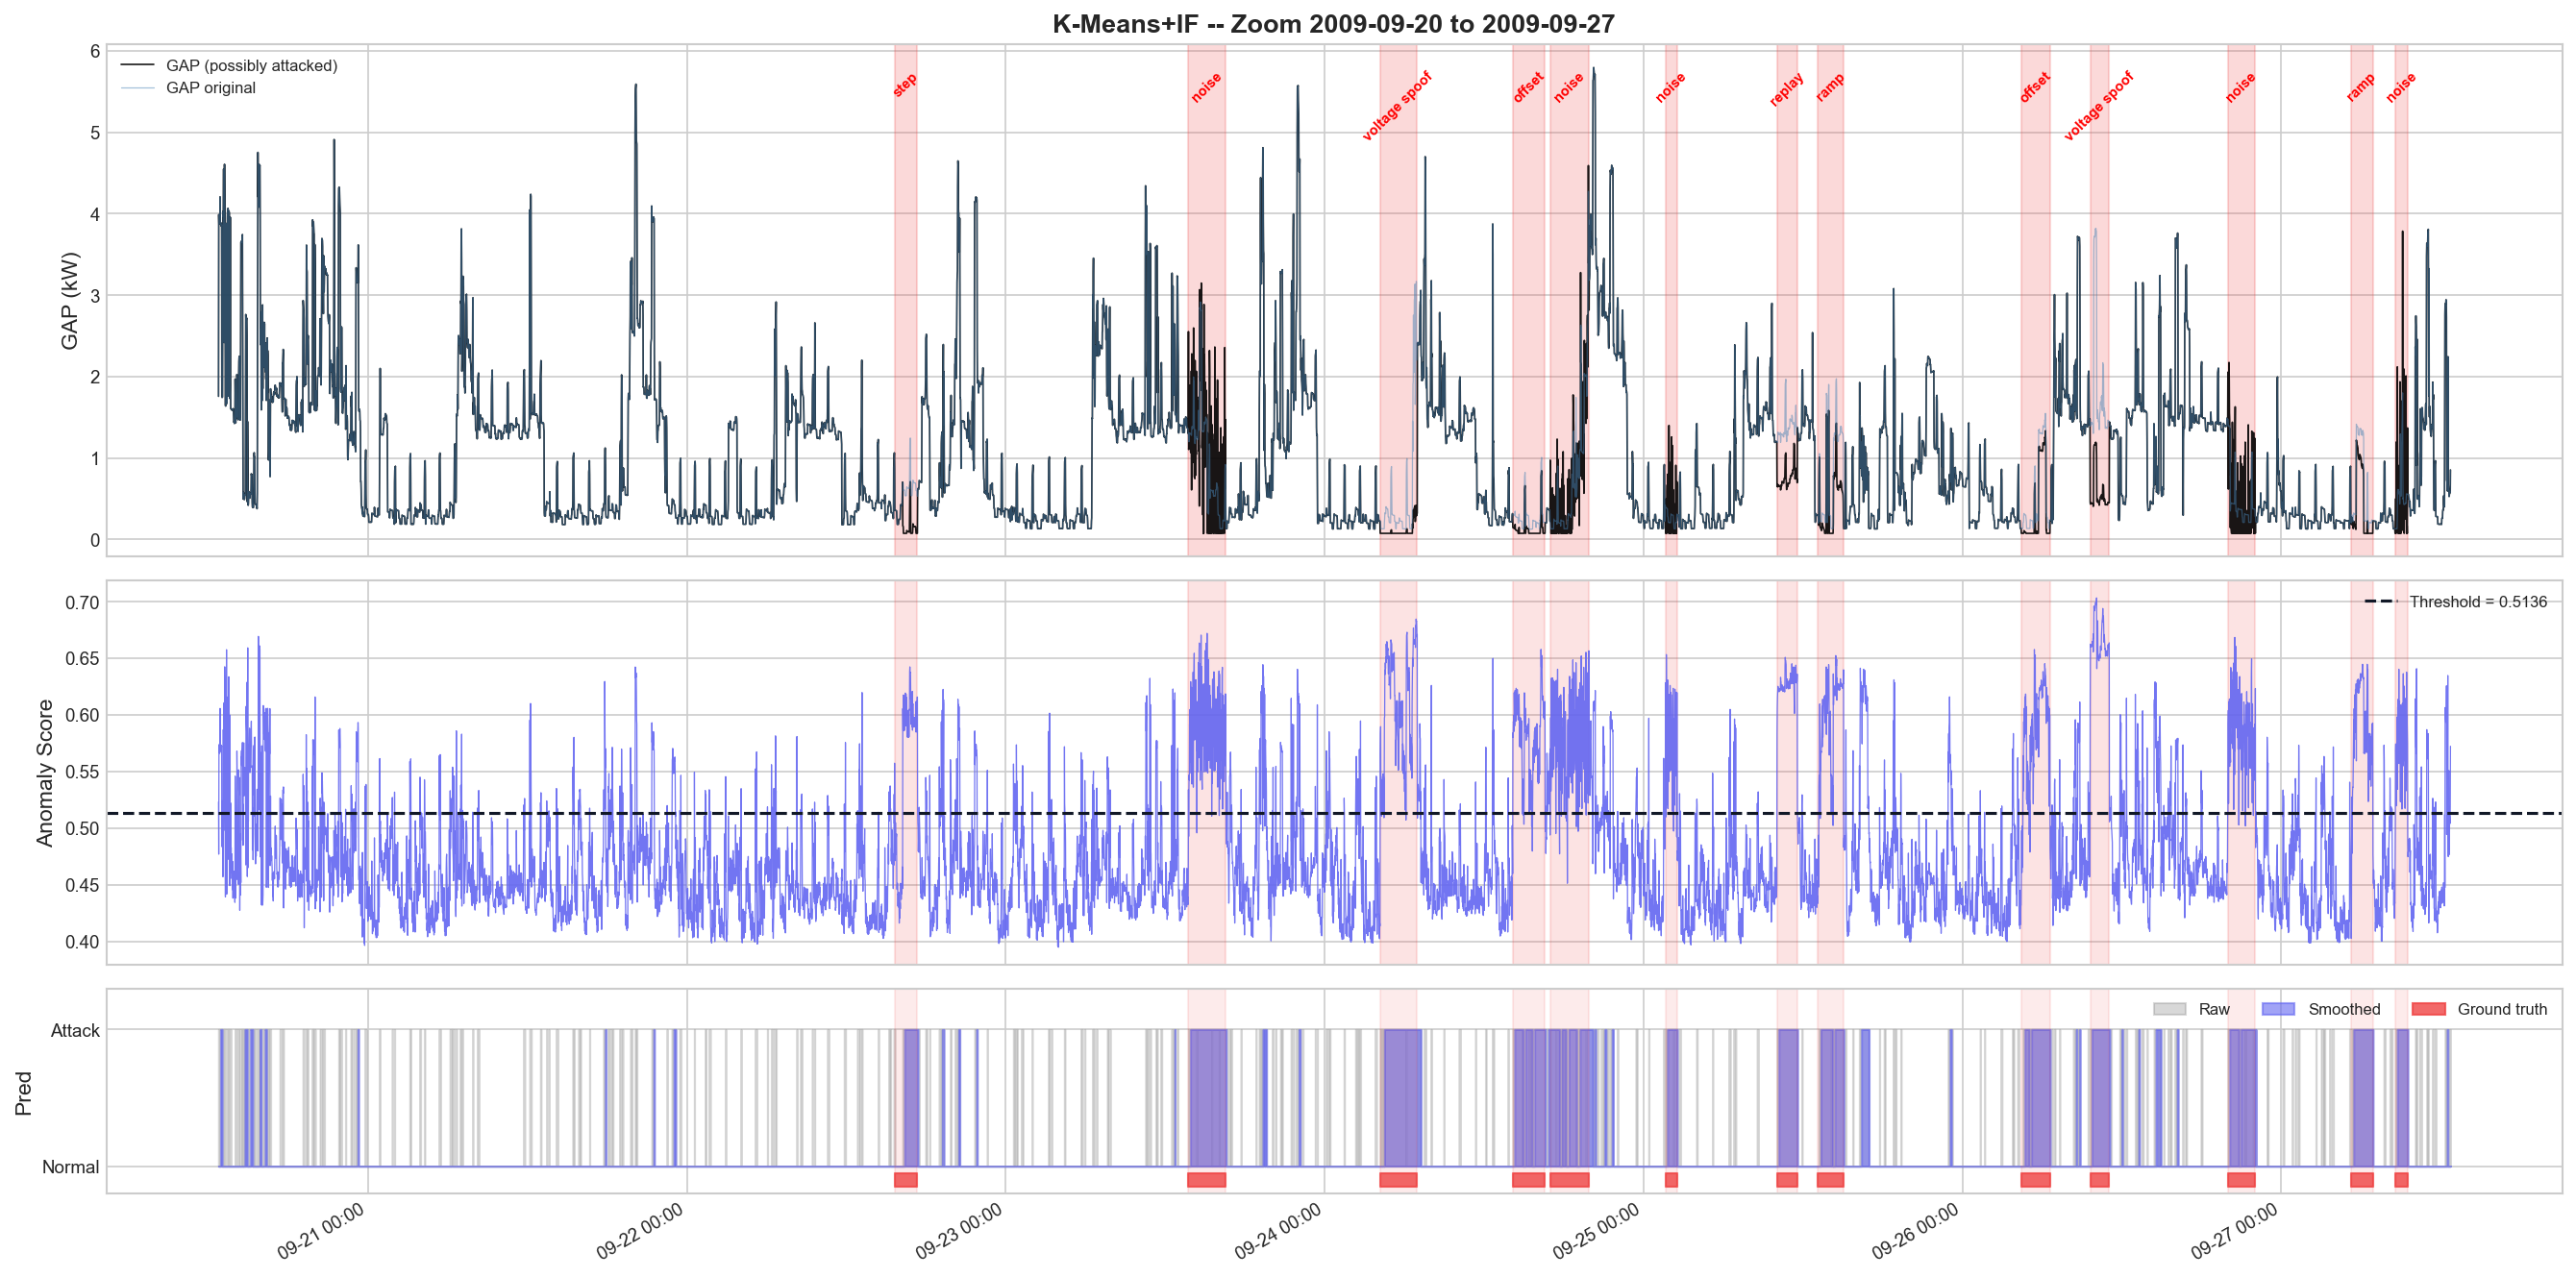

  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/timeline_zoom_dense_ae.png


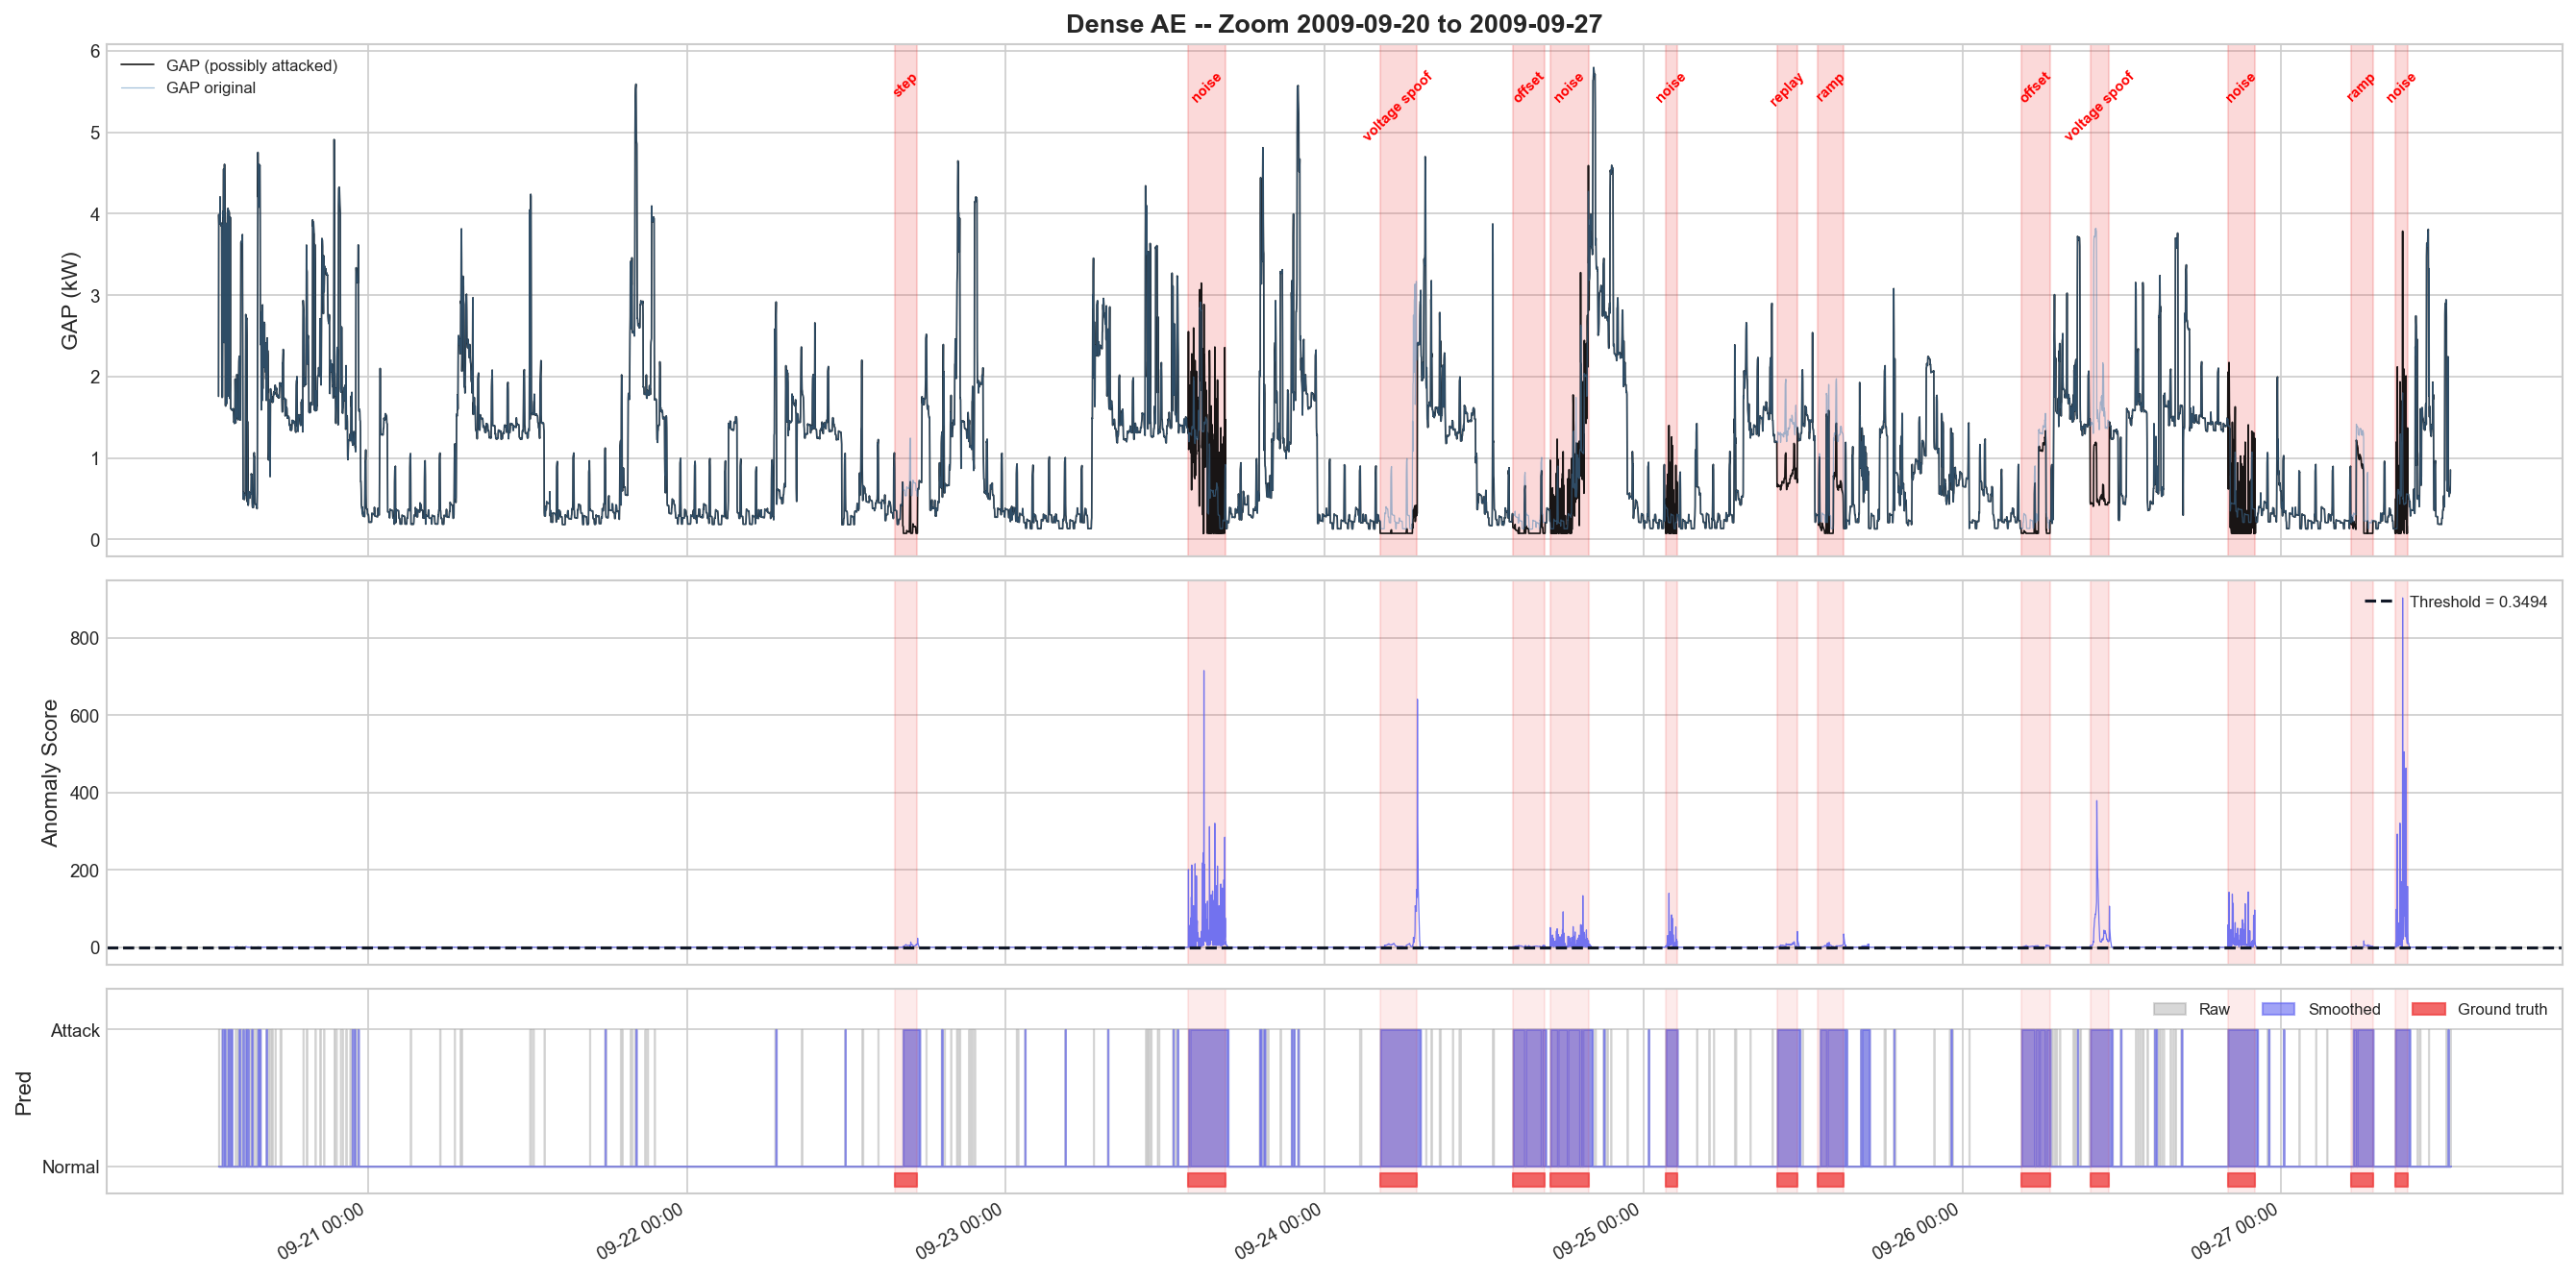

  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/timeline_zoom_lstm_ae.png


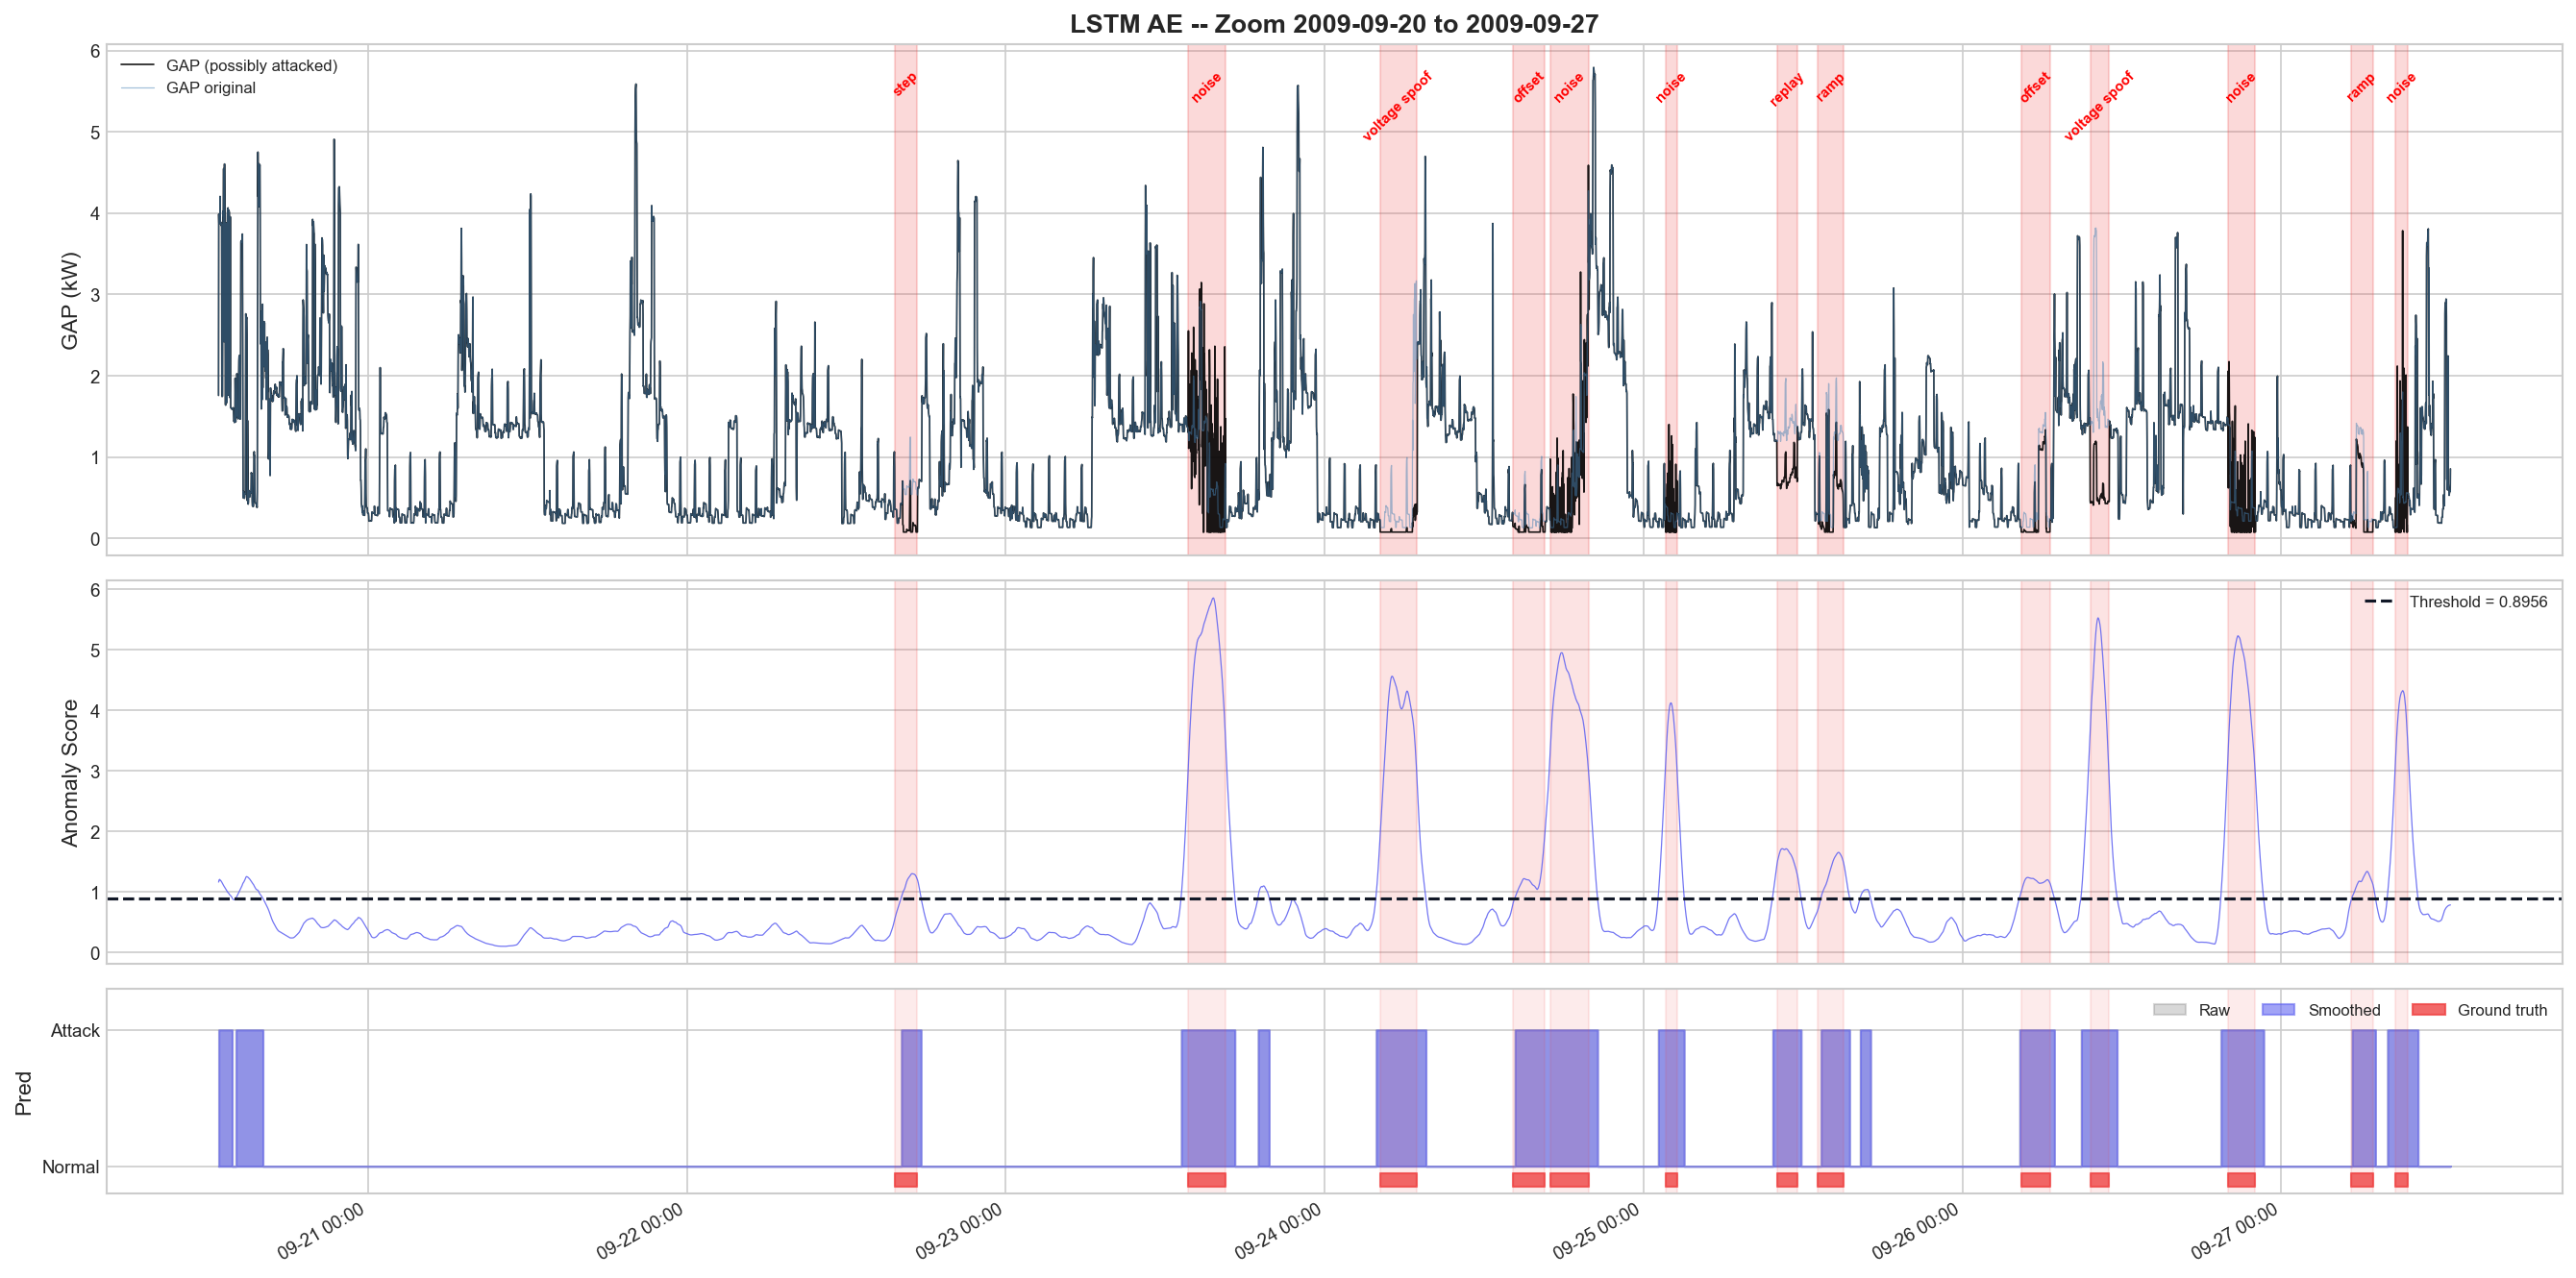

In [5]:
def plot_timeline_zoom(model_name, df_preds, score_col, smooth_col,
                      threshold, metrics, start_date, n_days=7,
                      save_path=None, figsize=(18, 9)):
    '''
    Timeline zoom over a window of n_days days.
    Shows the GAP signal, the scores, and the predictions in enough detail
    to inspect individual episodes.
    '''
    end_date = start_date + pd.Timedelta(days=n_days)
    mask = (df_preds.index >= start_date) & (df_preds.index < end_date)
    df_z = df_preds[mask]

    if len(df_z) == 0:
        print(f'  No data between {start_date} and {end_date}')
        return

    fig, axes = plt.subplots(3, 1, figsize=figsize,
                              gridspec_kw={'height_ratios': [2, 1.5, 0.8]},
                              sharex=True)

    y_true = df_z['label'].values.astype(int)
    scores = df_z[score_col].values
    y_pred = df_z[smooth_col].values.astype(int)

    # Panel 1: original vs attacked GAP
    ax = axes[0]
    ax.plot(df_z.index, df_z['Global_active_power'], 'k-', lw=0.8,
            label='GAP (possibly attacked)', alpha=0.9)
    if 'GAP_original' in df_z.columns:
        ax.plot(df_z.index, df_z['GAP_original'], color='steelblue',
                lw=0.6, alpha=0.5, label='GAP original')

    # Shade the episodes
    episodes_in_range = df_z[df_z['episode_id'] >= 0]
    if len(episodes_in_range) > 0:
        for ep_id in episodes_in_range['episode_id'].unique():
            ep = df_z[df_z['episode_id'] == ep_id]
            ax.axvspan(ep.index[0], ep.index[-1], alpha=0.2,
                       color=COLORS['attack'])
            # Annotate the attack type
            mid = ep.index[len(ep)//2]
            atype = ep['attack_type'].iloc[0]
            ax.text(mid, ax.get_ylim()[1]*0.95, atype.replace('_', ' '),
                    ha='center', va='top', fontsize=7, color='red',
                    fontweight='bold', rotation=45)

    ax.set_ylabel('GAP (kW)')
    ax.set_title(f'{model_name} -- Zoom {start_date.date()} to {end_date.date()}',
                 fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)

    # Panel 2: scores
    ax = axes[1]
    ax.plot(df_z.index, scores, color=COLORS['score'], lw=0.6, alpha=0.9)
    ax.axhline(threshold, color=COLORS['thr'], linestyle='--', lw=1.5,
               label=f'Threshold = {threshold:.4f}')
    for ep_id in episodes_in_range['episode_id'].unique() if len(episodes_in_range) > 0 else []:
        ep = df_z[df_z['episode_id'] == ep_id]
        ax.axvspan(ep.index[0], ep.index[-1], alpha=0.15, color=COLORS['attack'])
    ax.set_ylabel('Anomaly Score')
    ax.legend(loc='upper right', fontsize=8)

    # Panel 3: raw vs smoothed predictions
    ax = axes[2]
    y_raw = df_z[smooth_col.replace('smooth', 'raw')].values.astype(int) if             smooth_col.replace('smooth', 'raw') in df_z.columns else y_pred

    ax.fill_between(df_z.index, 0, y_raw, alpha=0.3, color='gray',
                     step='mid', label='Raw')
    ax.fill_between(df_z.index, 0, y_pred, alpha=0.6, color=COLORS['score'],
                     step='mid', label='Smoothed')
    # Ground truth
    ax.fill_between(df_z.index, -0.15, -0.05, where=(y_true==1),
                     color=COLORS['attack'], alpha=0.8, step='mid',
                     label='Ground truth')
    for ep_id in episodes_in_range['episode_id'].unique() if len(episodes_in_range) > 0 else []:
        ep = df_z[df_z['episode_id'] == ep_id]
        ax.axvspan(ep.index[0], ep.index[-1], alpha=0.1, color=COLORS['attack'])

    ax.set_ylabel('Pred')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Normal', 'Attack'])
    ax.set_ylim(-0.2, 1.3)
    ax.legend(loc='upper right', fontsize=8, ncol=3)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'  Saved: {save_path}')
    plt.show()
    return fig


# -- Pick a week that contains several episodes --
# Take the first week holding at least 3 episodes
test_start = df_test.index[0]
best_week_start = test_start
best_n_eps = 0

for offset_days in range(0, len(df_test) // 1440 - 7, 3):
    ws = test_start + pd.Timedelta(days=offset_days)
    we = ws + pd.Timedelta(days=7)
    mask = (df_test.index >= ws) & (df_test.index < we)
    n_ep = df_test.loc[mask & (df_test['episode_id'] >= 0), 'episode_id'].nunique()
    if n_ep > best_n_eps:
        best_n_eps = n_ep
        best_week_start = ws
    if best_n_eps >= 5:
        break

print(f'Selected week: {best_week_start.date()} ({best_n_eps} episodes)')
print()

# Run the zoom for each model
for name, info in MODELS.items():
    safe_name = name.lower().replace(' ', '_').replace('+', '_')
    save_path = os.path.join(FIGURES_DIR, f'timeline_zoom_{safe_name}.png')

    plot_timeline_zoom(
        model_name=name,
        df_preds=info['preds'],
        score_col=info['score_col'],
        smooth_col=info['smooth_col'],
        threshold=info['threshold'],
        metrics=info['metrics'],
        start_date=best_week_start,
        n_days=7,
        save_path=save_path,
    )

## 5. Episode Grid by Attack Type

For the **best model** (highest F1), we produce one figure per attack type,
each showing:

1. Original vs attacked signal (GAP_original vs Global_active_power)
2. Anomaly score with the threshold
3. Prediction (raw vs smoothed) against the ground truth

In [6]:
def plot_episode(df_preds, episode_id, score_col, raw_col, smooth_col,
                 threshold, model_name, context_min=60,
                 save_path=None, figsize=(16, 9)):
    '''
    Detailed visualization of a single FDI attack episode.

    Three subplots:
      1. Original vs attacked signal (GAP)
      2. Anomaly score with the threshold
      3. Binary prediction (raw vs smoothed) plus ground truth

    Args:
        df_preds:     DataFrame with scores, predictions and metadata
        episode_id:   ID of the episode to plot
        score_col:    anomaly score column
        raw_col:      raw prediction column
        smooth_col:   smoothed prediction column
        threshold:    calibrated threshold
        model_name:   model name (used in the title)
        context_min:  minutes of context to show before and after the episode
    '''
    # Locate the episode
    ep_mask = df_preds['episode_id'] == episode_id
    ep_data = df_preds[ep_mask]

    if len(ep_data) == 0:
        print(f'Episode {episode_id} not found')
        return None

    attack_type = ep_data['attack_type'].iloc[0]
    severity = ep_data['severity'].iloc[0]
    ep_start = ep_data.index[0]
    ep_end = ep_data.index[-1]
    duration = len(ep_data)

    # Surrounding temporal context
    ctx_start = ep_start - pd.Timedelta(minutes=context_min)
    ctx_end = ep_end + pd.Timedelta(minutes=context_min)
    ctx = df_preds.loc[ctx_start:ctx_end]

    if len(ctx) == 0:
        print(f'No context data for episode {episode_id}')
        return None

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True,
                              gridspec_kw={'height_ratios': [2, 1.5, 0.8]})

    # -- Panel 1: original vs attacked signal --
    ax = axes[0]
    ax.plot(ctx.index, ctx['Global_active_power'], 'k-', lw=1.2,
            label='GAP (attacked)', zorder=3)
    if 'GAP_original' in ctx.columns:
        ax.plot(ctx.index, ctx['GAP_original'], color='steelblue',
                lw=1, alpha=0.7, linestyle='--', label='GAP original', zorder=2)
    ax.axvspan(ep_start, ep_end, alpha=0.2, color=COLORS['attack'],
               label=f'FDI episode ({duration} min)')
    ax.set_ylabel('GAP (kW)')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_title(f'{model_name} -- {attack_type.replace("_", " ").title()} '
                 f'({severity}), {duration} min',
                 fontweight='bold', fontsize=13)

    # -- Panel 2: anomaly score --
    ax = axes[1]
    ax.plot(ctx.index, ctx[score_col], color=COLORS['score'], lw=0.8)
    ax.axhline(threshold, color=COLORS['thr'], linestyle='--', lw=1.5,
               label=f'Threshold = {threshold:.4f}')
    ax.axvspan(ep_start, ep_end, alpha=0.15, color=COLORS['attack'])

    # Highlight the score within the episode
    ep_ctx = ctx.loc[ep_start:ep_end]
    ax.fill_between(ep_ctx.index, threshold, ep_ctx[score_col],
                     where=(ep_ctx[score_col] > threshold),
                     color=COLORS['tp'], alpha=0.3, label='Score > threshold')
    ax.fill_between(ep_ctx.index, threshold, ep_ctx[score_col],
                     where=(ep_ctx[score_col] <= threshold),
                     color=COLORS['fn'], alpha=0.3, label='Score <= threshold')

    ax.set_ylabel('Anomaly Score')
    ax.legend(loc='upper right', fontsize=8)

    # -- Panel 3: binary prediction --
    ax = axes[2]

    if raw_col in ctx.columns:
        ax.fill_between(ctx.index, 0, ctx[raw_col].values,
                         alpha=0.25, color='gray', step='mid', label='Raw')
    ax.fill_between(ctx.index, 0, ctx[smooth_col].values,
                     alpha=0.6, color=COLORS['score'], step='mid',
                     label='Smoothed')

    # Ground truth shown as a bottom band
    y_true = ctx['label'].values
    ax.fill_between(ctx.index, -0.15, -0.05, where=(y_true == 1),
                     color=COLORS['attack'], alpha=0.8, step='mid',
                     label='Ground truth')

    ax.axvspan(ep_start, ep_end, alpha=0.1, color=COLORS['attack'])
    ax.set_ylabel('Pred')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Normal', 'Attack'])
    ax.set_ylim(-0.2, 1.3)
    ax.legend(loc='upper right', fontsize=8, ncol=4)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.xticks(rotation=0)
    ax.set_xlabel(f'{ep_start.date()}')

    # -- Per-episode metrics --
    ep_preds_smooth = ep_data[smooth_col].values.astype(int)
    ep_true = ep_data['label'].values.astype(int)
    recall_ep = ep_preds_smooth.sum() / max(ep_true.sum(), 1)

    # Detection latency: first minute flagged as an attack
    detected_idx = np.where(ep_preds_smooth == 1)[0]
    latency = detected_idx[0] if len(detected_idx) > 0 else -1
    latency_str = f'{latency} min' if latency >= 0 else 'Not detected'

    fig.text(0.02, -0.02,
             f'Episode recall: {recall_ep:.0%}  |  '
             f'Latency: {latency_str}  |  '
             f'Duration: {duration} min  |  '
             f'Severity: {severity}',
             fontsize=10, ha='left', style='italic')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'  Saved: {save_path}')
    plt.show()
    return fig


print('plot_episode() defined')

plot_episode() defined


## 6. Episodes by Attack Type -- Best Model

Best model: Dense AE (F1=0.8083)


--- scaling ---
  Episode 35: medium, 83 min
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/episode_scaling.png


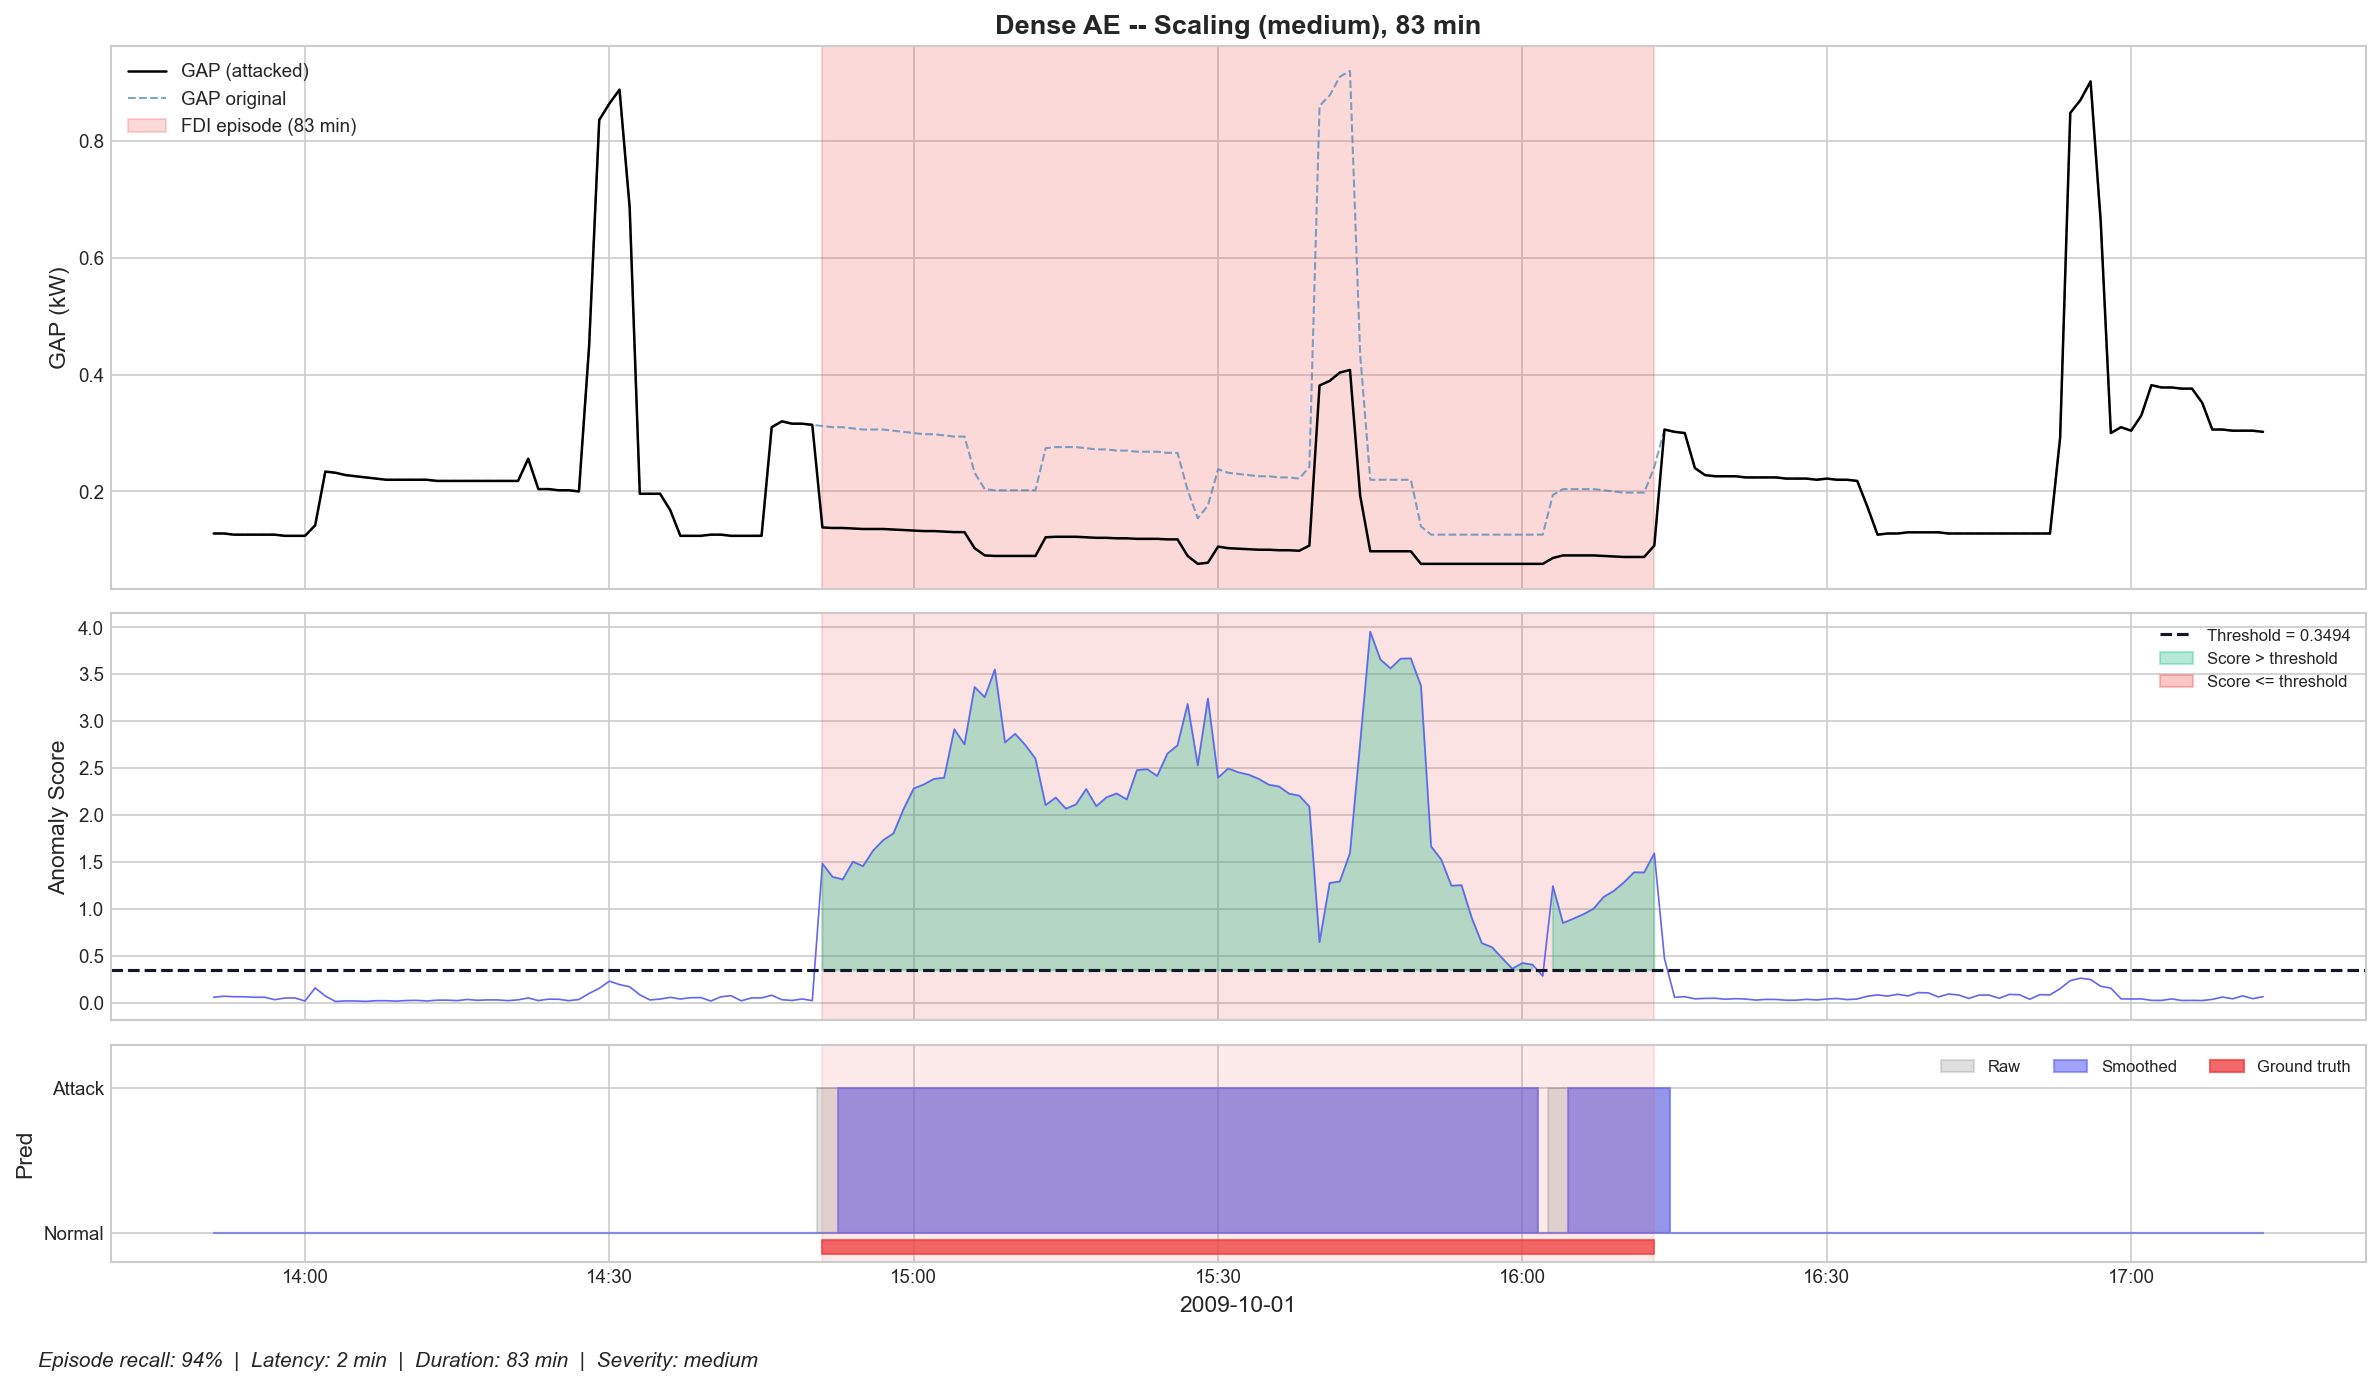


--- offset ---
  Episode 209: medium, 130 min
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/episode_offset.png


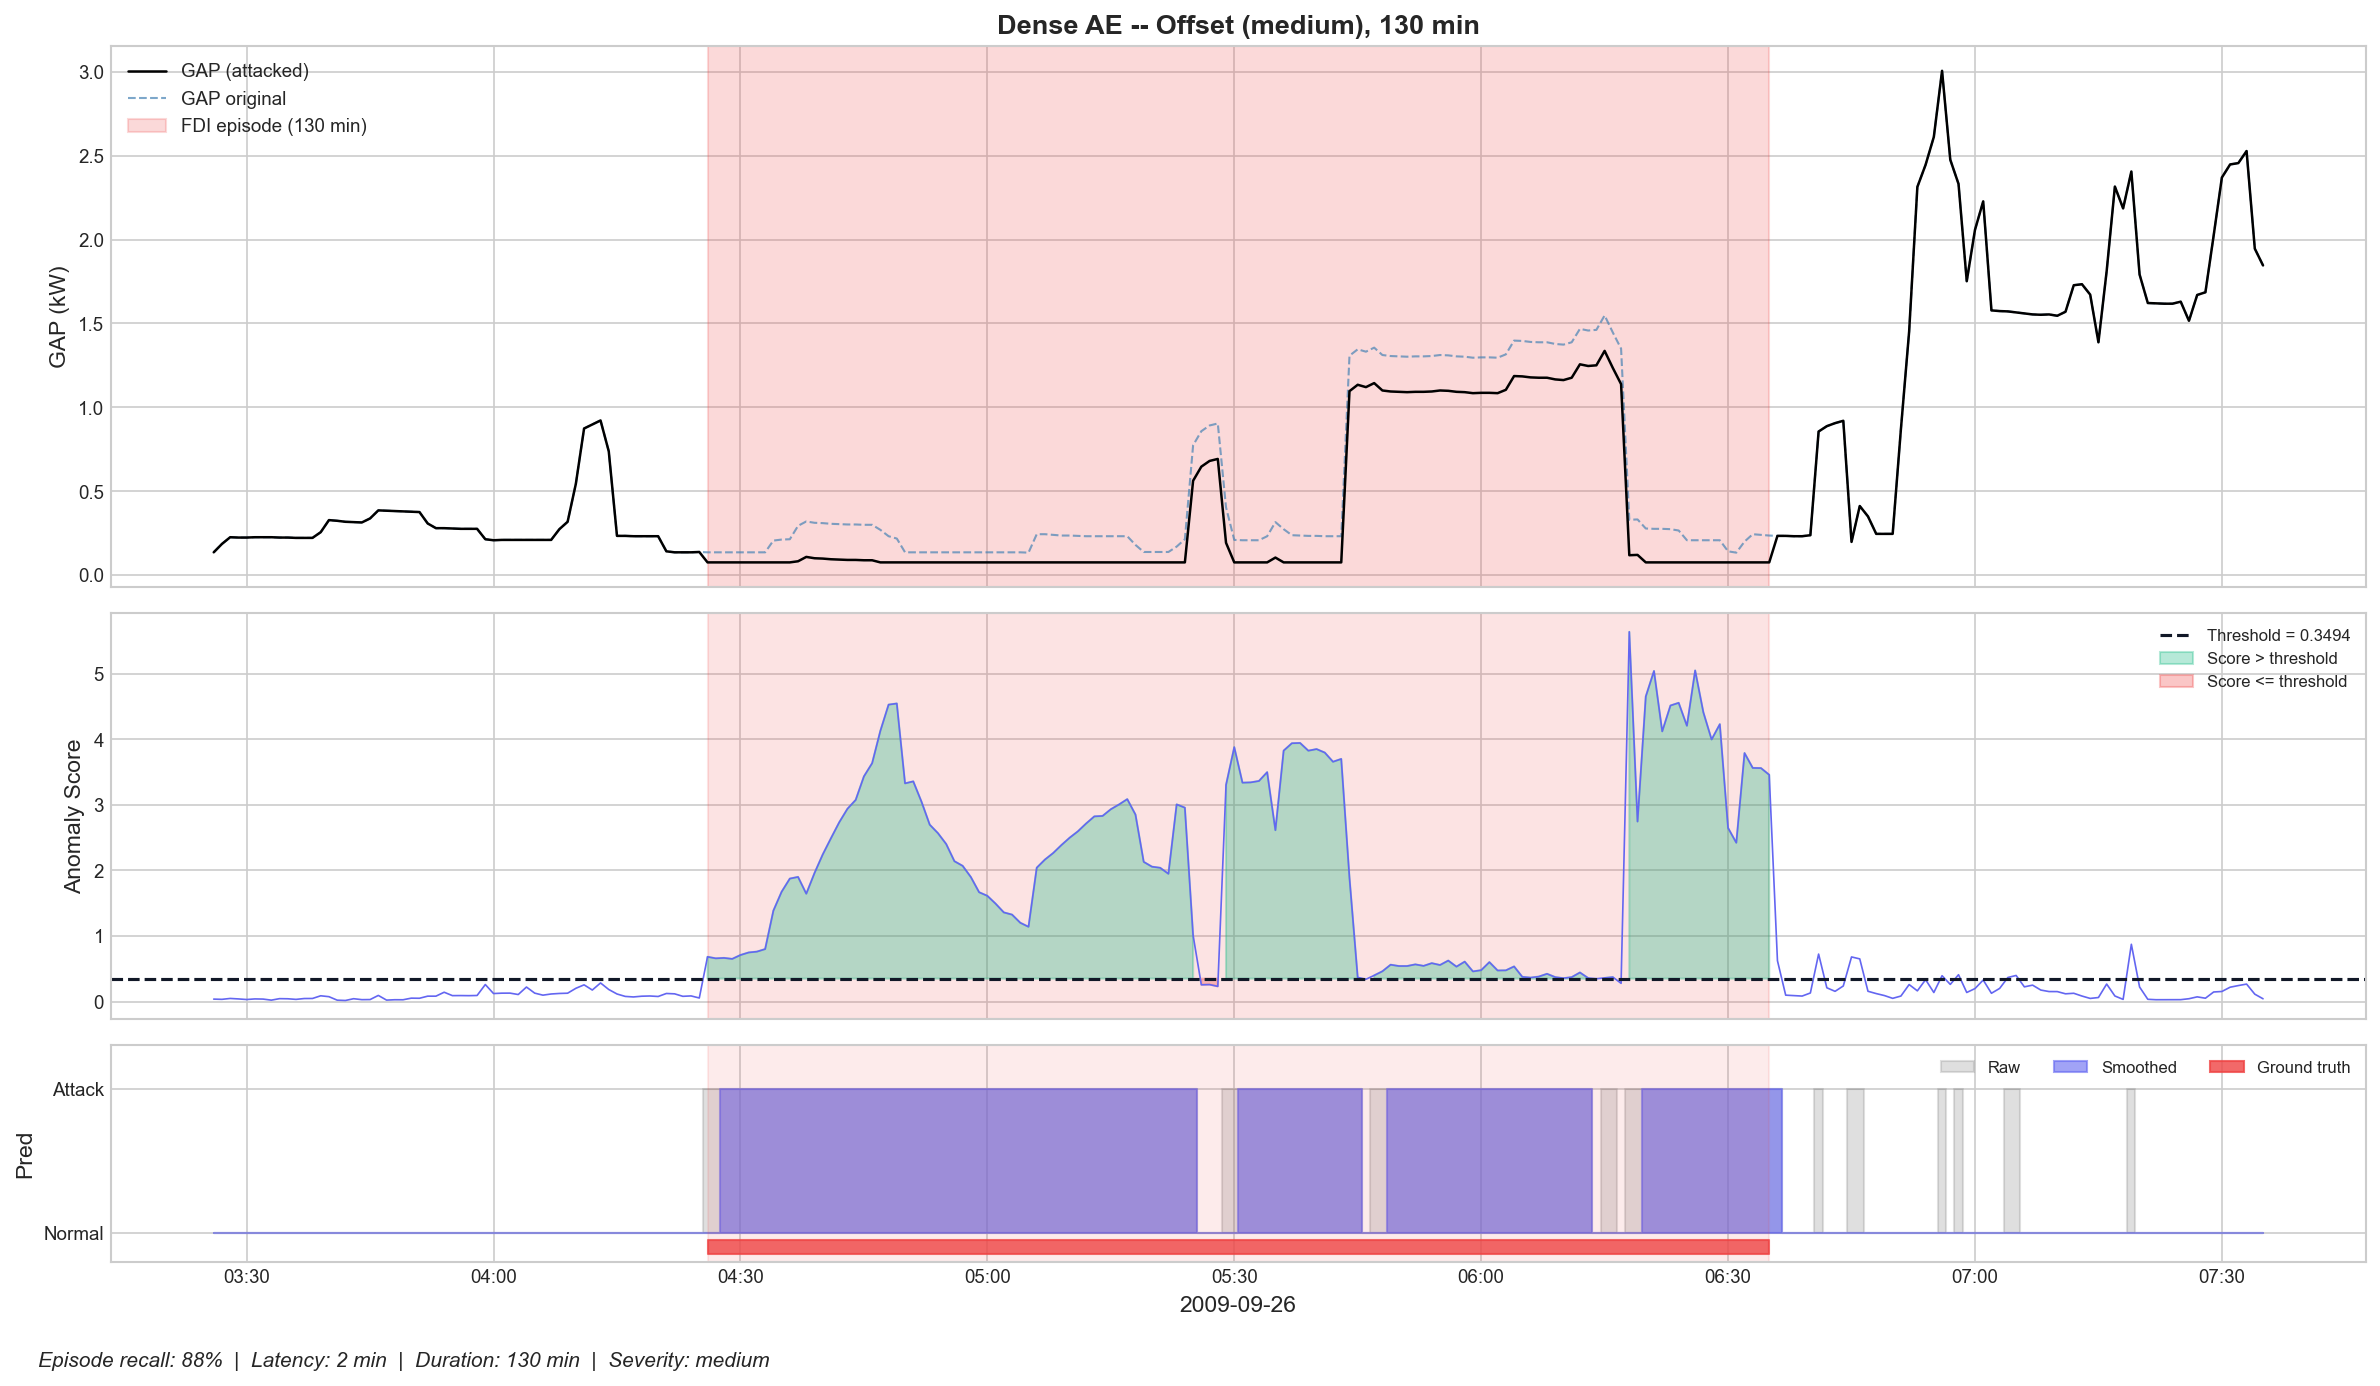


--- noise ---
  Episode 351: medium, 169 min
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/episode_noise.png


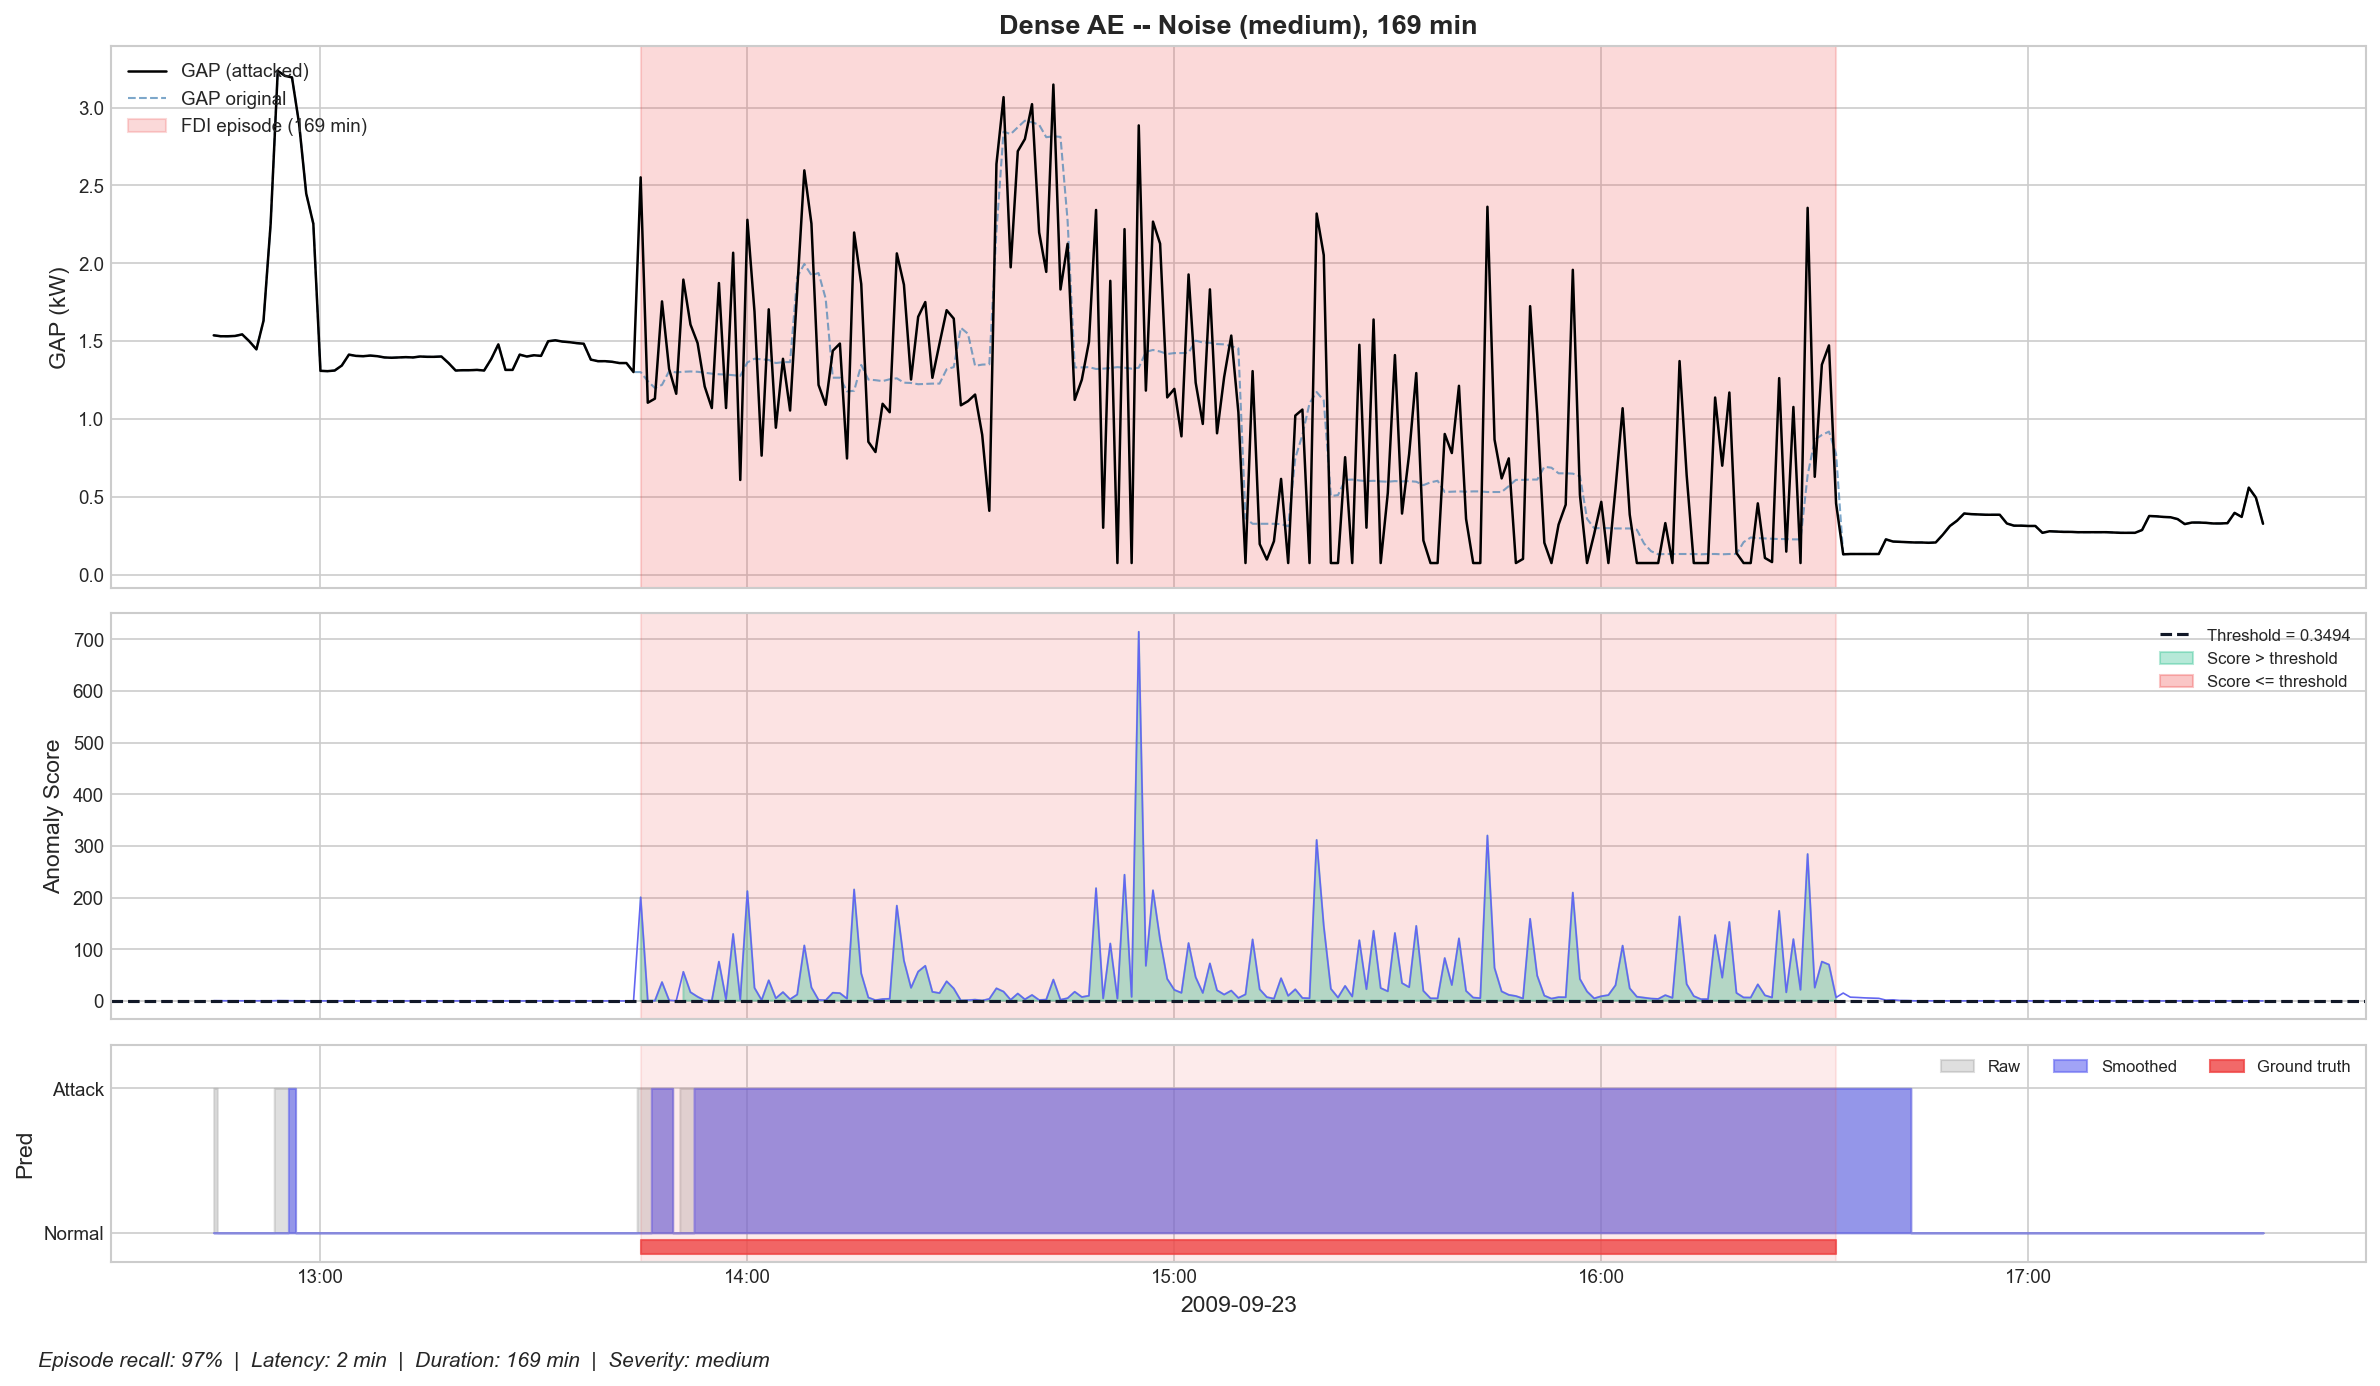


--- ramp ---
  Episode 380: medium, 71 min
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/episode_ramp.png


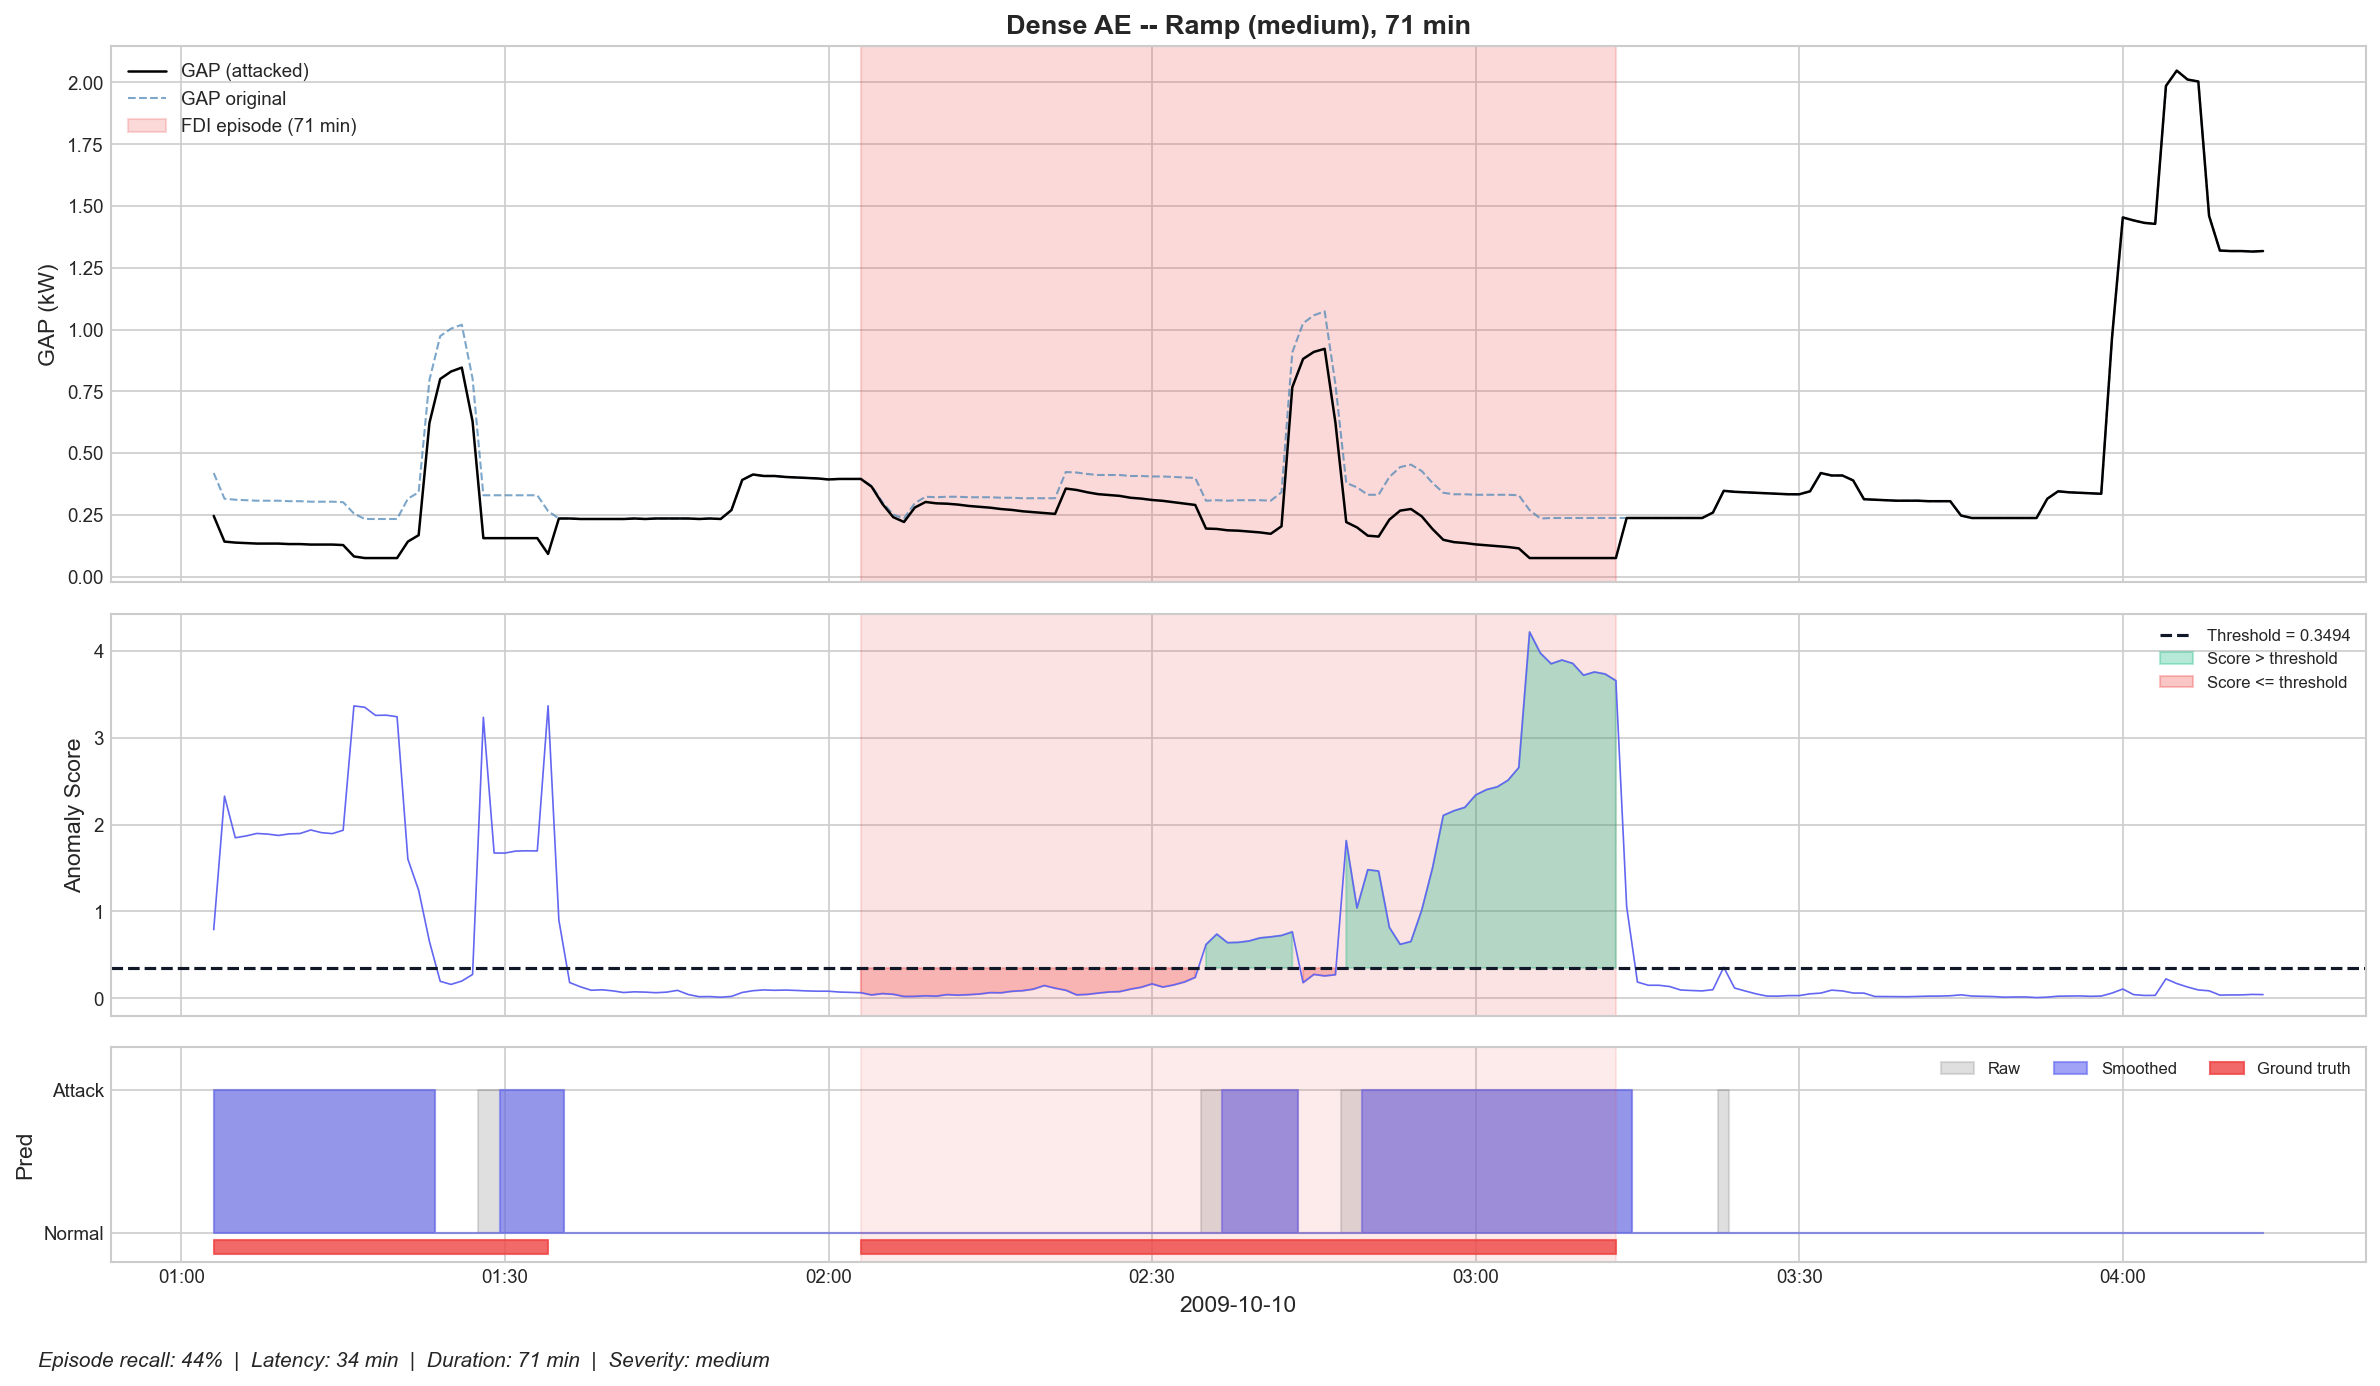


--- step ---
  Episode 543: medium, 95 min
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/episode_step.png


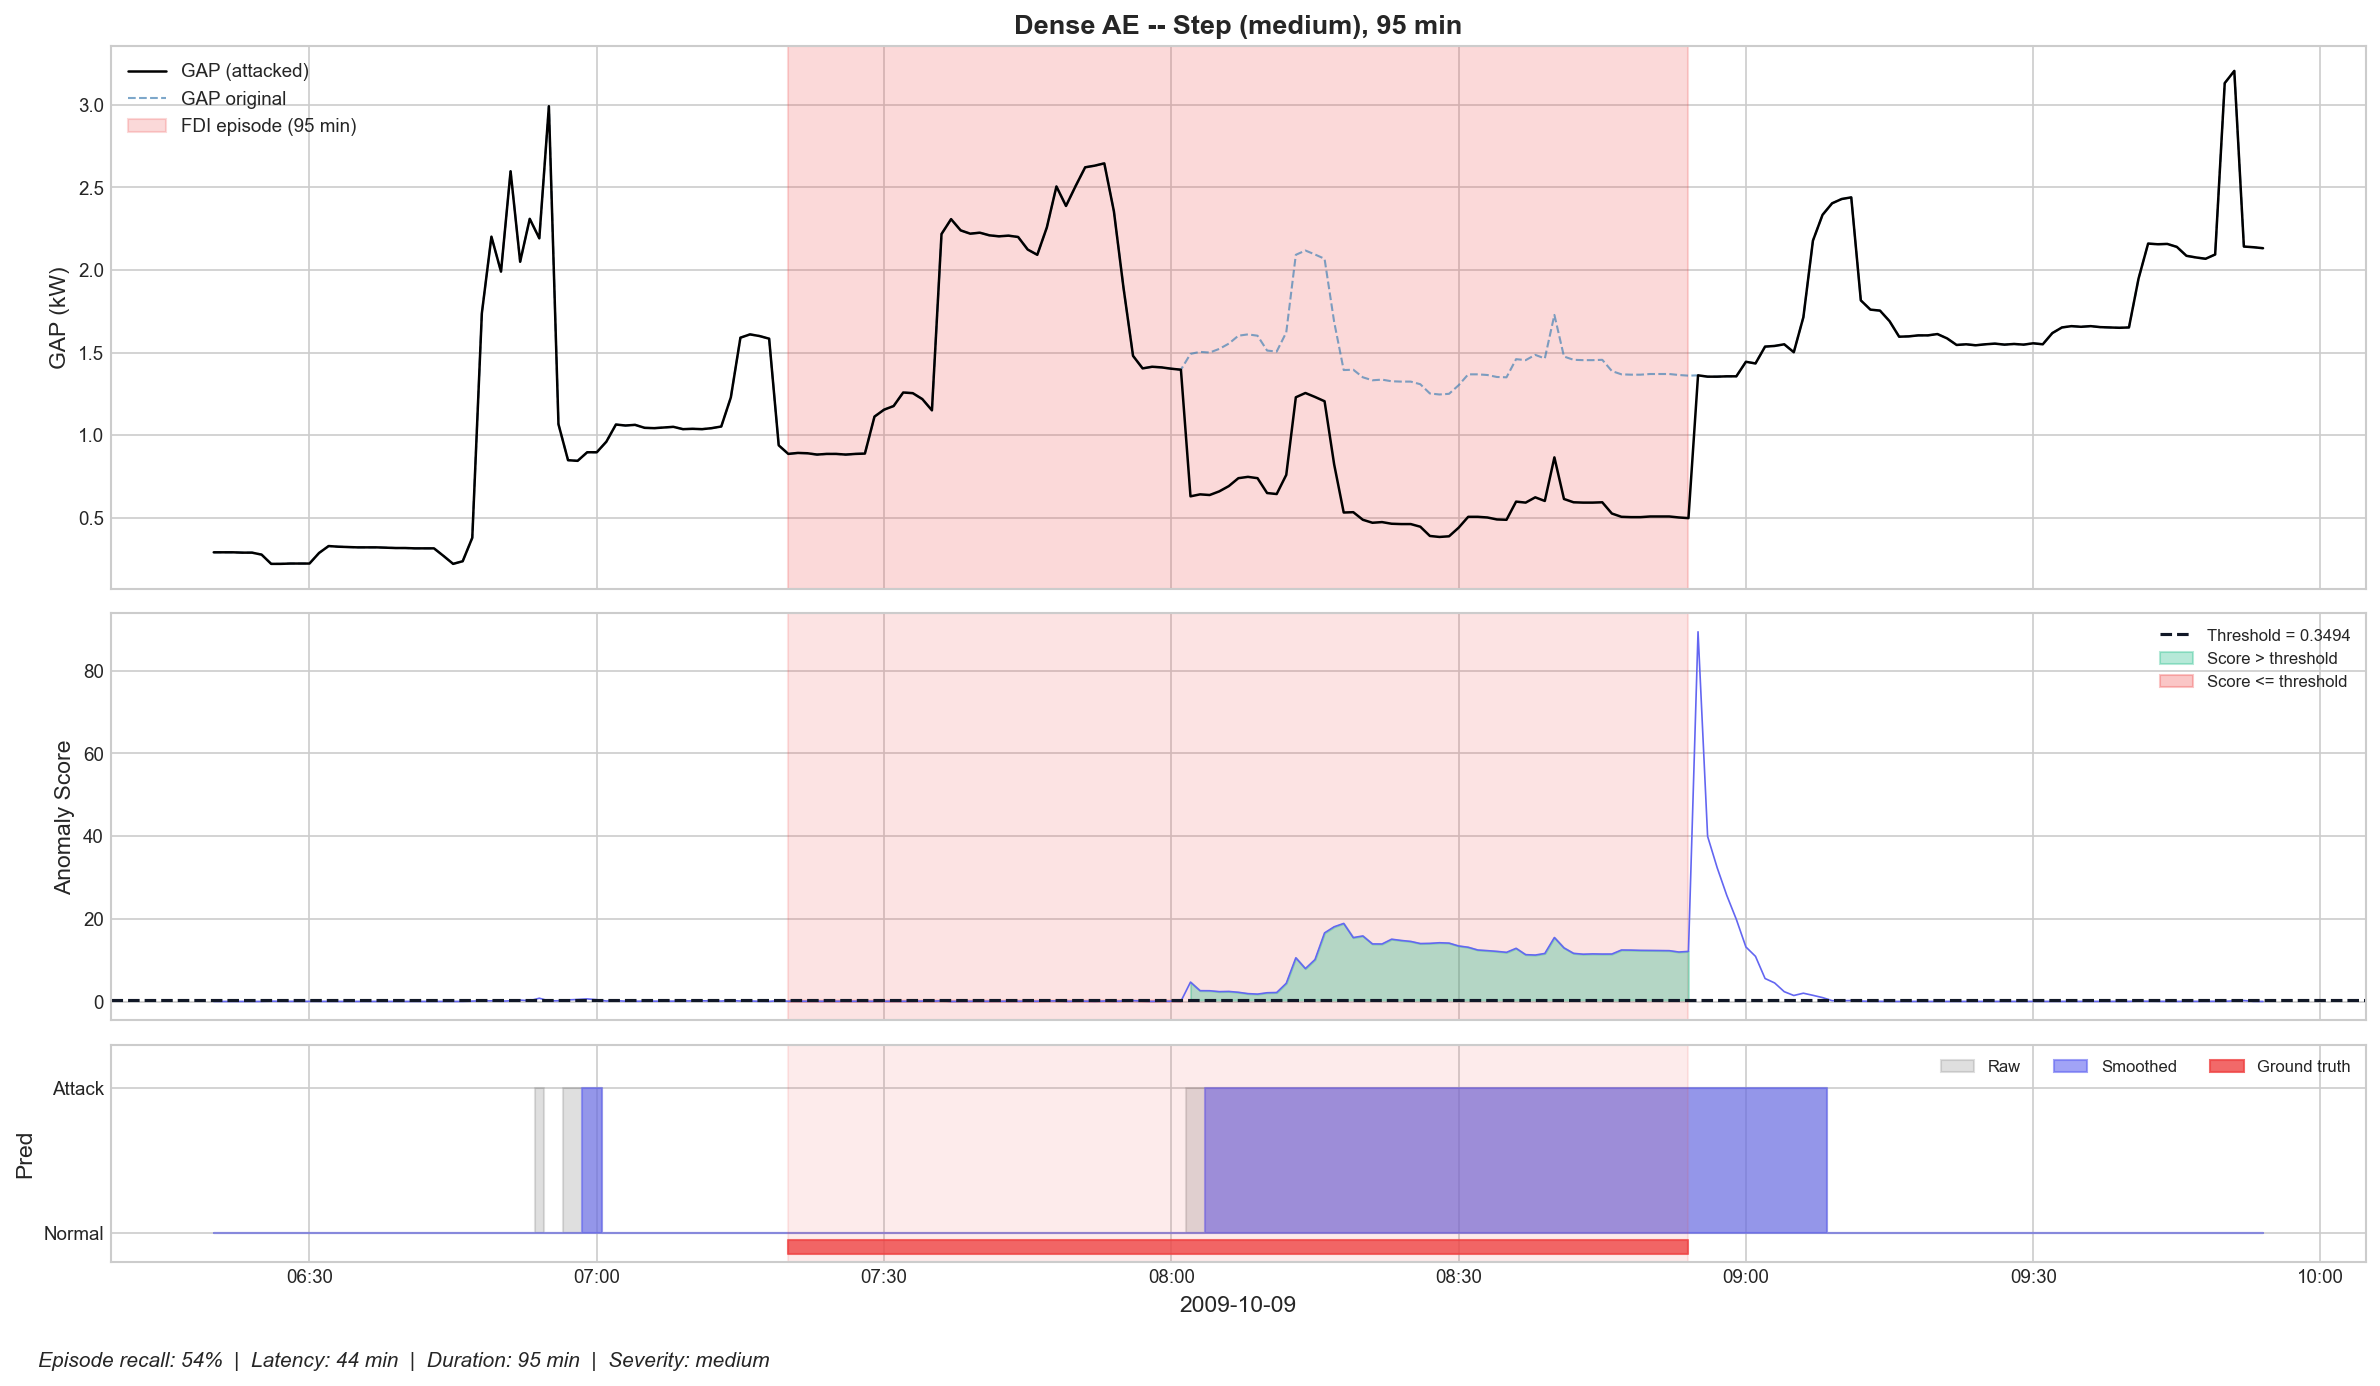


--- replay ---
  Episode 604: medium, 92 min
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/episode_replay.png


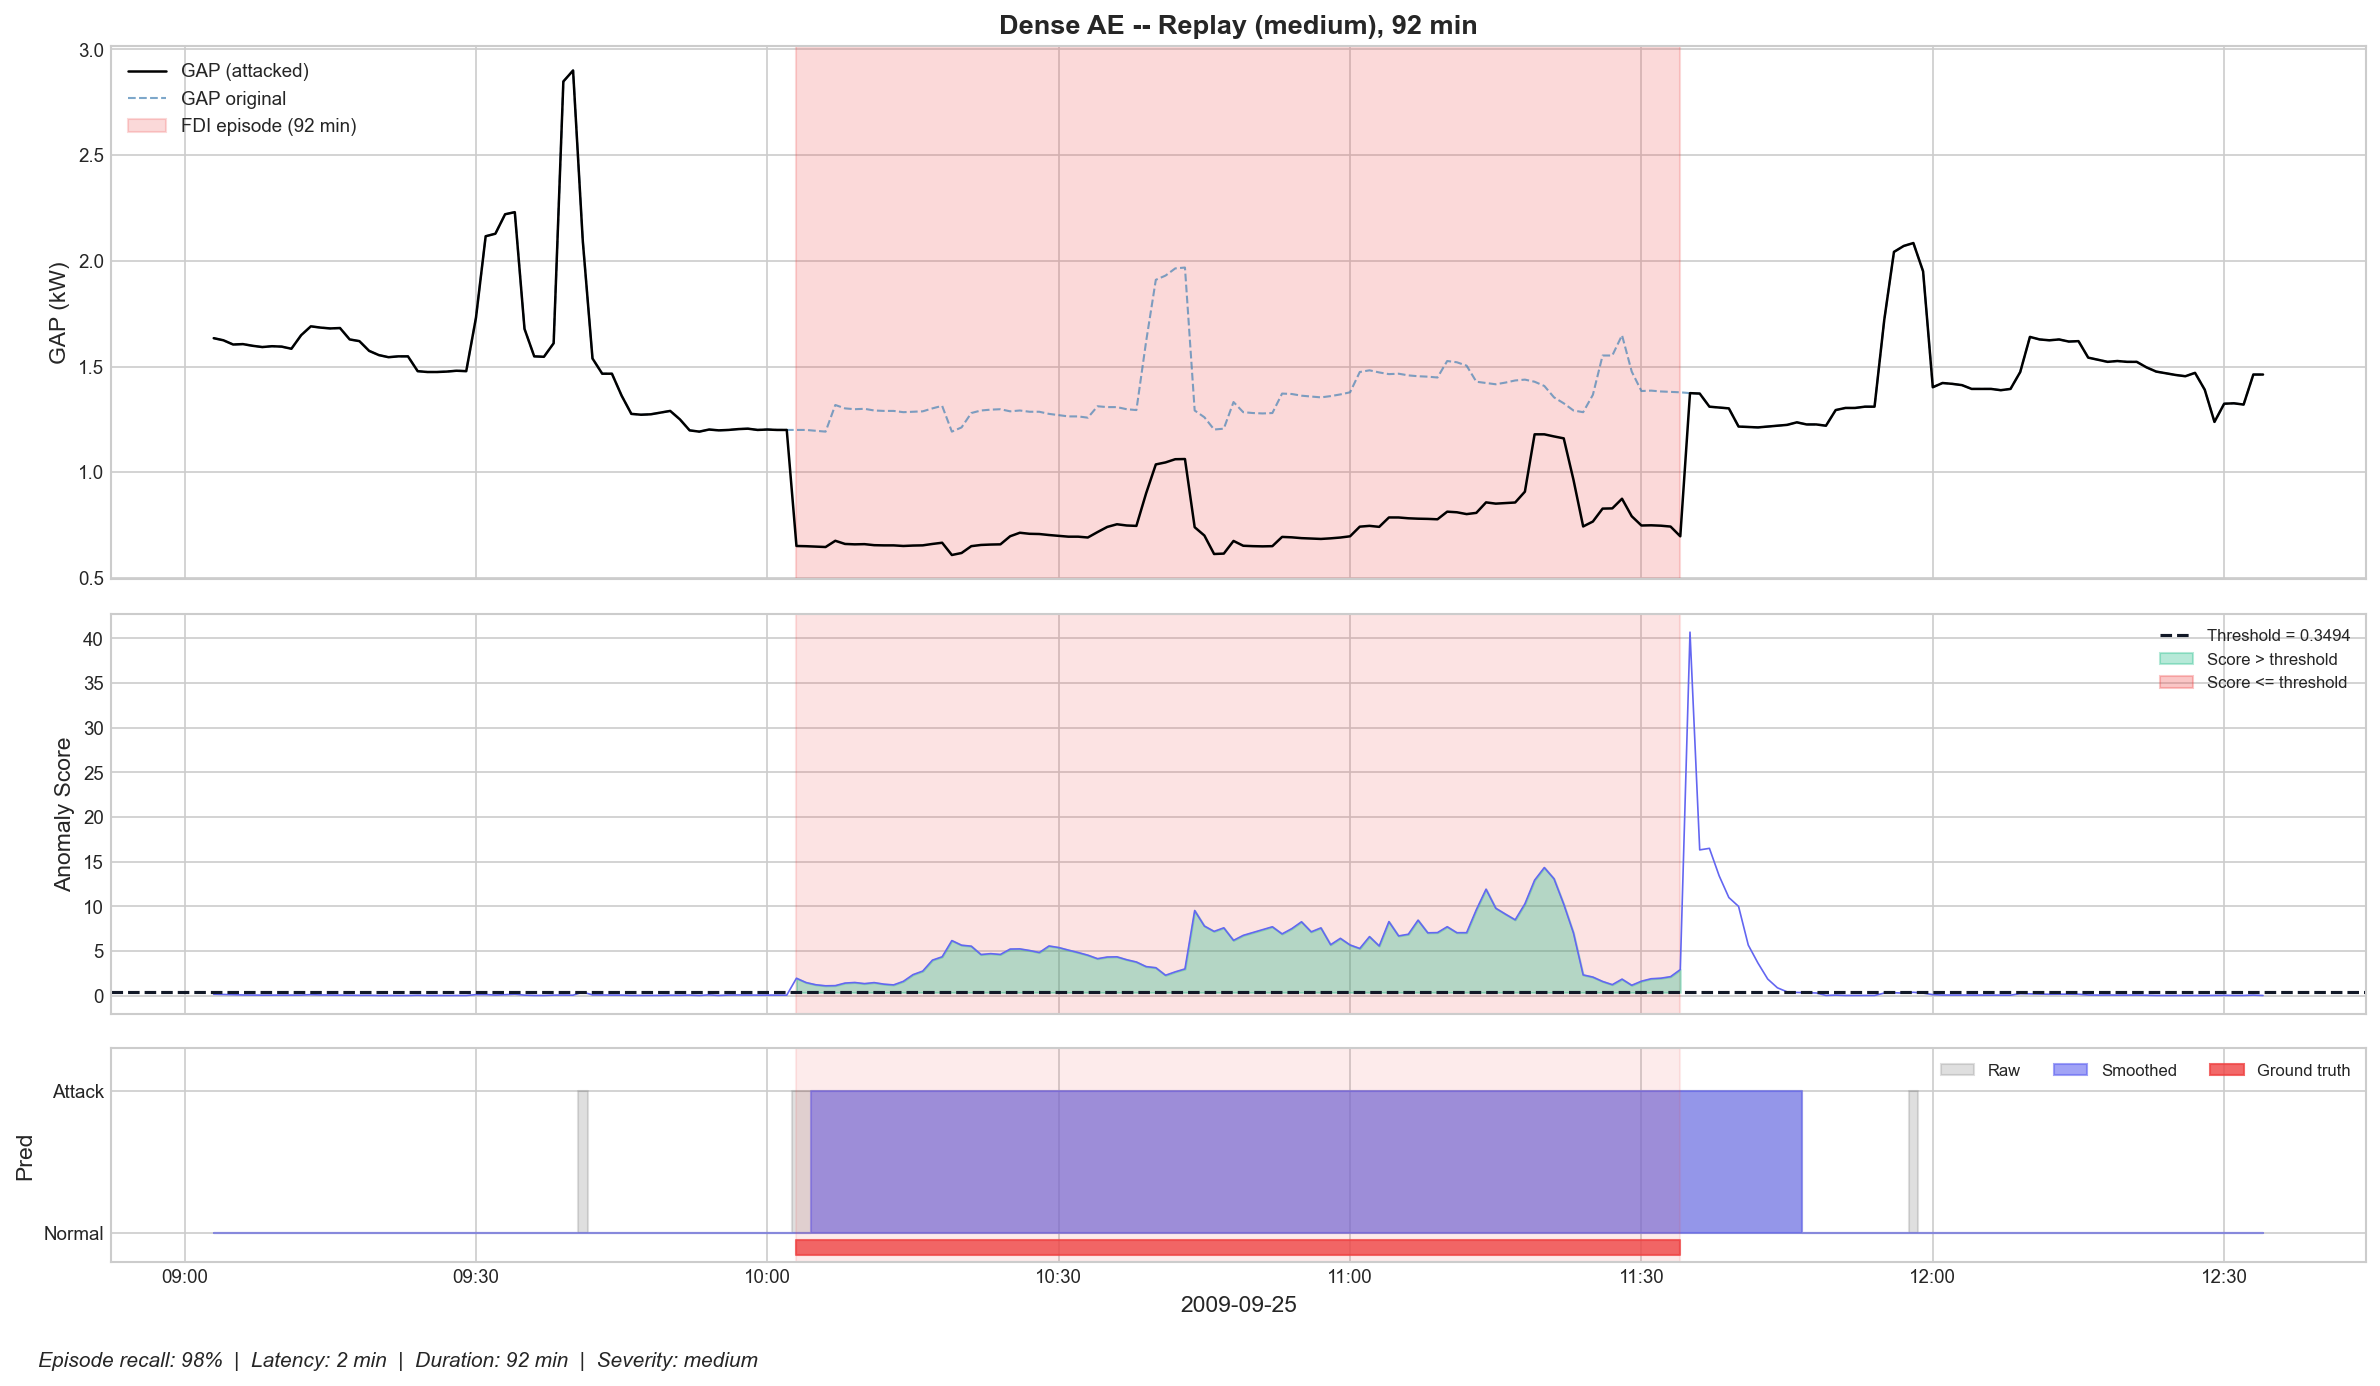


--- voltage_spoof ---
  Episode 788: medium, 65 min
  Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/episode_voltage_spoof.png


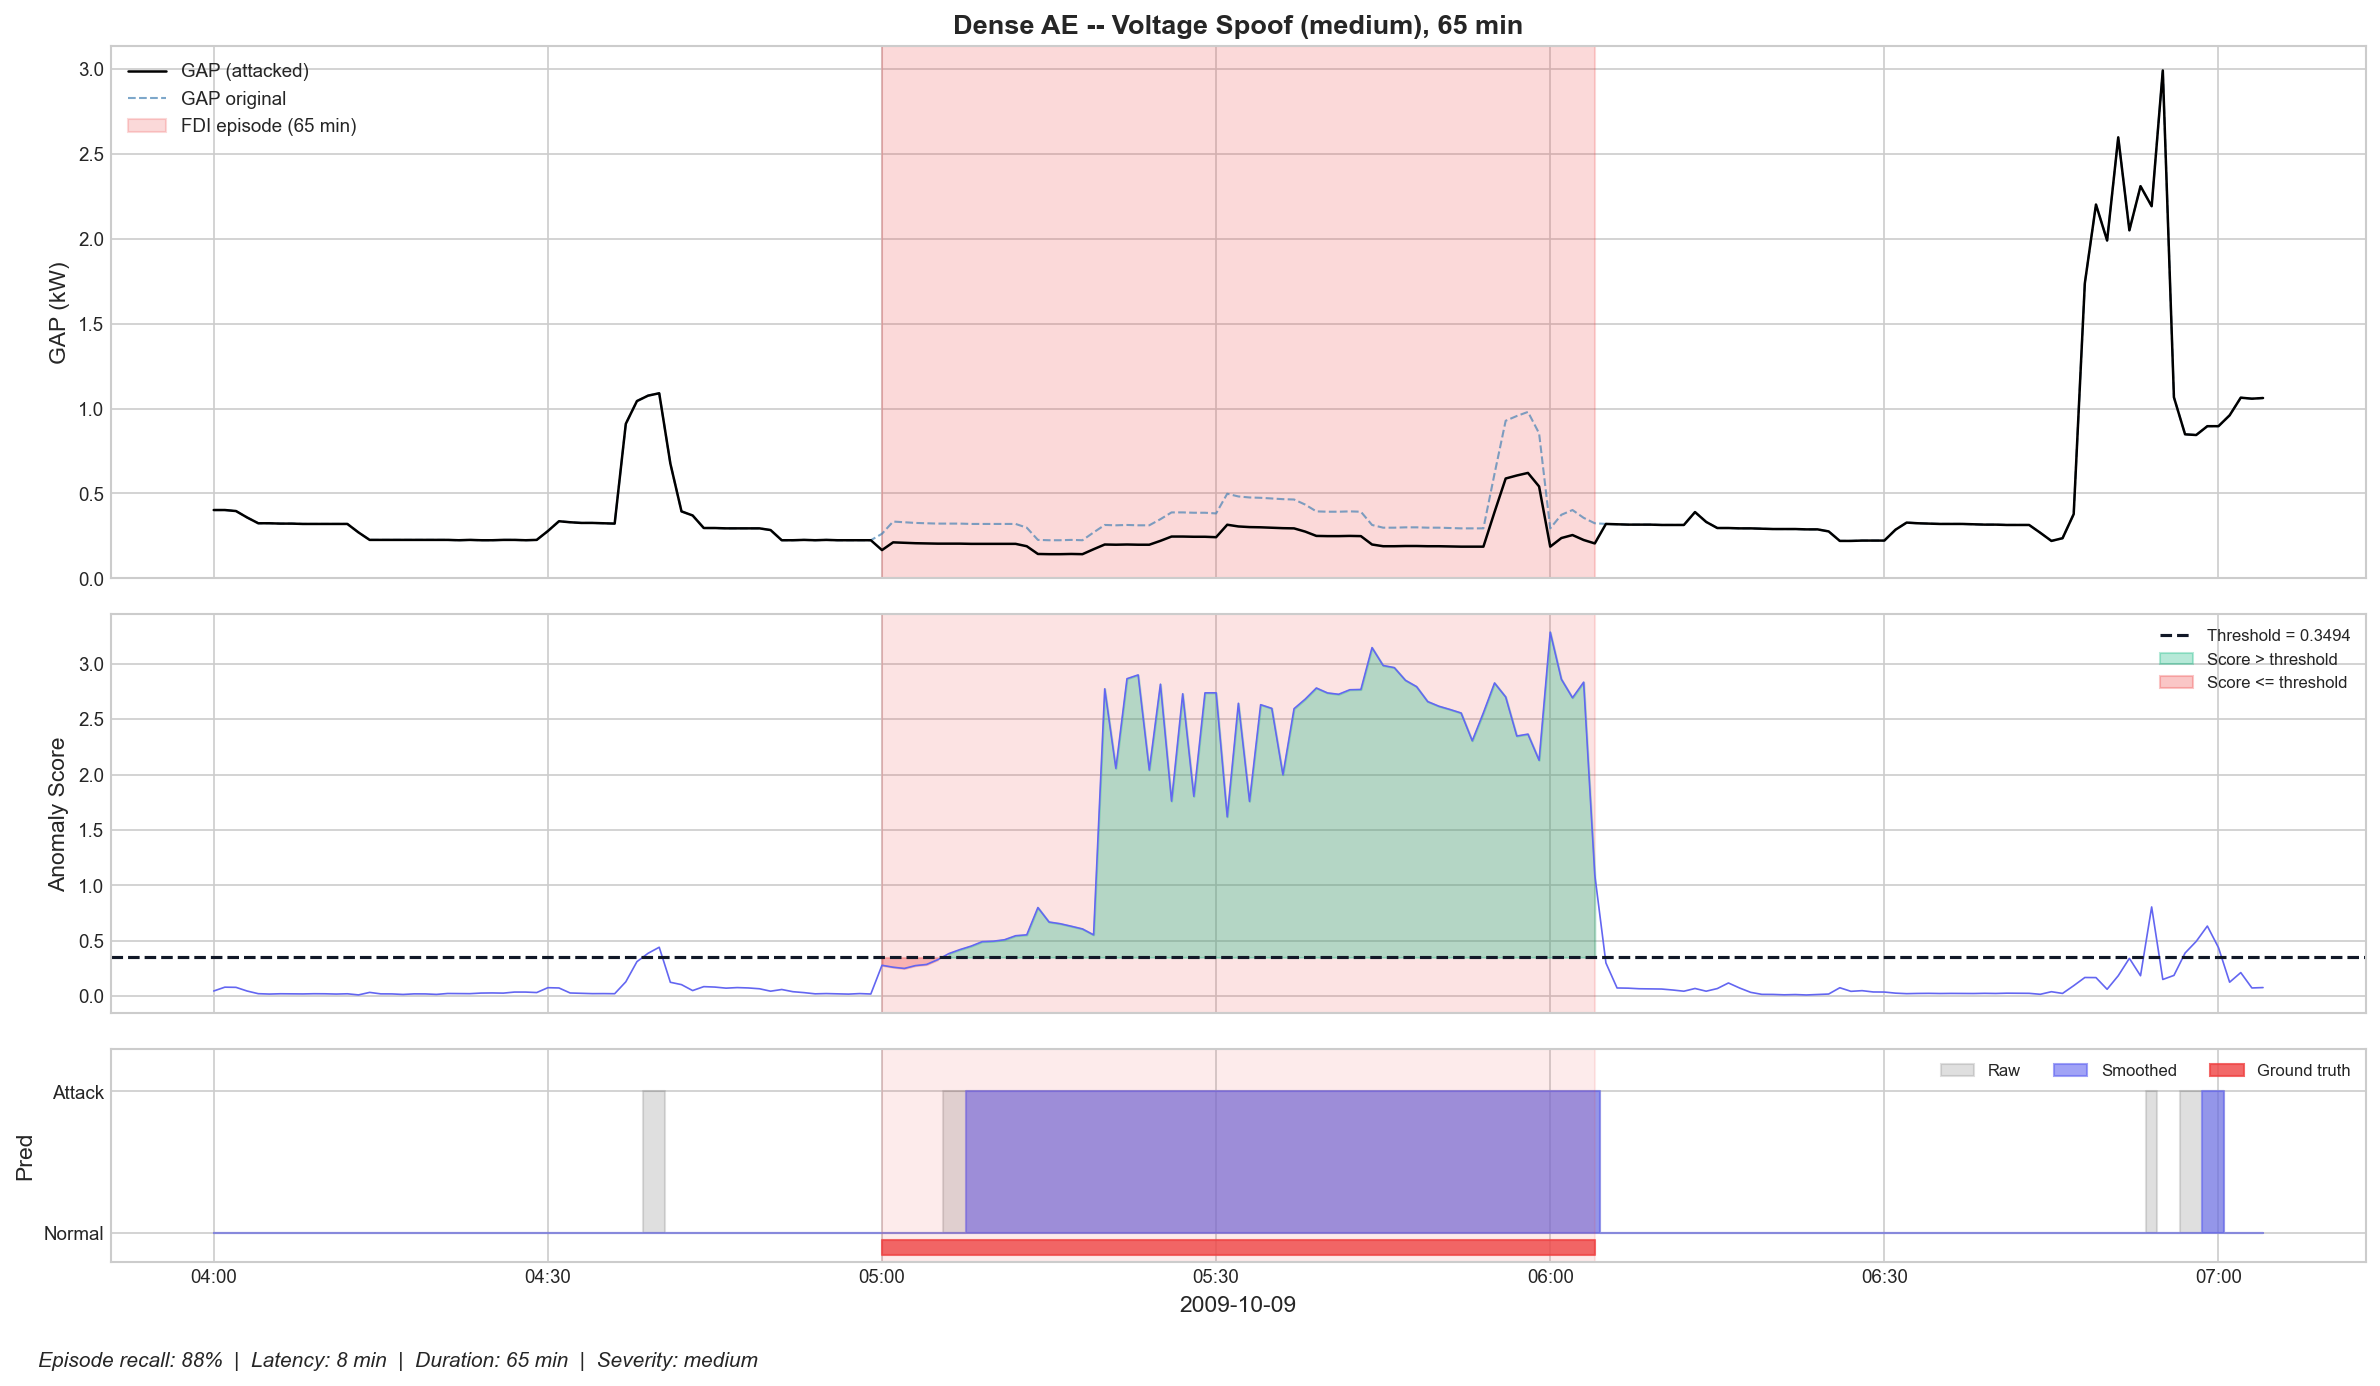

In [7]:
# -- Select the best model by F1 --
best_model_name = max(MODELS, key=lambda m: MODELS[m]['metrics']['f1'])
best = MODELS[best_model_name]
print(f'Best model: {best_model_name} (F1={best["metrics"]["f1"]:.4f})')
print()

# -- For each attack type, pick a representative episode --
# Preference order: (1) medium severity, (2) detected by the model, (3) moderate duration
df_best = best['preds']

for attack_type in ATTACK_TYPES:
    print(f'\n--- {attack_type} ---')

    # Keep only episodes of this type
    ep_mask = (df_best['attack_type'] == attack_type) & (df_best['episode_id'] >= 0)
    if not ep_mask.any():
        print(f'  No episodes of type {attack_type}')
        continue

    ep_ids = df_best.loc[ep_mask, 'episode_id'].unique()

    # First choice: a medium-severity episode that was detected
    selected_ep = None
    for ep_id in ep_ids:
        ep = df_best[df_best['episode_id'] == ep_id]
        sev = ep['severity'].iloc[0]
        detected = ep[best['smooth_col']].values.astype(int).any()

        if sev == 'medium' and detected:
            selected_ep = ep_id
            break

    # Fallback: any detected episode
    if selected_ep is None:
        for ep_id in ep_ids:
            ep = df_best[df_best['episode_id'] == ep_id]
            if ep[best['smooth_col']].values.astype(int).any():
                selected_ep = ep_id
                break

    # Fallback: the first episode
    if selected_ep is None:
        selected_ep = ep_ids[0]

    ep = df_best[df_best['episode_id'] == selected_ep]
    print(f'  Episode {selected_ep}: {ep["severity"].iloc[0]}, {len(ep)} min')

    safe_type = attack_type.lower().replace(' ', '_')
    save_path = os.path.join(FIGURES_DIR, f'episode_{safe_type}.png')

    plot_episode(
        df_preds=df_best,
        episode_id=selected_ep,
        score_col=best['score_col'],
        raw_col=best['raw_col'],
        smooth_col=best['smooth_col'],
        threshold=best['threshold'],
        model_name=best_model_name,
        save_path=save_path,
    )

## 7. Compact Grid -- 7 Attack Types in One Figure

A single figure with 7 rows (one per attack type), each pairing the
original vs attacked signal with its anomaly score.

Selected episodes: 7 types
Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/episode_grid_7_types.png


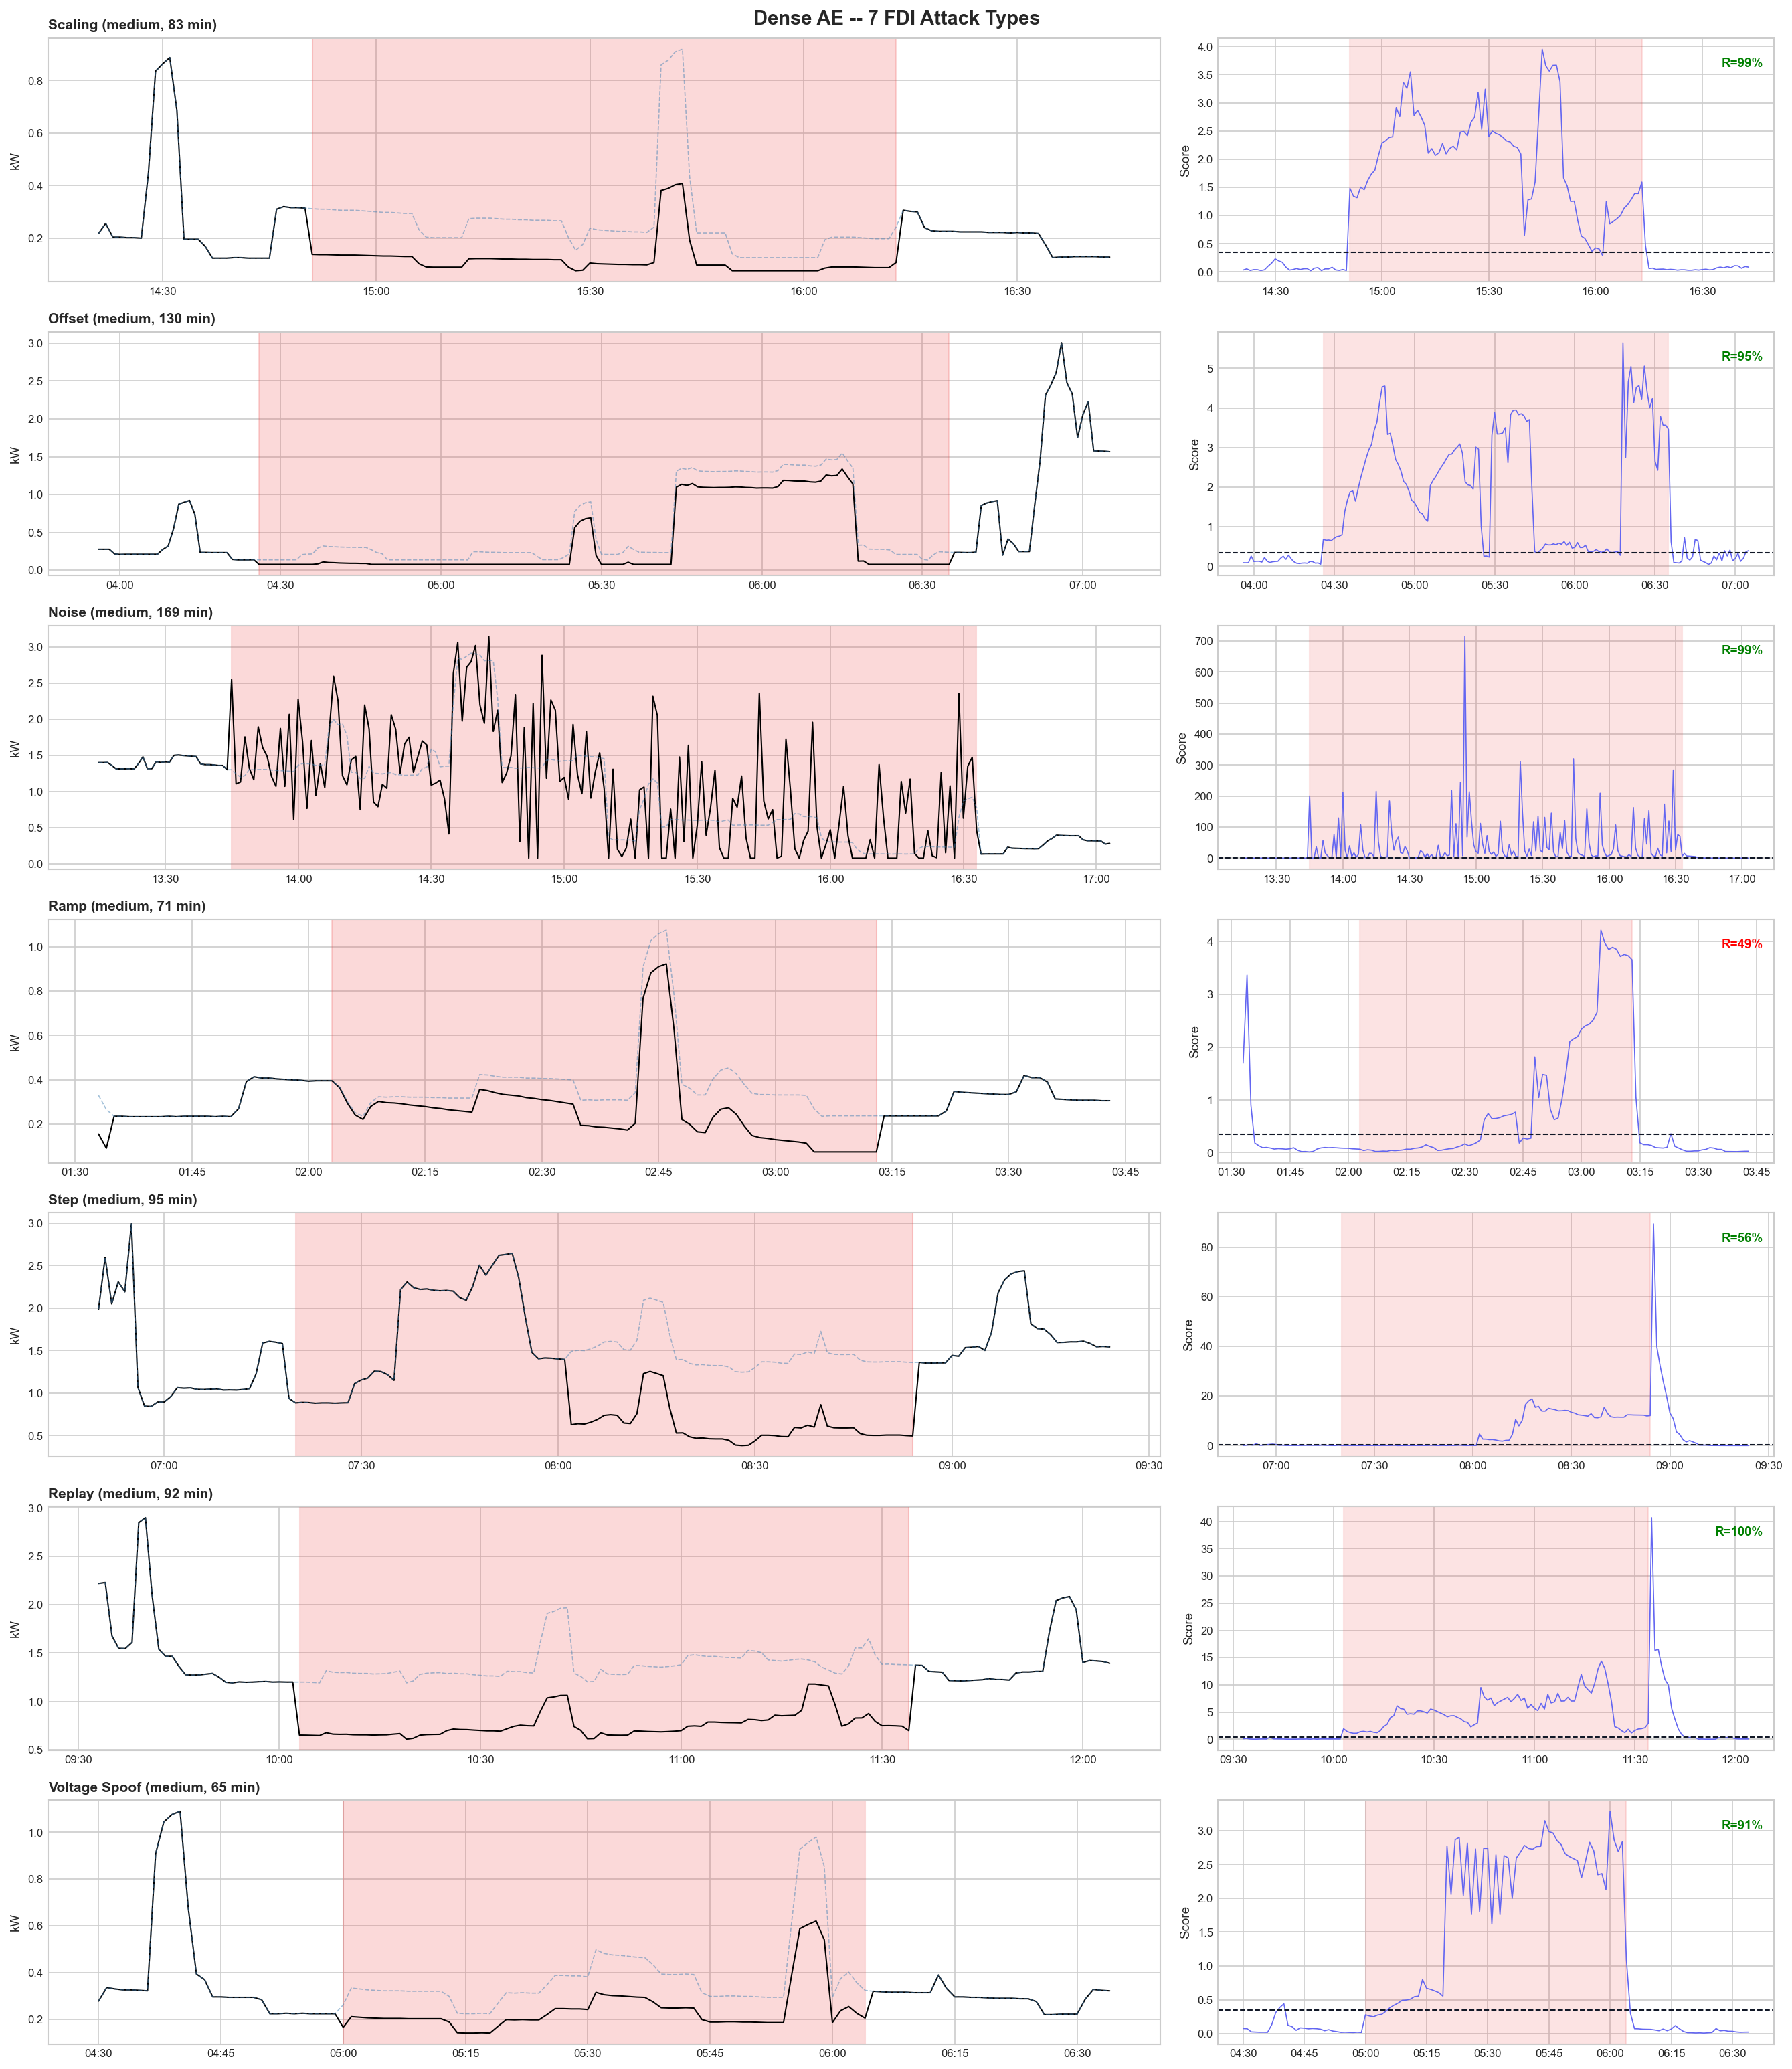

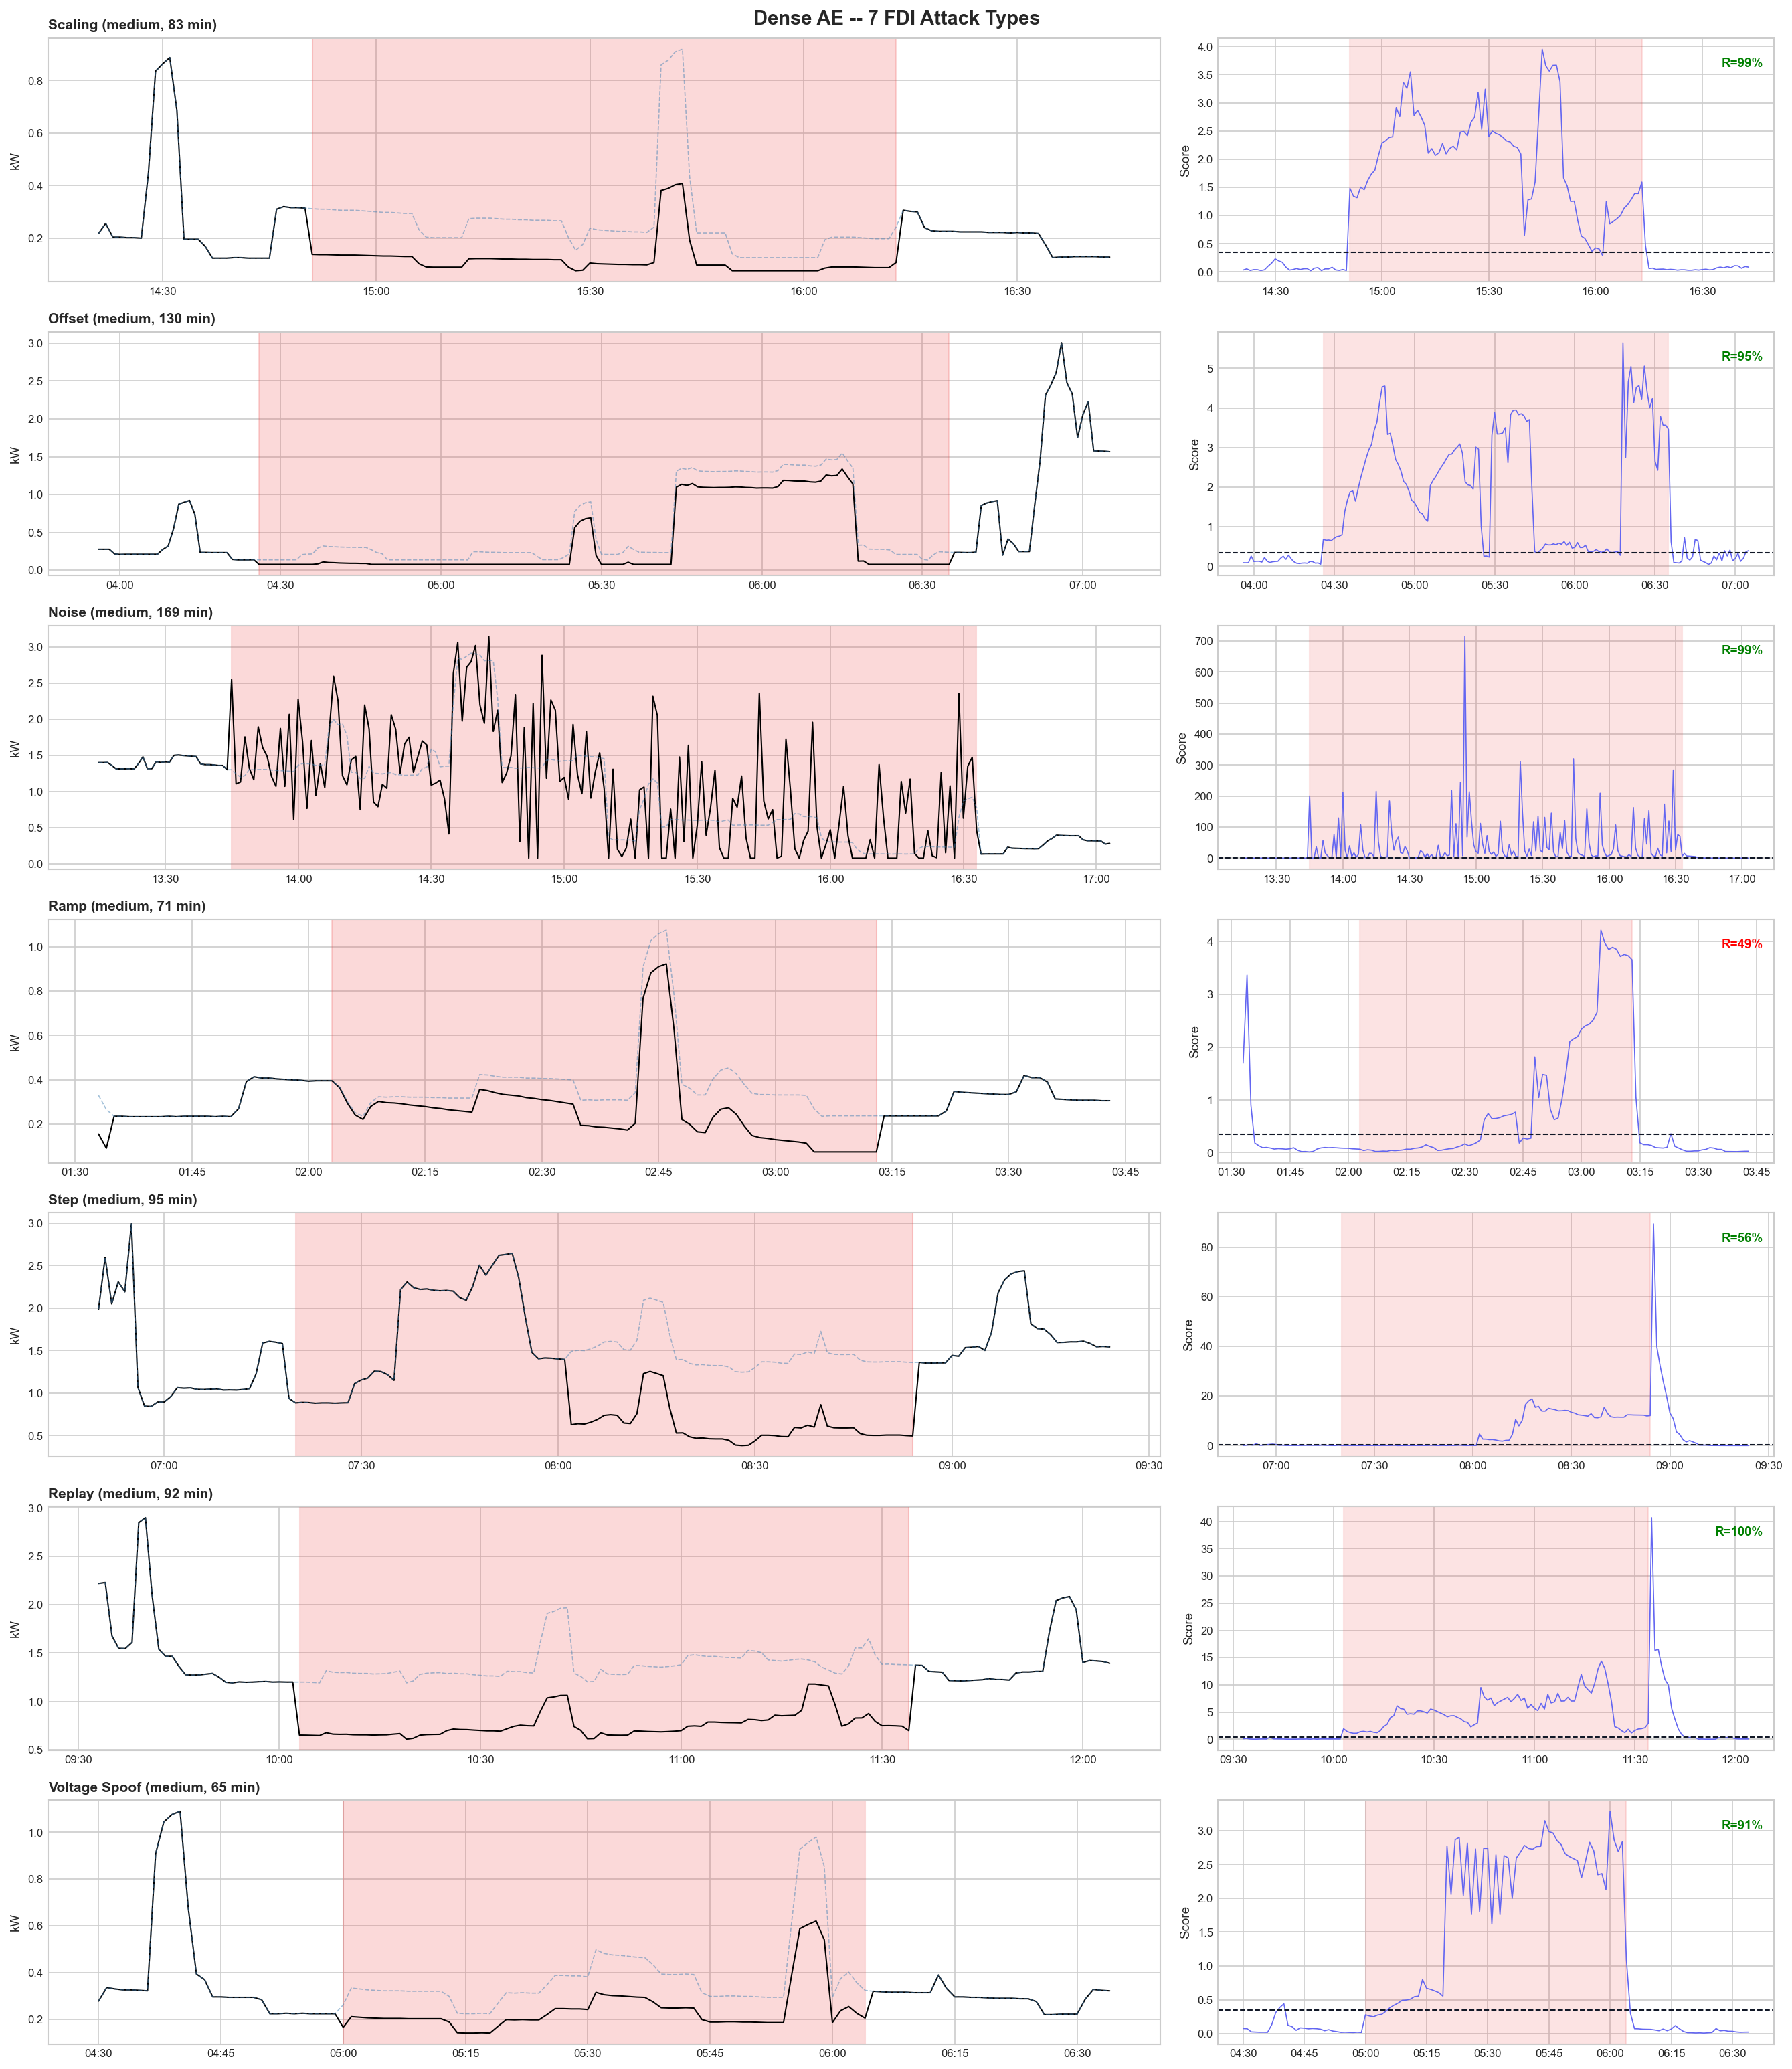

In [8]:
def plot_episode_grid(df_preds, episode_ids, score_col, threshold,
                     model_name, attack_types, save_path=None):
    '''
    Compact grid: 7 attack types, two columns each (signal + score).
    '''
    n_types = len(episode_ids)
    fig, axes = plt.subplots(n_types, 2, figsize=(18, 3 * n_types),
                              gridspec_kw={'width_ratios': [2, 1]})

    if n_types == 1:
        axes = axes.reshape(1, -1)

    for row, (attack_type, ep_id) in enumerate(episode_ids.items()):
        ep_mask = df_preds['episode_id'] == ep_id
        ep_data = df_preds[ep_mask]

        if len(ep_data) == 0:
            continue

        severity = ep_data['severity'].iloc[0]
        ep_start = ep_data.index[0]
        ep_end = ep_data.index[-1]
        duration = len(ep_data)

        # 30 min of context on each side
        ctx_start = ep_start - pd.Timedelta(minutes=30)
        ctx_end = ep_end + pd.Timedelta(minutes=30)
        ctx = df_preds.loc[ctx_start:ctx_end]

        # -- Left: signal --
        ax = axes[row, 0]
        ax.plot(ctx.index, ctx['Global_active_power'], 'k-', lw=1)
        if 'GAP_original' in ctx.columns:
            ax.plot(ctx.index, ctx['GAP_original'], color='steelblue',
                    lw=0.8, alpha=0.5, linestyle='--')
        ax.axvspan(ep_start, ep_end, alpha=0.2, color=COLORS['attack'])
        ax.set_ylabel('kW', fontsize=9)
        type_label = attack_type.replace('_', ' ').title()
        ax.set_title(f'{type_label} ({severity}, {duration} min)',
                     fontsize=10, fontweight='bold', loc='left')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(labelsize=8)

        # -- Right: score --
        ax = axes[row, 1]
        ep_ctx_scores = ctx[score_col].values
        ax.plot(ctx.index, ep_ctx_scores, color=COLORS['score'], lw=0.8)
        ax.axhline(threshold, color=COLORS['thr'], linestyle='--', lw=1)
        ax.axvspan(ep_start, ep_end, alpha=0.15, color=COLORS['attack'])

        # Per-episode recall
        ep_smooth = ep_data[score_col].values > threshold
        recall_ep = ep_smooth.sum() / max(len(ep_smooth), 1)
        ax.text(0.98, 0.92, f'R={recall_ep:.0%}',
                transform=ax.transAxes, fontsize=9, ha='right', va='top',
                fontweight='bold',
                color='green' if recall_ep > 0.5 else 'red')

        ax.set_ylabel('Score', fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(labelsize=8)

    fig.suptitle(f'{model_name} -- 7 FDI Attack Types',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()
    return fig


# -- Pick one episode per attack type --
episode_ids = {}
df_best = MODELS[best_model_name]['preds']

for attack_type in ATTACK_TYPES:
    ep_mask = (df_best['attack_type'] == attack_type) & (df_best['episode_id'] >= 0)
    if not ep_mask.any():
        continue

    ep_ids = df_best.loc[ep_mask, 'episode_id'].unique()

    # Prefer a medium-severity episode
    selected = ep_ids[0]
    for ep_id in ep_ids:
        ep = df_best[df_best['episode_id'] == ep_id]
        if ep['severity'].iloc[0] == 'medium':
            selected = ep_id
            break

    episode_ids[attack_type] = selected

print(f'Selected episodes: {len(episode_ids)} types')

plot_episode_grid(
    df_preds=df_best,
    episode_ids=episode_ids,
    score_col=MODELS[best_model_name]['score_col'],
    threshold=MODELS[best_model_name]['threshold'],
    model_name=best_model_name,
    attack_types=ATTACK_TYPES,
    save_path=os.path.join(FIGURES_DIR, 'episode_grid_7_types.png'),
)

## 8. Consolidated Comparison Table

A final summary of the 4 models, ready to drop straight into the report.

COMPARISON TABLE -- 4 ANOMALY DETECTION MODELS

  Model               F1     F2   Prec    Rec  AUC-ROC  AUC-PR     KB      ms   W,K
  ------------------------------------------------------------------------------------------
  IF              0.7544 0.7499 0.7621 0.7469   0.9266  0.7824 6910.8  0.0095 3,  2
  K-Means+IF      0.7895 0.7651 0.8337 0.7497   0.9270  0.7644 17425.4  0.0114 11, 10
  Dense AE        0.8083 0.8073 0.8099 0.8067   0.9304  0.8176  134.0  0.0004 3,  3 *
  LSTM AE         0.7306 0.7931 0.6457 0.8411   0.9429  0.8853 3178.6  0.0038 3,  3

  * = best F1

Saved: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/comparison_4_models.png


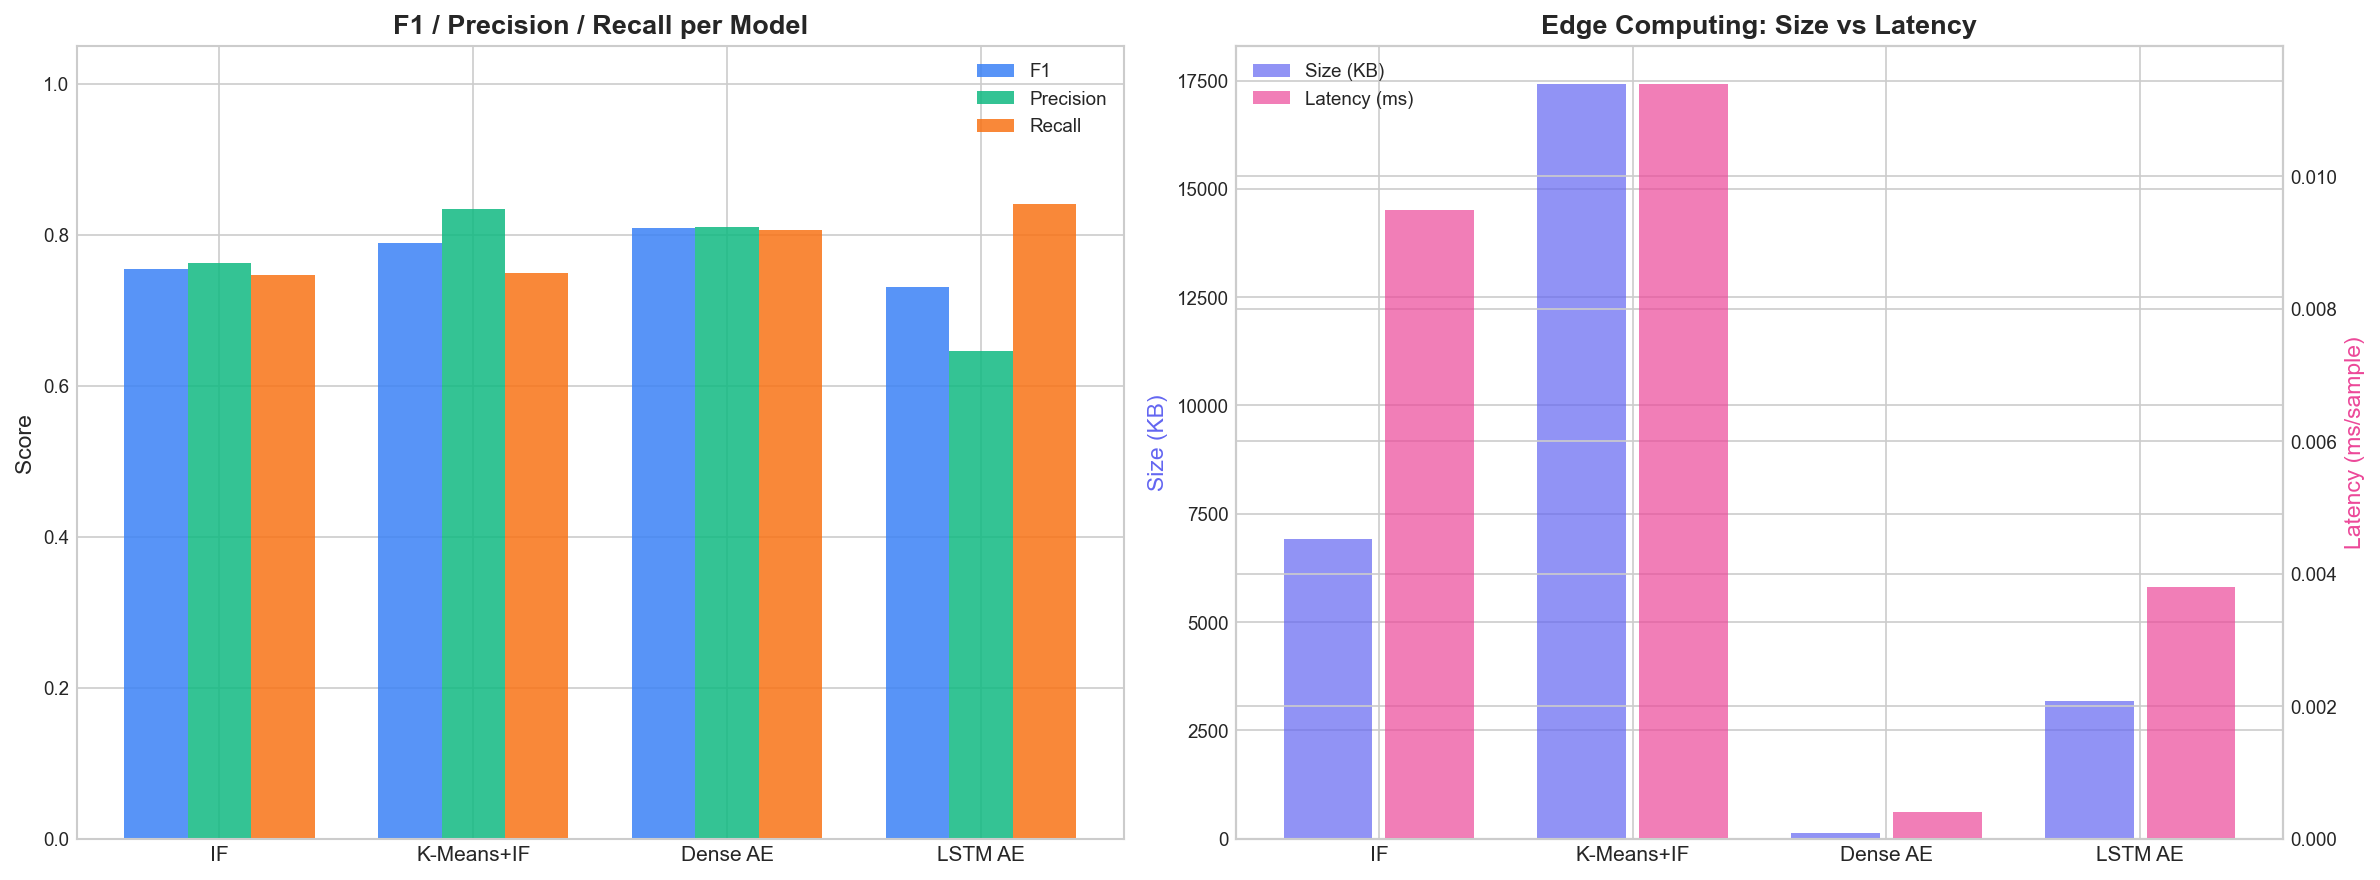

In [9]:
# -- Comparison table --
print('=' * 95)
print('COMPARISON TABLE -- 4 ANOMALY DETECTION MODELS')
print('=' * 95)
print()
header = (f'  {"Model":15s} {"F1":>6s} {"F2":>6s} {"Prec":>6s} {"Rec":>6s} '
          f'{"AUC-ROC":>8s} {"AUC-PR":>7s} {"KB":>6s} {"ms":>7s} {"W,K":>5s}')
print(header)
print('  ' + '-' * 90)

rows = []
for name in ['IF', 'K-Means+IF', 'Dense AE', 'LSTM AE']:
    if name not in MODELS:
        continue
    m = MODELS[name]['metrics']
    row = {
        'Model': name,
        'F1': m['f1'], 'F2': m['f2'],
        'Precision': m['precision'], 'Recall': m['recall'],
        'AUC-ROC': m['auc_roc'], 'AUC-PR': m['auc_pr'],
        'Size_KB': m.get('model_size_kb', '?'),
        'ms': m.get('ms_per_sample', '?'),
        'W': m.get('temporal_W', '?'),
        'K': m.get('temporal_K', '?'),
    }
    rows.append(row)

    is_best = (m['f1'] == max(MODELS[n]['metrics']['f1'] for n in MODELS))
    marker = ' *' if is_best else ''

    print(f'  {name:15s} {m["f1"]:>6.4f} {m["f2"]:>6.4f} {m["precision"]:>6.4f} '
          f'{m["recall"]:>6.4f} {m["auc_roc"]:>8.4f} {m["auc_pr"]:>7.4f} '
          f'{m.get("model_size_kb", "?"):>6} {m.get("ms_per_sample", "?"):>7} '
          f'{m.get("temporal_W","?")},{m.get("temporal_K","?"):>3}{marker}')

print()
print('  * = best F1')

# -- Bar-chart visualization --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: F1, Precision, Recall per model
model_names = [r['Model'] for r in rows]
x = np.arange(len(model_names))
w = 0.25

for i, (metric, color) in enumerate([
    ('F1', '#3B82F6'), ('Precision', '#10B981'), ('Recall', '#F97316')
]):
    vals = [r[metric] for r in rows]
    axes[0].bar(x + i*w, vals, w, label=metric, color=color, alpha=0.85)

axes[0].set_xticks(x + w)
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('F1 / Precision / Recall per Model', fontweight='bold')
axes[0].legend()

# Bar chart: edge metrics (model size in KB + ms/sample)
sizes = [r['Size_KB'] if isinstance(r['Size_KB'], (int, float)) else 0 for r in rows]
latencies = [r['ms'] if isinstance(r['ms'], (int, float)) else 0 for r in rows]

ax1 = axes[1]
ax2 = ax1.twinx()

b1 = ax1.bar(x - 0.2, sizes, 0.35, color='#6366F1', alpha=0.7, label='Size (KB)')
b2 = ax2.bar(x + 0.2, latencies, 0.35, color='#EC4899', alpha=0.7, label='Latency (ms)')

ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=10)
ax1.set_ylabel('Size (KB)', color='#6366F1')
ax2.set_ylabel('Latency (ms/sample)', color='#EC4899')
ax1.set_title('Edge Computing: Size vs Latency', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
save_path = os.path.join(FIGURES_DIR, 'comparison_4_models.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'\nSaved: {save_path}')
plt.show()

## 9. Summary of Generated Figures

| File | Content | TFG Section |
|---|---|---|
| `timeline_if.png` | Full IF timeline | Ch. 4.1 |
| `timeline_k_means_if.png` | Full K-Means+IF timeline | Ch. 4.2 |
| `timeline_dense_ae.png` | Full Dense AE timeline | Ch. 4.3 |
| `timeline_lstm_ae.png` | Full LSTM AE timeline | Ch. 4.4 |
| `timeline_zoom_*.png` | One-week zoom per model | Ch. 4.x |
| `episode_scaling.png` ... `episode_voltage_spoof.png` | Individual episodes (7) | Ch. 3.3 |
| `episode_grid_7_types.png` | Compact grid of the 7 types | Ch. 3.3 |
| `comparison_4_models.png` | Comparative bar charts | Ch. 4.5 |

In [10]:
# List of generated figures

print('Figures generated in', FIGURES_DIR + '/:')

for f in sorted(os.listdir(FIGURES_DIR)):

    size_kb = os.path.getsize(os.path.join(FIGURES_DIR, f)) / 1024

    print(f'  {f:45s} {size_kb:>7.1f} KB')

Figures generated in /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/figures/:
  adversarial_curves.png                           99.5 KB
  adversarial_defense.png                          41.6 KB
  adversarial_evasion_severity.png                 26.8 KB
  adversarial_robustness_gradient.png              43.7 KB
  adversarial_transfer_ensemble.png                24.8 KB
  comparison_4_models.png                         166.9 KB
  comparison_pareto_frontier.png                  169.4 KB
  comparison_radar.png                            105.4 KB
  comparison_radar_v2.png                         320.2 KB
  comparison_recall_by_attack.png                 314.1 KB
  crossdomain_multihouse.png                      149.5 KB
  crossdomain_recall_by_attack.png                198.6 KB
  diffusion_realism.png                           189.6 KB
  dp_privacy_utility.png                           39.6 KB
  edge_compression_pareto.png                      77.9 KB
  episode_grid_7_types.png          